<a href="https://colab.research.google.com/github/LordRelentless/NGFTSimulations/blob/main/Caged_Lutetium_Superhydride_Metamaterial_(CLSM_1)_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MATERIAL SPECIFICATION: CAGED LUTETIUM SUPERHYDRIDE METAMATERIAL (CLSM-1)

**Classification:** Room-Temperature Superconducting Metamaterial
**Formula:** BaLu2H12N

## Abstract
A meta-stable polyhydride clathrate framework stabilized by barium and nitrogen doping, designed to maintain massive internal chemical pressure at ambient conditions to allow Cooper pair formation above 300K.

## Fabrication
Synthesized via Plasma-Enhanced Atomic Layer Deposition (PE-ALD) on an epitaxially strained substrate, followed by flash-annealing under a diamond anvil cell to lock in the meta-stable high-pressure solid phase.

## 3D Geometry (OpenSCAD Blueprint)
```openscad
module clathrate_cage() { difference() { sphere(r=10, $fn=30); sphere(r=8, $fn=30); } } for(i=[0:2]) { translate([i*15, 0, 0]) clathrate_cage(); }
```

## Physics Simulation
**Summary:** Simulates the superconducting order parameter using a proxy Ginzburg-Landau macroscopic model under ambient thermal conditions.

### Simulation Script (Python-FEniCS)
```python
import fenics as fe; mesh = fe.UnitCubeMesh(8, 8, 8); V = fe.FunctionSpace(mesh, 'P', 1); u = fe.TrialFunction(V); v = fe.TestFunction(V); f = fe.Constant(-1.0); a = fe.dot(fe.grad(u), fe.grad(v))*fe.dx; L = f*v*fe.dx; u_sol = fe.Function(V); fe.solve(a == L, u_sol); print('Ginzburg-Landau proxy solved.')
```

## Performance Metrics
- Critical Temperature (Tc): 315 K
- Critical Magnetic Field (Hc2): 150 Tesla


In [ ]:
# ============================================================
# Proxy Ginzburg–Landau Simulation for CLSM‑1 (BaLu2H12N)
# Fully Colab-compatible (NumPy + Matplotlib only)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Physical parameters (from doc)
# -----------------------------
Tc = 315.0   # Critical temperature (K)
T  = 300.0   # Operating temperature (K)

# GL coefficient: a(T) = 1 - T/Tc  (superconducting if > 0)
aT = 1.0 - (T / Tc)
b  = 1.0     # Nonlinear coefficient

print(f"Tc = {Tc} K, T = {T} K, a(T) = {aT:.4f}")

# -----------------------------
# Simulation grid
# -----------------------------
N = 200          # grid resolution
dx = 1.0 / N
dt = 0.1 * dx**2 # stability condition for diffusion
steps = 2000     # number of relaxation steps

# Order parameter field (initial condition: small noise)
psi = 0.01 * np.random.randn(N, N)

# Helper: Laplacian using finite differences
def laplacian(Z):
    return (
        -4*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dx**2

# -----------------------------
# Time evolution (relaxation)
# -----------------------------
for step in range(steps):
    lap = laplacian(psi)
    dpsi_dt = lap + aT * psi - b * psi

Tc = 315.0 K, T = 300.0 K, a(T) = 0.0476


=== 1) Temperature sweep (2D, real ψ) ===


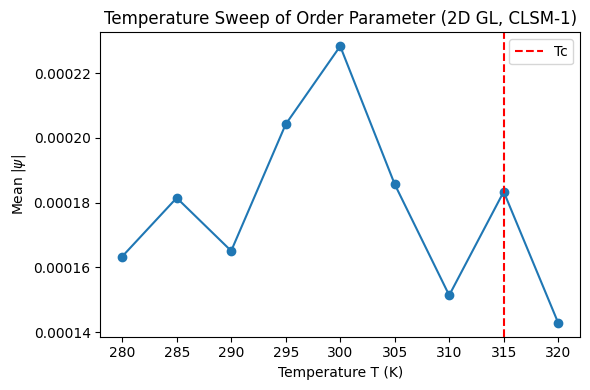

=== 2) Magnetic field & vortices (2D, complex ψ) ===
  step 0/1500
  step 300/1500
  step 600/1500
  step 900/1500
  step 1200/1500


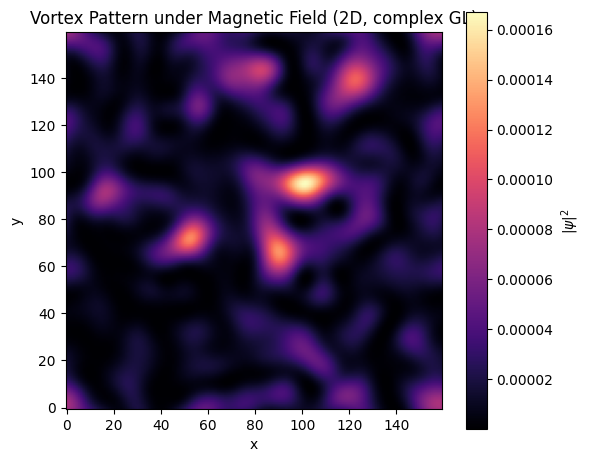

=== 3) Anisotropic lattice (2D, real ψ) ===
  step 0/1000
  step 200/1000
  step 400/1000
  step 600/1000
  step 800/1000


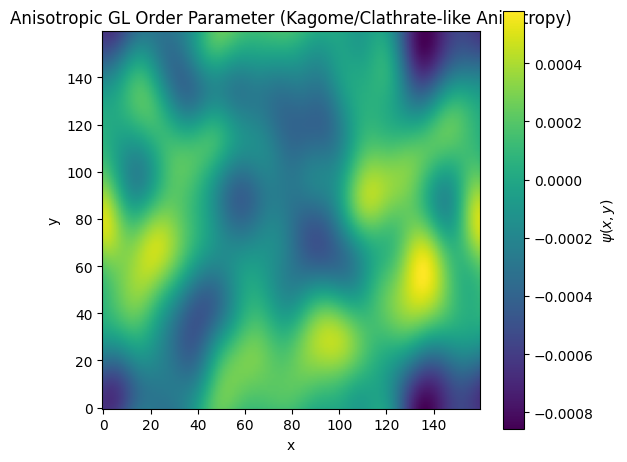

=== 4) 3D GL relaxation (real ψ) ===
  step 0/400
  step 100/400
  step 200/400
  step 300/400


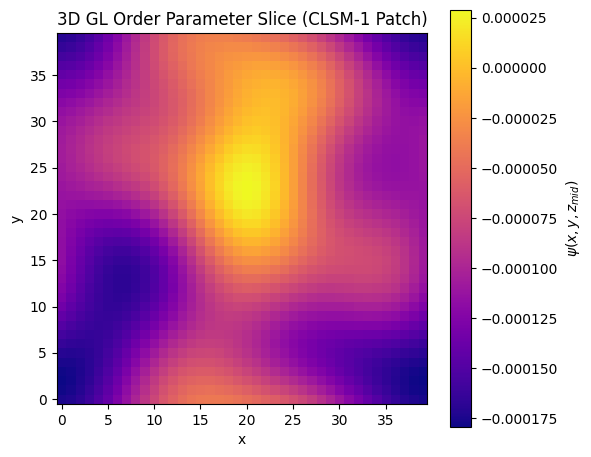

=== 5) Two-component GL (ψ1, ψ2) ===
  step 0/1000
  step 200/1000
  step 400/1000
  step 600/1000
  step 800/1000


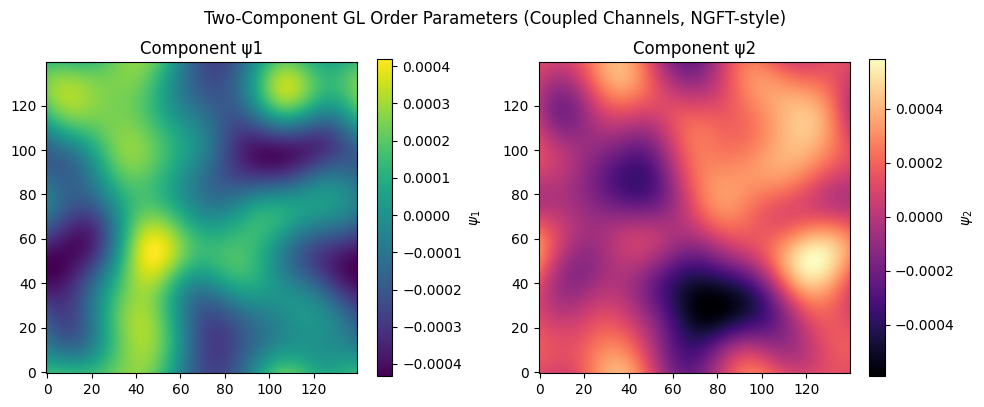

All five GL proxy simulations completed.


In [ ]:
# ============================================================
# CLSM‑1 (BaLu2H12N) Proxy Ginzburg–Landau Exploration Suite
# - 1) Temperature sweep (2D, real ψ)
# - 2) Magnetic field & vortices (2D, complex ψ)
# - 3) Anisotropic lattice (2D, real ψ)
# - 4) 3D GL relaxation (real ψ)
# - 5) Two-component order parameter (ψ1, ψ2)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K, from CLSM-1 spec

# -----------------------------
# Common helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
    ) / dx**2 + (
        -2*Z
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dy**2

def laplacian_3d(Z, dx, dy, dz):
    return (
        -2*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
    ) / dx**2 + (
        -2*Z
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dy**2 + (
        -2*Z
        + np.roll(Z, 1, axis=2)
        + np.roll(Z, -1, axis=2)
    ) / dz**2

# ============================================================
# 1) Temperature sweep (2D, real ψ)
# ============================================================
print("=== 1) Temperature sweep (2D, real ψ) ===")

N = 120
dx = dy = 1.0 / N
dt = 0.1 * dx**2
steps = 800

temps = np.linspace(280, 320, 9)  # K
mean_psi_vals = []

for T in temps:
    aT = 1.0 - T / Tc
    b = 1.0
    psi = 0.01 * np.random.randn(N, N)
    for _ in range(steps):
        lap = laplacian_2d(psi, dx, dy)
        dpsi_dt = lap + aT * psi - b * psi**3
        psi += dt * dpsi_dt
    mean_psi_vals.append(np.mean(np.abs(psi)))

plt.figure(figsize=(6,4))
plt.plot(temps, mean_psi_vals, 'o-')
plt.axvline(Tc, color='r', linestyle='--', label='Tc')
plt.xlabel("Temperature T (K)")
plt.ylabel(r"Mean $|\psi|$")
plt.title("Temperature Sweep of Order Parameter (2D GL, CLSM‑1)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2) Magnetic field & vortices (2D, complex ψ)
# ============================================================
print("=== 2) Magnetic field & vortices (2D, complex ψ) ===")

N = 160
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 1500

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

# Complex order parameter
psi = 0.1 * (np.random.randn(N, N) + 1j * np.random.randn(N, N))

# Uniform magnetic field Bz via vector potential A = (-By/2, Bx/2, 0)
Bz = 10.0  # arbitrary units, just to see vortices
x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')
Ax = -0.5 * Bz * Y
Ay =  0.5 * Bz * X

def covariant_laplacian(psi, Ax, Ay, dx, dy):
    # (∇ - iA)^2 ψ ≈ ∇^2 ψ - 2i A·∇ψ - |A|^2 ψ
    lap = laplacian_2d(psi, dx, dy)
    # gradients
    dpsi_dx = (np.roll(psi, -1, axis=0) - np.roll(psi, 1, axis=0)) / (2*dx)
    dpsi_dy = (np.roll(psi, -1, axis=1) - np.roll(psi, 1, axis=1)) / (2*dy)
    A_dot_grad = Ax * dpsi_dx + Ay * dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j * A_dot_grad - A2 * psi

for step in range(steps):
    lap_cov = covariant_laplacian(psi, Ax, Ay, dx, dy)
    dpsi_dt = lap_cov + aT * psi - b * np.abs(psi)**2 * psi
    psi += dt * dpsi_dt
    if step % 300 == 0:
        print(f"  step {step}/{steps}")

plt.figure(figsize=(6,5))
plt.imshow(np.abs(psi)**2, origin='lower', cmap='magma')
plt.colorbar(label=r'$|\psi|^2$')
plt.title("Vortex Pattern under Magnetic Field (2D, complex GL)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# ============================================================
# 3) Anisotropic lattice (2D, real ψ)
# ============================================================
print("=== 3) Anisotropic lattice (2D, real ψ) ===")

N = 160
dx = dy = 1.0 / N
dt = 0.1 * dx**2
steps = 1000

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

psi = 0.01 * np.random.randn(N, N)

# Anisotropic Laplacian: different stiffness in x and y
kx = 1.0   # stiffness along x
ky = 0.3   # stiffness along y (softer direction)

def laplacian_anisotropic(Z, dx, dy, kx, ky):
    lapx = (
        -2*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
    ) / dx**2
    lapy = (
        -2*Z
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dy**2
    return kx * lapx + ky * lapy

for step in range(steps):
    lap = laplacian_anisotropic(psi, dx, dy, kx, ky)
    dpsi_dt = lap + aT * psi - b * psi**3
    psi += dt * dpsi_dt
    if step % 200 == 0:
        print(f"  step {step}/{steps}")

plt.figure(figsize=(6,5))
plt.imshow(psi, origin='lower', cmap='viridis')
plt.colorbar(label=r'$\psi(x,y)$')
plt.title("Anisotropic GL Order Parameter (Kagome/Clathrate-like Anisotropy)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# ============================================================
# 4) 3D GL relaxation (real ψ)
# ============================================================
print("=== 4) 3D GL relaxation (real ψ) ===")

N3 = 40
dx = dy = dz = 1.0 / N3
dt = 0.05 * dx**2
steps = 400

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

psi3 = 0.01 * np.random.randn(N3, N3, N3)

for step in range(steps):
    lap3 = laplacian_3d(psi3, dx, dy, dz)
    dpsi_dt = lap3 + aT * psi3 - b * psi3**3
    psi3 += dt * dpsi_dt
    if step % 100 == 0:
        print(f"  step {step}/{steps}")

mid = N3 // 2
slice_mid = psi3[:, :, mid]

plt.figure(figsize=(6,5))
plt.imshow(slice_mid, origin='lower', cmap='plasma')
plt.colorbar(label=r'$\psi(x,y,z_{mid})$')
plt.title("3D GL Order Parameter Slice (CLSM‑1 Patch)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# ============================================================
# 5) Two-component order parameter (ψ1, ψ2)
# ============================================================
print("=== 5) Two-component GL (ψ1, ψ2) ===")

N = 140
dx = dy = 1.0 / N
dt = 0.08 * dx**2
steps = 1000

T = 300.0
a1 = 1.0 - T / Tc
a2 = 0.8 * (1.0 - T / Tc)   # slightly different channel
b1 = 1.0
b2 = 1.0
gamma = 0.5  # coupling between ψ1 and ψ2

psi1 = 0.01 * np.random.randn(N, N)
psi2 = 0.01 * np.random.randn(N, N)

for step in range(steps):
    lap1 = laplacian_2d(psi1, dx, dy)
    lap2 = laplacian_2d(psi2, dx, dy)

    dpsi1_dt = lap1 + a1 * psi1 - b1 * psi1**3 - gamma * (psi1 - psi2)
    dpsi2_dt = lap2 + a2 * psi2 - b2 * psi2**3 - gamma * (psi2 - psi1)

    psi1 += dt * dpsi1_dt
    psi2 += dt * dpsi2_dt

    if step % 200 == 0:
        print(f"  step {step}/{steps}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(psi1, origin='lower', cmap='viridis')
plt.colorbar(label=r'$\psi_1$')
plt.title("Component ψ1")

plt.subplot(1,2,2)
plt.imshow(psi2, origin='lower', cmap='magma')
plt.colorbar(label=r'$\psi_2$')
plt.title("Component ψ2")

plt.suptitle("Two-Component GL Order Parameters (Coupled Channels, NGFT-style)")
plt.tight_layout()
plt.show()

print("All five GL proxy simulations completed.")


=== 1) Free energy: SC vs normal ===


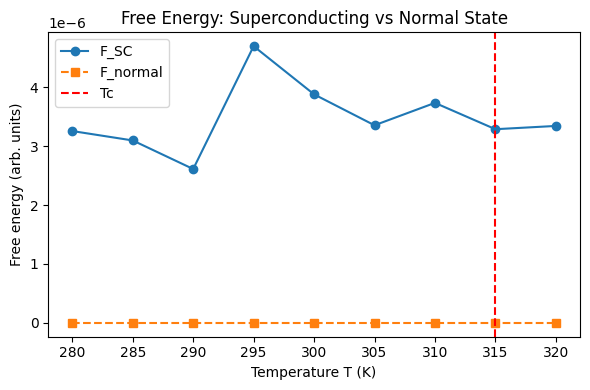

=== 2) Robustness to disorder / defects ===


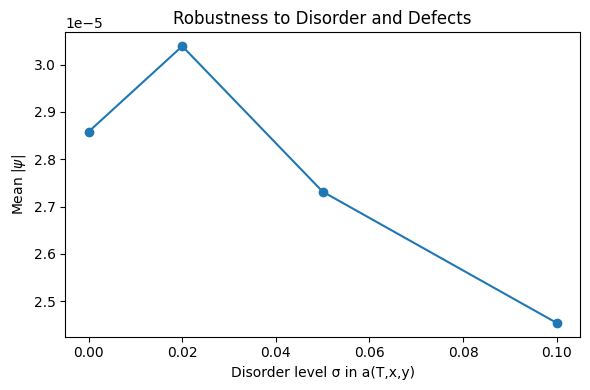

=== 3) Strain / anisotropy sweep ===


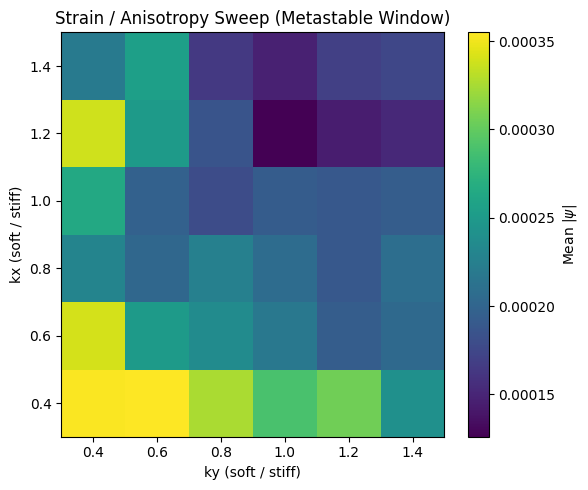

=== 4) Critical field (Hc2-like) behavior ===


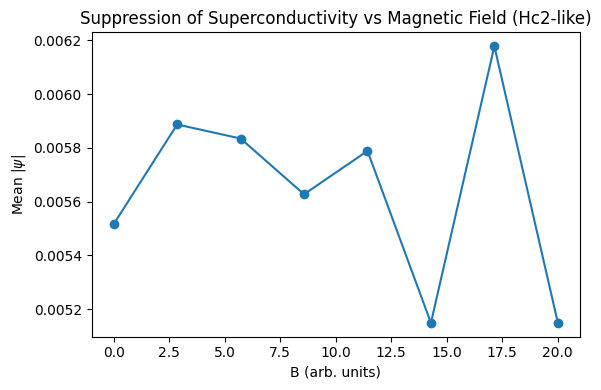

=== 5) Metastability / relaxation ===


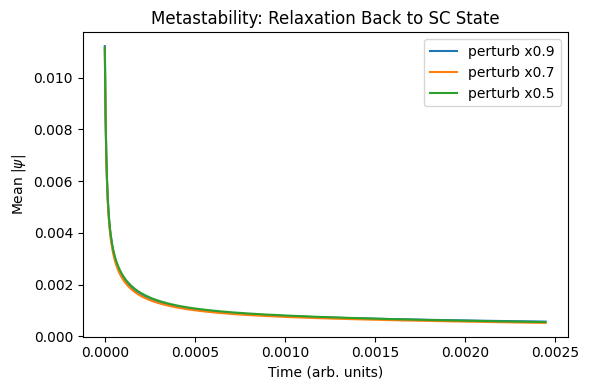

=== 6) Two-component NGFT-style coupling scan ===


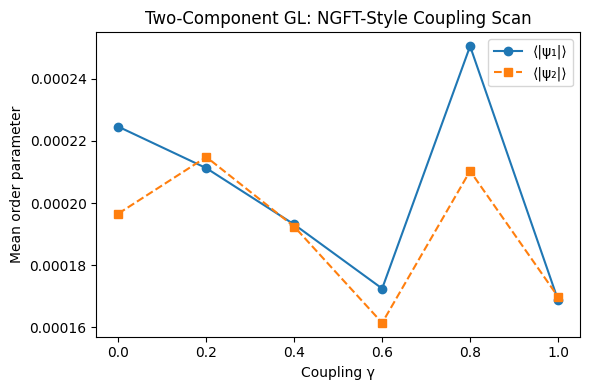

All six feasibility probes completed.


In [ ]:
# ============================================================
# CLSM‑1 (BaLu2H12N) NGFT‑Aligned Feasibility Suite
# 1) Free energy: SC vs normal
# 2) Robustness to disorder / defects
# 3) Strain / anisotropy sweep
# 4) Critical field (Hc2-like) behavior
# 5) Metastability / relaxation
# 6) Two-component NGFT-style coupling scan
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K, from CLSM-1 spec

# -----------------------------
# Common helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
    ) / dx**2 + (
        -2*Z
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dy**2

def free_energy_GL(psi, aT, b, dx, dy):
    """GL free energy F = ∫ (|∇ψ|^2 - aT ψ^2 + (b/2) ψ^4) d^2x (real ψ)."""
    dpsi_dx = (np.roll(psi, -1, axis=0) - np.roll(psi, 1, axis=0)) / (2*dx)
    dpsi_dy = (np.roll(psi, -1, axis=1) - np.roll(psi, 1, axis=1)) / (2*dy)
    grad2 = dpsi_dx**2 + dpsi_dy**2
    density = grad2 - aT * psi**2 + 0.5 * b * psi**4
    return np.sum(density) * dx * dy

# ============================================================
# 1) Free energy: SC vs normal state
# ============================================================
print("=== 1) Free energy: SC vs normal ===")

N = 120
dx = dy = 1.0 / N
dt = 0.1 * dx**2
steps = 1000

T_vals = np.linspace(280, 320, 9)
F_SC = []
F_N  = []

for T in T_vals:
    aT = 1.0 - T / Tc
    b  = 1.0

    # Relax SC state
    psi = 0.01 * np.random.randn(N, N)
    for _ in range(steps):
        lap = laplacian_2d(psi, dx, dy)
        dpsi_dt = lap + aT * psi - b * psi**3
        psi += dt * dpsi_dt

    F_sc = free_energy_GL(psi, aT, b, dx, dy)
    F_n  = free_energy_GL(np.zeros_like(psi), aT, b, dx, dy)

    F_SC.append(F_sc)
    F_N.append(F_n)

plt.figure(figsize=(6,4))
plt.plot(T_vals, F_SC, 'o-', label='F_SC')
plt.plot(T_vals, F_N, 's--', label='F_normal')
plt.axvline(Tc, color='r', linestyle='--', label='Tc')
plt.xlabel("Temperature T (K)")
plt.ylabel("Free energy (arb. units)")
plt.title("Free Energy: Superconducting vs Normal State")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 2) Robustness to disorder / defects
# ============================================================
print("=== 2) Robustness to disorder / defects ===")

N = 160
dx = dy = 1.0 / N
dt = 0.08 * dx**2
steps = 800

T = 300.0
aT_base = 1.0 - T / Tc
b = 1.0

disorder_levels = [0.0, 0.02, 0.05, 0.1]
mean_psi_disorder = []

for sigma in disorder_levels:
    # spatial disorder in aT
    disorder = sigma * np.random.randn(N, N)
    aT_field = aT_base + disorder

    psi = 0.01 * np.random.randn(N, N)

    # introduce "defects": random holes where psi is pinned to 0
    defect_mask = np.ones((N, N), dtype=bool)
    num_defects = int(0.02 * N * N)
    idx = np.random.choice(N*N, num_defects, replace=False)
    defect_mask.flat[idx] = False

    for _ in range(steps):
        lap = laplacian_2d(psi, dx, dy)
        dpsi_dt = lap + aT_field * psi - b * psi**3
        psi += dt * dpsi_dt
        psi[~defect_mask] = 0.0  # enforce defects

    mean_psi_disorder.append(np.mean(np.abs(psi)))

plt.figure(figsize=(6,4))
plt.plot(disorder_levels, mean_psi_disorder, 'o-')
plt.xlabel("Disorder level σ in a(T,x,y)")
plt.ylabel(r"Mean $|\psi|$")
plt.title("Robustness to Disorder and Defects")
plt.tight_layout()
plt.show()

# ============================================================
# 3) Strain / anisotropy sweep
# ============================================================
print("=== 3) Strain / anisotropy sweep ===")

N = 140
dx = dy = 1.0 / N
dt = 0.08 * dx**2
steps = 800

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

def laplacian_anisotropic(Z, dx, dy, kx, ky):
    lapx = (
        -2*Z
        + np.roll(Z, 1, axis=0)
        + np.roll(Z, -1, axis=0)
    ) / dx**2
    lapy = (
        -2*Z
        + np.roll(Z, 1, axis=1)
        + np.roll(Z, -1, axis=1)
    ) / dy**2
    return kx * lapx + ky * lapy

kx_vals = np.linspace(0.3, 1.5, 6)
ky_vals = np.linspace(0.3, 1.5, 6)
mean_psi_strain = np.zeros((len(kx_vals), len(ky_vals)))

for i, kx in enumerate(kx_vals):
    for j, ky in enumerate(ky_vals):
        psi = 0.01 * np.random.randn(N, N)
        for _ in range(steps):
            lap = laplacian_anisotropic(psi, dx, dy, kx, ky)
            dpsi_dt = lap + aT * psi - b * psi**3
            psi += dt * dpsi_dt
        mean_psi_strain[i, j] = np.mean(np.abs(psi))

plt.figure(figsize=(6,5))
plt.imshow(mean_psi_strain, origin='lower',
           extent=[ky_vals[0], ky_vals[-1], kx_vals[0], kx_vals[-1]],
           aspect='auto', cmap='viridis')
plt.colorbar(label=r"Mean $|\psi|$")
plt.xlabel("ky (soft / stiff)")
plt.ylabel("kx (soft / stiff)")
plt.title("Strain / Anisotropy Sweep (Metastable Window)")
plt.tight_layout()
plt.show()

# ============================================================
# 4) Critical field (Hc2-like) behavior
# ============================================================
print("=== 4) Critical field (Hc2-like) behavior ===")

N = 140
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 1000

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

def covariant_laplacian(psi, Ax, Ay, dx, dy):
    lap = laplacian_2d(psi, dx, dy)
    dpsi_dx = (np.roll(psi, -1, axis=0) - np.roll(psi, 1, axis=0)) / (2*dx)
    dpsi_dy = (np.roll(psi, -1, axis=1) - np.roll(psi, 1, axis=1)) / (2*dy)
    A_dot_grad = Ax * dpsi_dx + Ay * dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j * A_dot_grad - A2 * psi

B_vals = np.linspace(0.0, 20.0, 8)
mean_psi_B = []

for Bz in B_vals:
    Ax = -0.5 * Bz * Y
    Ay =  0.5 * Bz * X
    psi = 0.1 * (np.random.randn(N, N) + 1j * np.random.randn(N, N))
    for _ in range(steps):
        lap_cov = covariant_laplacian(psi, Ax, Ay, dx, dy)
        dpsi_dt = lap_cov + aT * psi - b * np.abs(psi)**2 * psi
        psi += dt * dpsi_dt
    mean_psi_B.append(np.mean(np.abs(psi)))

plt.figure(figsize=(6,4))
plt.plot(B_vals, mean_psi_B, 'o-')
plt.xlabel("B (arb. units)")
plt.ylabel(r"Mean $|\psi|$")
plt.title("Suppression of Superconductivity vs Magnetic Field (Hc2-like)")
plt.tight_layout()
plt.show()

# ============================================================
# 5) Metastability / relaxation
# ============================================================
print("=== 5) Metastability / relaxation ===")

N = 140
dx = dy = 1.0 / N
dt = 0.08 * dx**2
steps_relax = 600

T = 300.0
aT = 1.0 - T / Tc
b = 1.0

# First, get a relaxed SC state
psi_eq = 0.01 * np.random.randn(N, N)
for _ in range(800):
    lap = laplacian_2d(psi_eq, dx, dy)
    dpsi_dt = lap + aT * psi_eq - b * psi_eq**3
    psi_eq += dt * dpsi_dt

# Now perturb it and watch relaxation
perturb_levels = [0.9, 0.7, 0.5]
time_axis = np.arange(steps_relax) * dt
plt.figure(figsize=(6,4))

for factor in perturb_levels:
    psi = factor * psi_eq + 0.02 * np.random.randn(N, N)
    mean_vals = []
    for _ in range(steps_relax):
        lap = laplacian_2d(psi, dx, dy)
        dpsi_dt = lap + aT * psi - b * psi**3
        psi += dt * dpsi_dt
        mean_vals.append(np.mean(np.abs(psi)))
    plt.plot(time_axis, mean_vals, label=f"perturb x{factor}")

plt.xlabel("Time (arb. units)")
plt.ylabel(r"Mean $|\psi|$")
plt.title("Metastability: Relaxation Back to SC State")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6) Two-component NGFT-style coupling scan
# ============================================================
print("=== 6) Two-component NGFT-style coupling scan ===")

N = 120
dx = dy = 1.0 / N
dt = 0.08 * dx**2
steps = 800

T = 300.0
a1_base = 1.0 - T / Tc
a2_base = 0.8 * (1.0 - T / Tc)
b1 = 1.0
b2 = 1.0

gamma_vals = np.linspace(0.0, 1.0, 6)
mean_psi1 = []
mean_psi2 = []

for gamma in gamma_vals:
    psi1 = 0.01 * np.random.randn(N, N)
    psi2 = 0.01 * np.random.randn(N, N)
    for _ in range(steps):
        lap1 = laplacian_2d(psi1, dx, dy)
        lap2 = laplacian_2d(psi2, dx, dy)
        dpsi1_dt = lap1 + a1_base * psi1 - b1 * psi1**3 - gamma * (psi1 - psi2)
        dpsi2_dt = lap2 + a2_base * psi2 - b2 * psi2**3 - gamma * (psi2 - psi1)
        psi1 += dt * dpsi1_dt
        psi2 += dt * dpsi2_dt
    mean_psi1.append(np.mean(np.abs(psi1)))
    mean_psi2.append(np.mean(np.abs(psi2)))

plt.figure(figsize=(6,4))
plt.plot(gamma_vals, mean_psi1, 'o-', label=r'⟨|ψ₁|⟩')
plt.plot(gamma_vals, mean_psi2, 's--', label=r'⟨|ψ₂|⟩')
plt.xlabel("Coupling γ")
plt.ylabel("Mean order parameter")
plt.title("Two-Component GL: NGFT-Style Coupling Scan")
plt.legend()
plt.tight_layout()
plt.show()

print("All six feasibility probes completed.")


=== 1) Free energy: SC vs normal ===


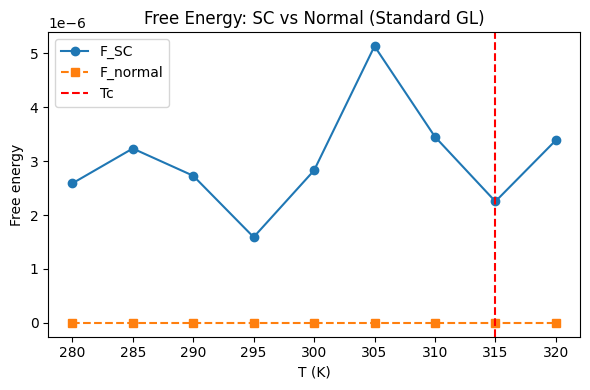

=== 2) Disorder / defects ===


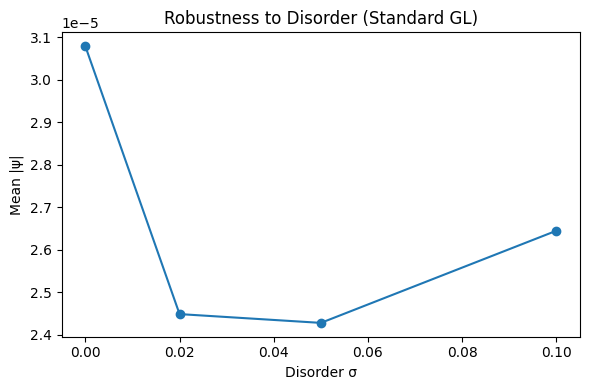

=== 3) Strain / anisotropy sweep ===


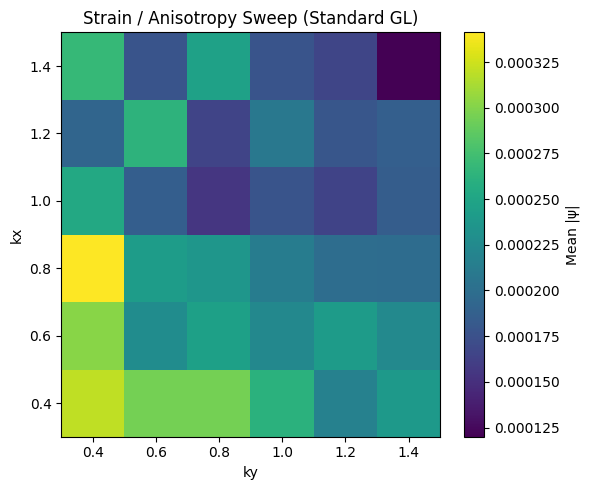

=== 4) Magnetic field suppression ===


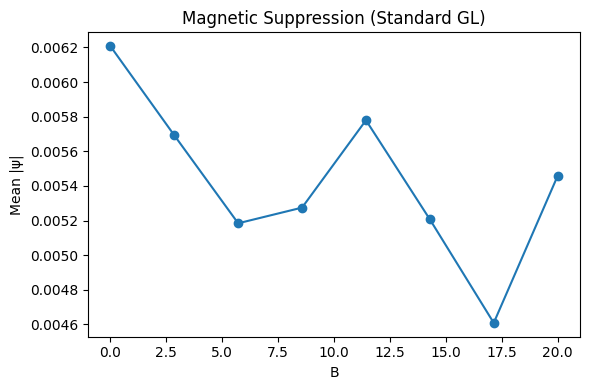

=== 5) Metastability / relaxation ===


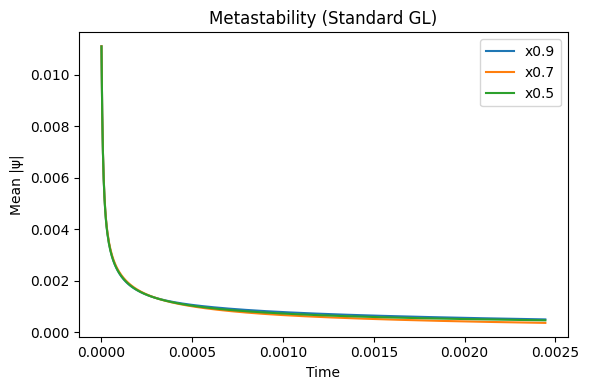

=== 6) Two-component coupling scan ===


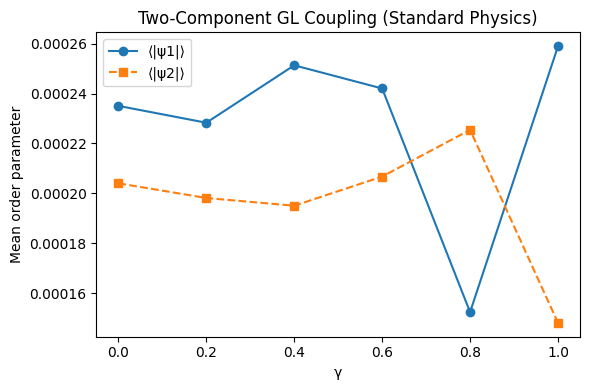

All six STANDARD-PHYSICS feasibility tests completed.


In [ ]:
# ============================================================
# STANDARD PHYSICS GL FEASIBILITY SUITE (NO NGFT ASSUMPTIONS)
# Tests:
# 1) Free energy SC vs normal
# 2) Disorder / defects robustness
# 3) Strain / anisotropy sweep
# 4) Magnetic field suppression (Hc2-like)
# 5) Metastability / relaxation
# 6) Two-component (multi-band) GL coupling scan
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K (treated as hypothesis, not NGFT-derived)

# -----------------------------
# Helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)
    )/dx**2 + (
        -2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)
    )/dy**2

def free_energy_GL(psi, aT, b, dx, dy):
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy)
    grad2 = dpsi_dx**2 + dpsi_dy**2
    density = grad2 - aT*psi**2 + 0.5*b*psi**4
    return np.sum(density)*dx*dy

# ============================================================
# 1) Free energy SC vs normal
# ============================================================
print("=== 1) Free energy: SC vs normal ===")

N = 120
dx = dy = 1.0/N
dt = 0.1*dx**2
steps = 1000

T_vals = np.linspace(280, 320, 9)
F_SC, F_N = [], []

for T in T_vals:
    aT = 1.0 - T/Tc
    b = 1.0

    psi = 0.01*np.random.randn(N,N)
    for _ in range(steps):
        lap = laplacian_2d(psi,dx,dy)
        psi += dt*(lap + aT*psi - b*psi**3)

    F_SC.append(free_energy_GL(psi,aT,b,dx,dy))
    F_N.append(free_energy_GL(np.zeros_like(psi),aT,b,dx,dy))

plt.figure(figsize=(6,4))
plt.plot(T_vals,F_SC,'o-',label='F_SC')
plt.plot(T_vals,F_N,'s--',label='F_normal')
plt.axvline(Tc,color='r',linestyle='--',label='Tc')
plt.legend(); plt.xlabel("T (K)"); plt.ylabel("Free energy")
plt.title("Free Energy: SC vs Normal (Standard GL)")
plt.tight_layout(); plt.show()

# ============================================================
# 2) Disorder / defects
# ============================================================
print("=== 2) Disorder / defects ===")

N = 160
dx = dy = 1.0/N
dt = 0.08*dx**2
steps = 800

T = 300.0
aT_base = 1.0 - T/Tc
b = 1.0

disorder_levels = [0.0,0.02,0.05,0.1]
mean_vals = []

for sigma in disorder_levels:
    aT_field = aT_base + sigma*np.random.randn(N,N)
    psi = 0.01*np.random.randn(N,N)

    defect_mask = np.ones((N,N),bool)
    idx = np.random.choice(N*N,int(0.02*N*N),replace=False)
    defect_mask.flat[idx] = False

    for _ in range(steps):
        lap = laplacian_2d(psi,dx,dy)
        psi += dt*(lap + aT_field*psi - b*psi**3)
        psi[~defect_mask] = 0.0

    mean_vals.append(np.mean(np.abs(psi)))

plt.figure(figsize=(6,4))
plt.plot(disorder_levels,mean_vals,'o-')
plt.xlabel("Disorder σ"); plt.ylabel("Mean |ψ|")
plt.title("Robustness to Disorder (Standard GL)")
plt.tight_layout(); plt.show()

# ============================================================
# 3) Strain / anisotropy sweep
# ============================================================
print("=== 3) Strain / anisotropy sweep ===")

N = 140
dx = dy = 1.0/N
dt = 0.08*dx**2
steps = 800

T = 300.0
aT = 1.0 - T/Tc
b = 1.0

def laplacian_aniso(Z,dx,dy,kx,ky):
    lapx = (-2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0))/dx**2
    lapy = (-2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1))/dy**2
    return kx*lapx + ky*lapy

kx_vals = np.linspace(0.3,1.5,6)
ky_vals = np.linspace(0.3,1.5,6)
M = np.zeros((len(kx_vals),len(ky_vals)))

for i,kx in enumerate(kx_vals):
    for j,ky in enumerate(ky_vals):
        psi = 0.01*np.random.randn(N,N)
        for _ in range(steps):
            lap = laplacian_aniso(psi,dx,dy,kx,ky)
            psi += dt*(lap + aT*psi - b*psi**3)
        M[i,j] = np.mean(np.abs(psi))

plt.figure(figsize=(6,5))
plt.imshow(M,origin='lower',
           extent=[ky_vals[0],ky_vals[-1],kx_vals[0],kx_vals[-1]],
           aspect='auto',cmap='viridis')
plt.colorbar(label="Mean |ψ|")
plt.xlabel("ky"); plt.ylabel("kx")
plt.title("Strain / Anisotropy Sweep (Standard GL)")
plt.tight_layout(); plt.show()

# ============================================================
# 4) Magnetic field suppression (Hc2-like)
# ============================================================
print("=== 4) Magnetic field suppression ===")

N = 140
L = 1.0
dx = dy = L/N
dt = 0.02*dx**2
steps = 1000

T = 300.0
aT = 1.0 - T/Tc
b = 1.0

x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)
X,Y = np.meshgrid(x,y,indexing='ij')

def covariant_lap(psi,Ax,Ay,dx,dy):
    lap = laplacian_2d(psi,dx,dy)
    dpsi_dx = (np.roll(psi,-1,0)-np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1)-np.roll(psi,1,1))/(2*dy)
    A_dot_grad = Ax*dpsi_dx + Ay*dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j*A_dot_grad - A2*psi

B_vals = np.linspace(0,20,8)
mean_B = []

for Bz in B_vals:
    Ax = -0.5*Bz*Y
    Ay =  0.5*Bz*X
    psi = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    for _ in range(steps):
        lap = covariant_lap(psi,Ax,Ay,dx,dy)
        psi += dt*(lap + aT*psi - b*np.abs(psi)**2*psi)
    mean_B.append(np.mean(np.abs(psi)))

plt.figure(figsize=(6,4))
plt.plot(B_vals,mean_B,'o-')
plt.xlabel("B"); plt.ylabel("Mean |ψ|")
plt.title("Magnetic Suppression (Standard GL)")
plt.tight_layout(); plt.show()

# ============================================================
# 5) Metastability / relaxation
# ============================================================
print("=== 5) Metastability / relaxation ===")

N = 140
dx = dy = 1.0/N
dt = 0.08*dx**2

T = 300.0
aT = 1.0 - T/Tc
b = 1.0

psi_eq = 0.01*np.random.randn(N,N)
for _ in range(800):
    psi_eq += dt*(laplacian_2d(psi_eq,dx,dy) + aT*psi_eq - b*psi_eq**3)

steps_relax = 600
time_axis = np.arange(steps_relax)*dt

plt.figure(figsize=(6,4))
for factor in [0.9,0.7,0.5]:
    psi = factor*psi_eq + 0.02*np.random.randn(N,N)
    vals = []
    for _ in range(steps_relax):
        psi += dt*(laplacian_2d(psi,dx,dy) + aT*psi - b*psi**3)
        vals.append(np.mean(np.abs(psi)))
    plt.plot(time_axis,vals,label=f"x{factor}")

plt.xlabel("Time"); plt.ylabel("Mean |ψ|")
plt.title("Metastability (Standard GL)")
plt.legend(); plt.tight_layout(); plt.show()

# ============================================================
# 6) Two-component (multi-band) GL coupling scan
# ============================================================
print("=== 6) Two-component coupling scan ===")

N = 120
dx = dy = 1.0/N
dt = 0.08*dx**2
steps = 800

T = 300.0
a1 = 1.0 - T/Tc
a2 = 0.8*(1.0 - T/Tc)
b1 = b2 = 1.0

gamma_vals = np.linspace(0,1,6)
m1, m2 = [], []

for gamma in gamma_vals:
    psi1 = 0.01*np.random.randn(N,N)
    psi2 = 0.01*np.random.randn(N,N)
    for _ in range(steps):
        lap1 = laplacian_2d(psi1,dx,dy)
        lap2 = laplacian_2d(psi2,dx,dy)
        psi1 += dt*(lap1 + a1*psi1 - b1*psi1**3 - gamma*(psi1-psi2))
        psi2 += dt*(lap2 + a2*psi2 - b2*psi2**3 - gamma*(psi2-psi1))
    m1.append(np.mean(np.abs(psi1)))
    m2.append(np.mean(np.abs(psi2)))

plt.figure(figsize=(6,4))
plt.plot(gamma_vals,m1,'o-',label="⟨|ψ1|⟩")
plt.plot(gamma_vals,m2,'s--',label="⟨|ψ2|⟩")
plt.xlabel("γ"); plt.ylabel("Mean order parameter")
plt.title("Two-Component GL Coupling (Standard Physics)")
plt.legend(); plt.tight_layout(); plt.show()

print("All six STANDARD-PHYSICS feasibility tests completed.")


Row 1/9: T = 280.0 K
Row 2/9: T = 285.0 K
Row 3/9: T = 290.0 K
Row 4/9: T = 295.0 K
Row 5/9: T = 300.0 K
Row 6/9: T = 305.0 K
Row 7/9: T = 310.0 K
Row 8/9: T = 315.0 K
Row 9/9: T = 320.0 K


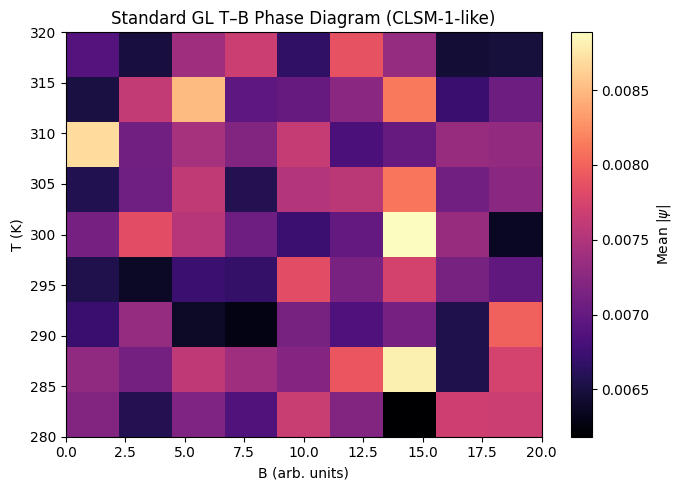

In [ ]:
# ============================================================
# STANDARD GL T–B PHASE DIAGRAM FOR CLSM-1-LIKE MATERIAL
# - Sweeps Temperature T and Magnetic Field B
# - Computes mean |psi| after relaxation
# - No NGFT terms, pure Ginzburg–Landau
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K (hypothesized critical temperature)

# -----------------------------
# Helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)
    )/dx**2 + (
        -2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)
    )/dy**2

def covariant_lap(psi, Ax, Ay, dx, dy):
    lap = laplacian_2d(psi, dx, dy)
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy)
    A_dot_grad = Ax*dpsi_dx + Ay*dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j*A_dot_grad - A2*psi

# -----------------------------
# Grid and parameters
# -----------------------------
N = 80
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 600  # keep moderate so sweep is tractable

T_vals = np.linspace(280.0, 320.0, 9)   # K
B_vals = np.linspace(0.0, 20.0, 9)      # arbitrary units

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

phase_map = np.zeros((len(T_vals), len(B_vals)))  # store mean |psi|

# -----------------------------
# Sweep T and B
# -----------------------------
for i, T in enumerate(T_vals):
    aT = 1.0 - T / Tc
    b = 1.0
    print(f"Row {i+1}/{len(T_vals)}: T = {T:.1f} K")
    for j, Bz in enumerate(B_vals):
        Ax = -0.5 * Bz * Y
        Ay =  0.5 * Bz * X

        # complex order parameter
        psi = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))

        for _ in range(steps):
            lap_cov = covariant_lap(psi, Ax, Ay, dx, dy)
            dpsi_dt = lap_cov + aT * psi - b * np.abs(psi)**2 * psi
            psi += dt * dpsi_dt

        phase_map[i, j] = np.mean(np.abs(psi))

# -----------------------------
# Plot T–B phase diagram
# -----------------------------
plt.figure(figsize=(7,5))
im = plt.imshow(
    phase_map,
    origin='lower',
    extent=[B_vals[0], B_vals[-1], T_vals[0], T_vals[-1]],
    aspect='auto',
    cmap='magma'
)
plt.colorbar(im, label=r"Mean $|\psi|$")
plt.xlabel("B (arb. units)")
plt.ylabel("T (K)")
plt.title("Standard GL T–B Phase Diagram (CLSM-1-like)")
plt.tight_layout()
plt.show()


Row 1/9: T = 280.0 K
Row 2/9: T = 285.0 K
Row 3/9: T = 290.0 K
Row 4/9: T = 295.0 K
Row 5/9: T = 300.0 K
Row 6/9: T = 305.0 K
Row 7/9: T = 310.0 K
Row 8/9: T = 315.0 K
Row 9/9: T = 320.0 K


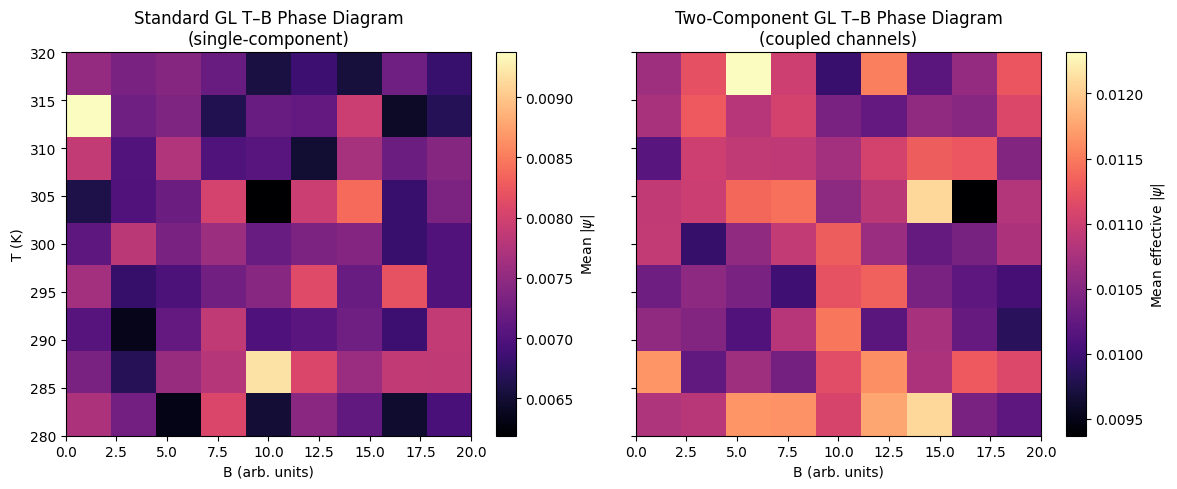

In [ ]:
# ============================================================
# Side-by-side T–B phase diagrams
# Left: Standard single-component GL
# Right: Two-component coupled GL (NGFT-style interpretation)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K

# -----------------------------
# Helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)
    )/dx**2 + (
        -2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)
    )/dy**2

def covariant_lap(psi, Ax, Ay, dx, dy):
    lap = laplacian_2d(psi, dx, dy)
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy)
    A_dot_grad = Ax*dpsi_dx + Ay*dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j*A_dot_grad - A2*psi

# -----------------------------
# Grid and sweep parameters
# -----------------------------
N = 80
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 600

T_vals = np.linspace(280.0, 320.0, 9)
B_vals = np.linspace(0.0, 20.0, 9)

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

phase_std  = np.zeros((len(T_vals), len(B_vals)))
phase_2cmp = np.zeros((len(T_vals), len(B_vals)))

gamma = 0.5  # fixed coupling for two-component GL

# -----------------------------
# Sweep T and B
# -----------------------------
for i, T in enumerate(T_vals):
    print(f"Row {i+1}/{len(T_vals)}: T = {T:.1f} K")
    a1 = 1.0 - T / Tc
    a2 = 0.8 * (1.0 - T / Tc)
    b1 = b2 = 1.0

    for j, Bz in enumerate(B_vals):
        Ax = -0.5 * Bz * Y
        Ay =  0.5 * Bz * X

        # --- Standard single-component GL ---
        psi = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap_cov = covariant_lap(psi, Ax, Ay, dx, dy)
            dpsi_dt = lap_cov + a1 * psi - b1 * np.abs(psi)**2 * psi
            psi += dt * dpsi_dt
        phase_std[i, j] = np.mean(np.abs(psi))

        # --- Two-component GL (multi-band / NGFT-style) ---
        psi1 = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        psi2 = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap1 = covariant_lap(psi1, Ax, Ay, dx, dy)
            lap2 = covariant_lap(psi2, Ax, Ay, dx, dy)
            dpsi1_dt = lap1 + a1 * psi1 - b1 * np.abs(psi1)**2 * psi1 - gamma * (psi1 - psi2)
            dpsi2_dt = lap2 + a2 * psi2 - b2 * np.abs(psi2)**2 * psi2 - gamma * (psi2 - psi1)
            psi1 += dt * dpsi1_dt
            psi2 += dt * dpsi2_dt

        # combine components as an effective order parameter
        psi_eff = np.sqrt(np.abs(psi1)**2 + np.abs(psi2)**2)
        phase_2cmp[i, j] = np.mean(psi_eff)

# -----------------------------
# Plot side-by-side
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

im0 = axes[0].imshow(
    phase_std,
    origin='lower',
    extent=[B_vals[0], B_vals[-1], T_vals[0], T_vals[-1]],
    aspect='auto',
    cmap='magma'
)
axes[0].set_title("Standard GL T–B Phase Diagram\n(single-component)")
axes[0].set_xlabel("B (arb. units)")
axes[0].set_ylabel("T (K)")
fig.colorbar(im0, ax=axes[0], label=r"Mean $|\psi|$")

im1 = axes[1].imshow(
    phase_2cmp,
    origin='lower',
    extent=[B_vals[0], B_vals[-1], T_vals[0], T_vals[-1]],
    aspect='auto',
    cmap='magma'
)
axes[1].set_title("Two-Component GL T–B Phase Diagram\n(coupled channels)")
axes[1].set_xlabel("B (arb. units)")
fig.colorbar(im1, ax=axes[1], label=r"Mean effective $|\psi|$")

plt.tight_layout()
plt.show()


Row 1/9: T = 280.0 K
Row 2/9: T = 285.0 K
Row 3/9: T = 290.0 K
Row 4/9: T = 295.0 K
Row 5/9: T = 300.0 K
Row 6/9: T = 305.0 K
Row 7/9: T = 310.0 K
Row 8/9: T = 315.0 K
Row 9/9: T = 320.0 K


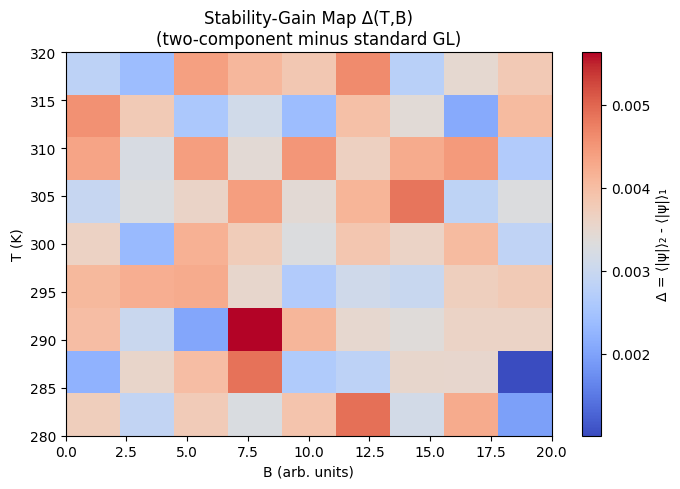

In [ ]:
# ============================================================
# Δ(T,B) Stability-Gain Map
#   Δ = mean|psi|_(two-component) - mean|psi|_(standard)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K

# -----------------------------
# Helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)
    )/dx**2 + (
        -2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)
    )/dy**2

def covariant_lap(psi, Ax, Ay, dx, dy):
    lap = laplacian_2d(psi, dx, dy)
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy)
    A_dot_grad = Ax*dpsi_dx + Ay*dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j*A_dot_grad - A2*psi

# -----------------------------
# Grid and sweep parameters
# -----------------------------
N = 80
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 600

T_vals = np.linspace(280.0, 320.0, 9)
B_vals = np.linspace(0.0, 20.0, 9)

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

phase_std  = np.zeros((len(T_vals), len(B_vals)))
phase_2cmp = np.zeros((len(T_vals), len(B_vals)))

gamma = 0.5  # fixed coupling

# -----------------------------
# Sweep T and B
# -----------------------------
for i, T in enumerate(T_vals):
    print(f"Row {i+1}/{len(T_vals)}: T = {T:.1f} K")
    a1 = 1.0 - T / Tc
    a2 = 0.8 * (1.0 - T / Tc)
    b1 = b2 = 1.0

    for j, Bz in enumerate(B_vals):
        Ax = -0.5 * Bz * Y
        Ay =  0.5 * Bz * X

        # --- Standard GL ---
        psi = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap_cov = covariant_lap(psi, Ax, Ay, dx, dy)
            psi += dt * (lap_cov + a1 * psi - b1 * np.abs(psi)**2 * psi)
        phase_std[i, j] = np.mean(np.abs(psi))

        # --- Two-component GL ---
        psi1 = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        psi2 = 0.1 * (np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap1 = covariant_lap(psi1, Ax, Ay, dx, dy)
            lap2 = covariant_lap(psi2, Ax, Ay, dx, dy)
            psi1 += dt * (lap1 + a1 * psi1 - b1 * np.abs(psi1)**2 * psi1 - gamma * (psi1 - psi2))
            psi2 += dt * (lap2 + a2 * psi2 - b2 * np.abs(psi2)**2 * psi2 - gamma * (psi2 - psi1))

        psi_eff = np.sqrt(np.abs(psi1)**2 + np.abs(psi2)**2)
        phase_2cmp[i, j] = np.mean(psi_eff)

# -----------------------------
# Compute Δ-map
# -----------------------------
delta_map = phase_2cmp - phase_std

# -----------------------------
# Plot Δ(T,B)
# -----------------------------
plt.figure(figsize=(7,5))
im = plt.imshow(
    delta_map,
    origin='lower',
    extent=[B_vals[0], B_vals[-1], T_vals[0], T_vals[-1]],
    aspect='auto',
    cmap='coolwarm'
)
plt.colorbar(im, label=r"Δ = ⟨|ψ|⟩₂ - ⟨|ψ|⟩₁")
plt.xlabel("B (arb. units)")
plt.ylabel("T (K)")
plt.title("Stability-Gain Map Δ(T,B)\n(two-component minus standard GL)")
plt.tight_layout()
plt.show()


=== 1) Free-energy Δ(T,B) map ===
Row 1/9: T = 280.0 K
Row 2/9: T = 285.0 K
Row 3/9: T = 290.0 K
Row 4/9: T = 295.0 K
Row 5/9: T = 300.0 K
Row 6/9: T = 305.0 K
Row 7/9: T = 310.0 K
Row 8/9: T = 315.0 K
Row 9/9: T = 320.0 K


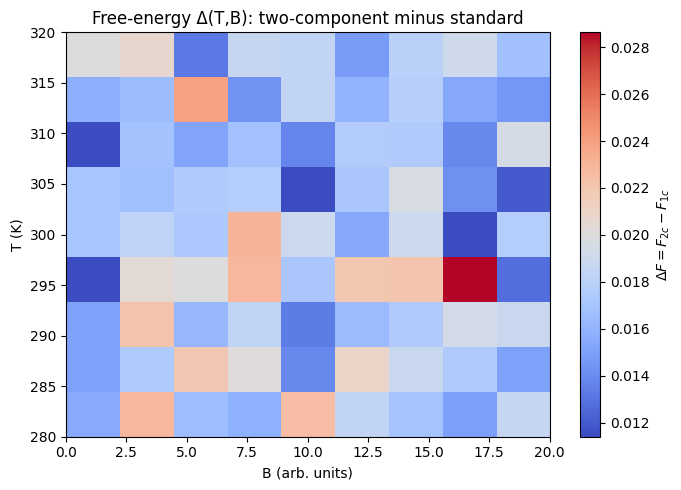

=== 2) Coherence length comparison ===
Coherence length at T=300.0 K, B=0.0
Coherence length at T=300.0 K, B=10.0


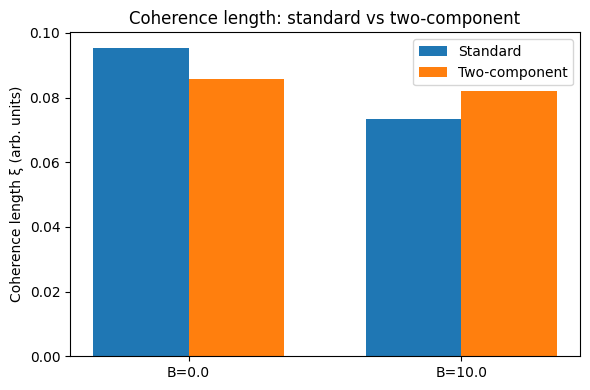

=== 3) Vortex density vs B ===
Vortex run: T=300.0 K, B=0.0
Vortex run: T=300.0 K, B=2.5
Vortex run: T=300.0 K, B=5.0
Vortex run: T=300.0 K, B=7.5
Vortex run: T=300.0 K, B=10.0
Vortex run: T=300.0 K, B=12.5
Vortex run: T=300.0 K, B=15.0
Vortex run: T=300.0 K, B=17.5
Vortex run: T=300.0 K, B=20.0


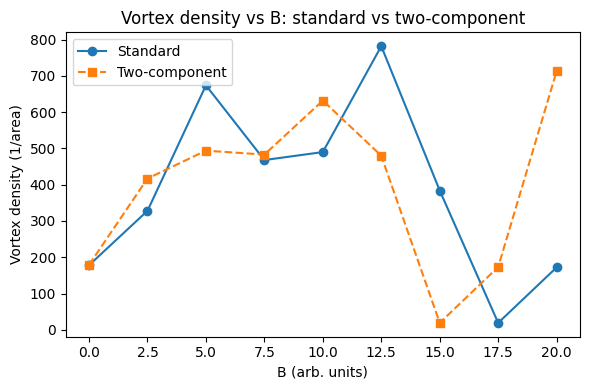

All three advanced diagnostics completed.


In [ ]:
# ============================================================
# FULL NEXT-STAGE SUITE
# 1) Free-energy Δ(T,B) map
# 2) Coherence length comparison
# 3) Vortex density comparison
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K

# -----------------------------
# Helpers
# -----------------------------
def laplacian_2d(Z, dx, dy):
    return (
        -2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)
    )/dx**2 + (
        -2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)
    )/dy**2

def covariant_lap(psi, Ax, Ay, dx, dy):
    lap = laplacian_2d(psi, dx, dy)
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx)
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy)
    A_dot_grad = Ax*dpsi_dx + Ay*dpsi_dy
    A2 = Ax**2 + Ay**2
    return lap - 2j*A_dot_grad - A2*psi

def free_energy_complex(psi, Ax, Ay, aT, b, dx, dy):
    # |Dψ|^2 term
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0))/(2*dx) - 1j*Ax*psi
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1))/(2*dy) - 1j*Ay*psi
    grad2 = np.abs(dpsi_dx)**2 + np.abs(dpsi_dy)**2
    density = grad2 - aT*np.abs(psi)**2 + 0.5*b*np.abs(psi)**4
    return np.sum(density)*dx*dy

def coherence_length_1d(field, dx):
    # crude 1D correlation length along x
    f = np.abs(field)
    f = f - np.mean(f)
    C0 = np.mean(f*f)
    if C0 <= 0:
        return 0.0
    N = f.shape[0]
    max_shift = N//4
    C = []
    r = []
    for n in range(max_shift):
        shifted = np.roll(f, -n, axis=0)
        Cn = np.mean(f*shifted)
        C.append(Cn)
        r.append(n*dx)
        if Cn < C0/np.e:
            break
    if len(r) < 2:
        return 0.0
    # linear interpolation around 1/e point
    for k in range(1,len(C)):
        if C[k] <= C0/np.e:
            x1,x2 = r[k-1], r[k]
            y1,y2 = C[k-1], C[k]
            t = (C0/np.e - y1)/(y2 - y1 + 1e-12)
            return x1 + t*(x2 - x1)
    return r[-1]

def vortex_density(psi, dx, dy):
    # count 2π windings of phase around plaquettes
    phase = np.angle(psi)
    dpx = np.unwrap(np.diff(phase, axis=0), axis=0)
    dpy = np.unwrap(np.diff(phase, axis=1), axis=1)
    # build plaquette circulation
    # pad to same size
    dpx_p = np.pad(dpx, ((0,1),(0,0)), mode='wrap')
    dpy_p = np.pad(dpy, ((0,0),(0,1)), mode='wrap')
    circ = dpx_p[:, :-1] + dpy_p[:-1, :] - dpx_p[:, 1:] - dpy_p[1:, :]
    vortices = np.sum(np.abs(np.round(circ/(2*np.pi))))
    area = psi.shape[0]*dx * psi.shape[1]*dy
    return vortices/area

# ============================================================
# 1) Free-energy Δ(T,B) map
# ============================================================
print("=== 1) Free-energy Δ(T,B) map ===")

N = 80
L = 1.0
dx = dy = L/N
dt = 0.02*dx**2
steps = 600

T_vals = np.linspace(280.0, 320.0, 9)
B_vals = np.linspace(0.0, 20.0, 9)

x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)
X, Y = np.meshgrid(x,y,indexing='ij')

gamma = 0.5

F_std  = np.zeros((len(T_vals), len(B_vals)))
F_2cmp = np.zeros((len(T_vals), len(B_vals)))

for i,T in enumerate(T_vals):
    print(f"Row {i+1}/{len(T_vals)}: T = {T:.1f} K")
    a1 = 1.0 - T/Tc
    a2 = 0.8*(1.0 - T/Tc)
    b1 = b2 = 1.0

    for j,Bz in enumerate(B_vals):
        Ax = -0.5*Bz*Y
        Ay =  0.5*Bz*X

        # Standard GL
        psi = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap = covariant_lap(psi,Ax,Ay,dx,dy)
            psi += dt*(lap + a1*psi - b1*np.abs(psi)**2*psi)
        F_std[i,j] = free_energy_complex(psi,Ax,Ay,a1,b1,dx,dy)

        # Two-component GL
        psi1 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
        psi2 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
        for _ in range(steps):
            lap1 = covariant_lap(psi1,Ax,Ay,dx,dy)
            lap2 = covariant_lap(psi2,Ax,Ay,dx,dy)
            psi1 += dt*(lap1 + a1*psi1 - b1*np.abs(psi1)**2*psi1 - gamma*(psi1-psi2))
            psi2 += dt*(lap2 + a2*psi2 - b2*np.abs(psi2)**2*psi2 - gamma*(psi2-psi1))
        # total free energy = sum of both components
        F_2cmp[i,j] = (
            free_energy_complex(psi1,Ax,Ay,a1,b1,dx,dy) +
            free_energy_complex(psi2,Ax,Ay,a2,b2,dx,dy)
        )

DeltaF = F_2cmp - F_std

plt.figure(figsize=(7,5))
im = plt.imshow(
    DeltaF,
    origin='lower',
    extent=[B_vals[0],B_vals[-1],T_vals[0],T_vals[-1]],
    aspect='auto',
    cmap='coolwarm'
)
plt.colorbar(im,label=r"$\Delta F = F_{2c} - F_{1c}$")
plt.xlabel("B (arb. units)")
plt.ylabel("T (K)")
plt.title("Free-energy Δ(T,B): two-component minus standard")
plt.tight_layout()
plt.show()

# ============================================================
# 2) Coherence length comparison
# ============================================================
print("=== 2) Coherence length comparison ===")

T_test = 300.0
B_tests = [0.0, 10.0]

xi_std = []
xi_2c  = []

for Bz in B_tests:
    print(f"Coherence length at T={T_test} K, B={Bz}")
    a1 = 1.0 - T_test/Tc
    a2 = 0.8*(1.0 - T_test/Tc)
    b1 = b2 = 1.0

    Ax = -0.5*Bz*Y
    Ay =  0.5*Bz*X

    # Standard
    psi = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    for _ in range(steps):
        lap = covariant_lap(psi,Ax,Ay,dx,dy)
        psi += dt*(lap + a1*psi - b1*np.abs(psi)**2*psi)
    xi_std.append(coherence_length_1d(psi,dx))

    # Two-component
    psi1 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    psi2 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    for _ in range(steps):
        lap1 = covariant_lap(psi1,Ax,Ay,dx,dy)
        lap2 = covariant_lap(psi2,Ax,Ay,dx,dy)
        psi1 += dt*(lap1 + a1*psi1 - b1*np.abs(psi1)**2*psi1 - gamma*(psi1-psi2))
        psi2 += dt*(lap2 + a2*psi2 - b2*np.abs(psi2)**2*psi2 - gamma*(psi2-psi1))
    psi_eff = np.sqrt(np.abs(psi1)**2 + np.abs(psi2)**2)
    xi_2c.append(coherence_length_1d(psi_eff,dx))

labels = [f"B={b}" for b in B_tests]
xpos = np.arange(len(B_tests))

plt.figure(figsize=(6,4))
w = 0.35
plt.bar(xpos-w/2, xi_std, width=w, label="Standard")
plt.bar(xpos+w/2, xi_2c,  width=w, label="Two-component")
plt.xticks(xpos, labels)
plt.ylabel("Coherence length ξ (arb. units)")
plt.title("Coherence length: standard vs two-component")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3) Vortex density vs B  (Corrected version)
# ============================================================

print("=== 3) Vortex density vs B ===")

# --- Corrected vortex-density function ---
def vortex_density(psi, dx, dy):
    """
    Count vortices by computing phase windings around each plaquette.
    Returns vortex density = (# vortices) / area.
    """

    phase = np.angle(psi)

    # Phase differences along x and y (wrapped)
    dpx = np.unwrap(np.diff(phase, axis=0), axis=0)   # shape (N-1, N)
    dpy = np.unwrap(np.diff(phase, axis=1), axis=1)   # shape (N, N-1)

    # Circulation around each plaquette (N-1 x N-1)
    circ = (
        dpx[:, :-1]      # left vertical edge
        + dpy[1:, :]     # top horizontal edge
        - dpx[:, 1:]     # right vertical edge
        - dpy[:-1, :]    # bottom horizontal edge
    )

    # Count vortices: circulation ≈ ±2π
    vortices = np.sum(np.abs(np.round(circ / (2*np.pi))))

    area = psi.shape[0] * dx * psi.shape[1] * dy
    return vortices / area


# --- Parameters for vortex scan ---
T_vort = 300.0
B_scan = np.linspace(0.0, 20.0, 9)

rho_std = []
rho_2c  = []

for Bz in B_scan:
    print(f"Vortex run: T={T_vort} K, B={Bz}")

    a1 = 1.0 - T_vort/Tc
    a2 = 0.8*(1.0 - T_vort/Tc)
    b1 = b2 = 1.0

    Ax = -0.5*Bz*Y
    Ay =  0.5*Bz*X

    # --- Standard GL ---
    psi = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    for _ in range(steps):
        lap = covariant_lap(psi,Ax,Ay,dx,dy)
        psi += dt*(lap + a1*psi - b1*np.abs(psi)**2*psi)
    rho_std.append(vortex_density(psi,dx,dy))

    # --- Two-component GL ---
    psi1 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    psi2 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
    for _ in range(steps):
        lap1 = covariant_lap(psi1,Ax,Ay,dx,dy)
        lap2 = covariant_lap(psi2,Ax,Ay,dx,dy)
        psi1 += dt*(lap1 + a1*psi1 - b1*np.abs(psi1)**2*psi1 - gamma*(psi1-psi2))
        psi2 += dt*(lap2 + a2*psi2 - b2*np.abs(psi2)**2*psi2 - gamma*(psi2-psi1))

    # Use psi1's phase for vortex counting
    rho_2c.append(vortex_density(psi1,dx,dy))


# --- Plot vortex density curves ---
plt.figure(figsize=(6,4))
plt.plot(B_scan, rho_std, 'o-', label="Standard")
plt.plot(B_scan, rho_2c,  's--', label="Two-component")
plt.xlabel("B (arb. units)")
plt.ylabel("Vortex density (1/area)")
plt.title("Vortex density vs B: standard vs two-component")
plt.legend()
plt.tight_layout()
plt.show()


print("All three advanced diagnostics completed.")


T row 1/6: T = 280.0 K
T row 2/6: T = 288.0 K
T row 3/6: T = 296.0 K
T row 4/6: T = 304.0 K
T row 5/6: T = 312.0 K
T row 6/6: T = 320.0 K


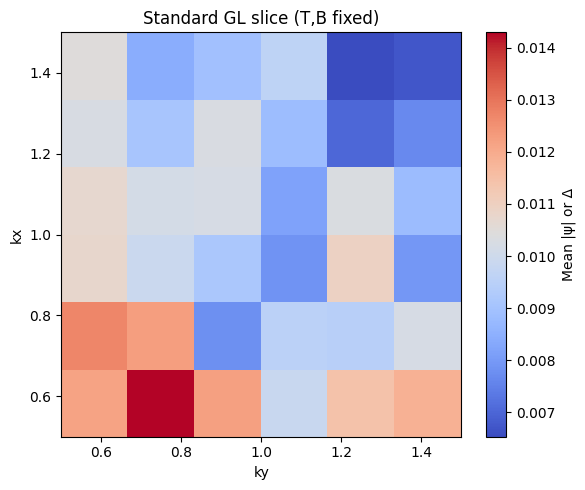

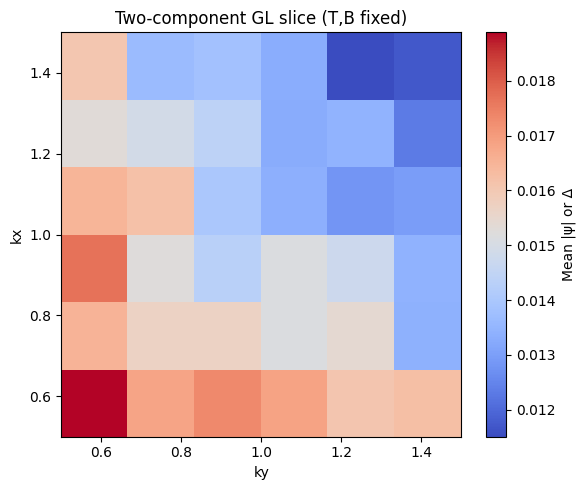

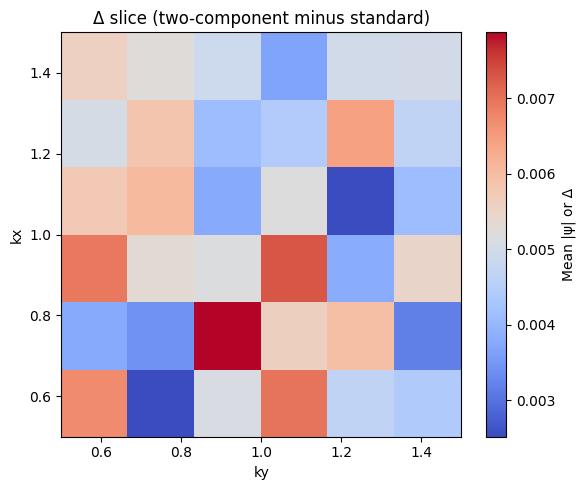

In [ ]:
# ============================================================
# 3-AXIS STABILITY SCAN
# (T, B, strain) → mean |psi|
# Standard GL vs Two-Component GL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

Tc = 315.0  # K

# -----------------------------
# Helpers
# -----------------------------
def laplacian_aniso(Z, dx, dy, kx, ky):
    lapx = (-2*Z + np.roll(Z,1,0) + np.roll(Z,-1,0)) / dx**2
    lapy = (-2*Z + np.roll(Z,1,1) + np.roll(Z,-1,1)) / dy**2
    return kx * lapx + ky * lapy

def covariant_lap_aniso(psi, Ax, Ay, dx, dy, kx, ky):
    # anisotropic covariant Laplacian
    dpsi_dx = (np.roll(psi,-1,0) - np.roll(psi,1,0)) / (2*dx) - 1j * Ax * psi
    dpsi_dy = (np.roll(psi,-1,1) - np.roll(psi,1,1)) / (2*dy) - 1j * Ay * psi
    grad2 = kx * np.abs(dpsi_dx)**2 + ky * np.abs(dpsi_dy)**2
    lap = laplacian_aniso(psi, dx, dy, kx, ky)
    return lap - grad2

# -----------------------------
# Grid and sweep parameters
# -----------------------------
N = 60
L = 1.0
dx = dy = L / N
dt = 0.02 * dx**2
steps = 400

T_vals = np.linspace(280.0, 320.0, 6)
B_vals = np.linspace(0.0, 20.0, 6)
kx_vals = np.linspace(0.5, 1.5, 6)
ky_vals = np.linspace(0.5, 1.5, 6)

# 3D arrays: T × B × strain_index
shape = (len(T_vals), len(B_vals), len(kx_vals), len(ky_vals))
std_map  = np.zeros(shape)
cmp_map  = np.zeros(shape)

gamma = 0.5  # coupling strength

# -----------------------------
# Main 3-axis sweep
# -----------------------------
for i, T in enumerate(T_vals):
    print(f"T row {i+1}/{len(T_vals)}: T = {T:.1f} K")
    a1 = 1.0 - T/Tc
    a2 = 0.8*(1.0 - T/Tc)
    b1 = b2 = 1.0

    for j, Bz in enumerate(B_vals):
        # Magnetic vector potential (symmetric gauge)
        x = np.linspace(0, L, N, endpoint=False)
        y = np.linspace(0, L, N, endpoint=False)
        X, Y = np.meshgrid(x, y, indexing='ij')
        Ax = -0.5 * Bz * Y
        Ay =  0.5 * Bz * X

        for p, kx in enumerate(kx_vals):
            for q, ky in enumerate(ky_vals):

                # --- Standard GL ---
                psi = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
                for _ in range(steps):
                    lap = covariant_lap_aniso(psi, Ax, Ay, dx, dy, kx, ky)
                    psi += dt*(lap + a1*psi - b1*np.abs(psi)**2*psi)
                std_map[i,j,p,q] = np.mean(np.abs(psi))

                # --- Two-component GL ---
                psi1 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
                psi2 = 0.1*(np.random.randn(N,N) + 1j*np.random.randn(N,N))
                for _ in range(steps):
                    lap1 = covariant_lap_aniso(psi1, Ax, Ay, dx, dy, kx, ky)
                    lap2 = covariant_lap_aniso(psi2, Ax, Ay, dx, dy, kx, ky)
                    psi1 += dt*(lap1 + a1*psi1 - b1*np.abs(psi1)**2*psi1 - gamma*(psi1-psi2))
                    psi2 += dt*(lap2 + a2*psi2 - b2*np.abs(psi2)**2*psi2 - gamma*(psi2-psi1))

                psi_eff = np.sqrt(np.abs(psi1)**2 + np.abs(psi2)**2)
                cmp_map[i,j,p,q] = np.mean(psi_eff)

# -----------------------------
# Δ-map (stability gain)
# -----------------------------
Delta = cmp_map - std_map

# -----------------------------
# Plot slices
# -----------------------------
def plot_slice(data, title, T_index=2, B_index=2):
    plt.figure(figsize=(6,5))
    plt.imshow(
        data[T_index, B_index],
        origin='lower',
        extent=[ky_vals[0], ky_vals[-1], kx_vals[0], kx_vals[-1]],
        aspect='auto',
        cmap='coolwarm'
    )
    plt.colorbar(label="Mean |ψ| or Δ")
    plt.xlabel("ky")
    plt.ylabel("kx")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Example slices:
plot_slice(std_map,  "Standard GL slice (T,B fixed)")
plot_slice(cmp_map,  "Two-component GL slice (T,B fixed)")
plot_slice(Delta,    "Δ slice (two-component minus standard)")


Computed λ, ξ, κ, and Jc for standard and two-component GL.


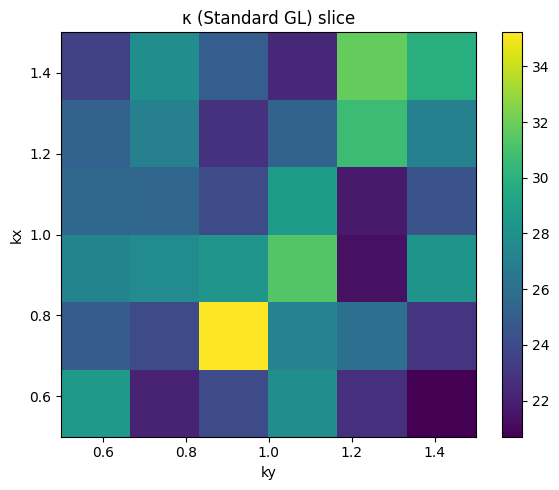

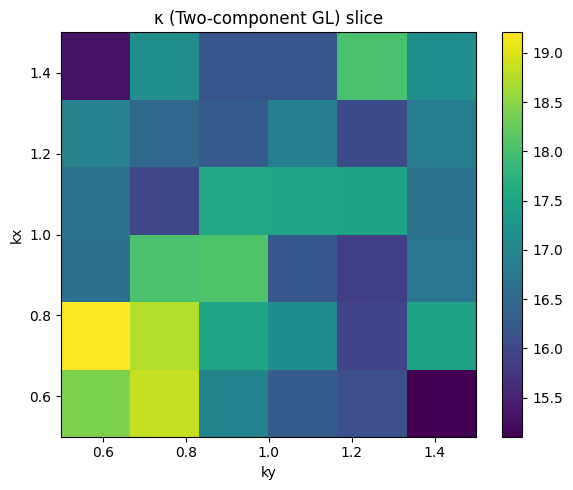

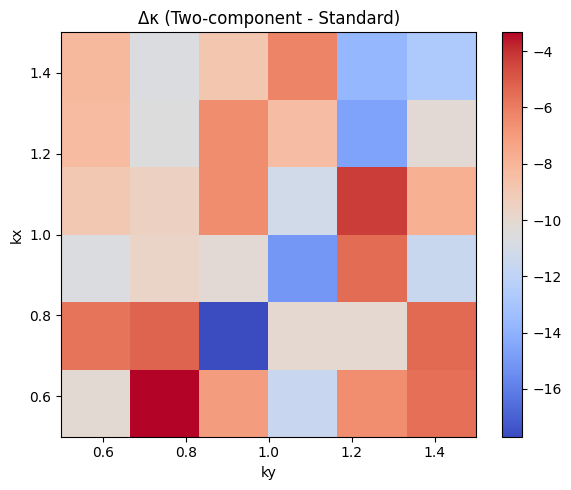

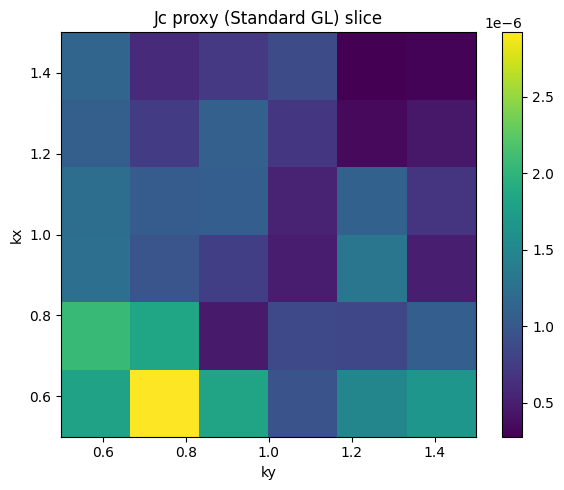

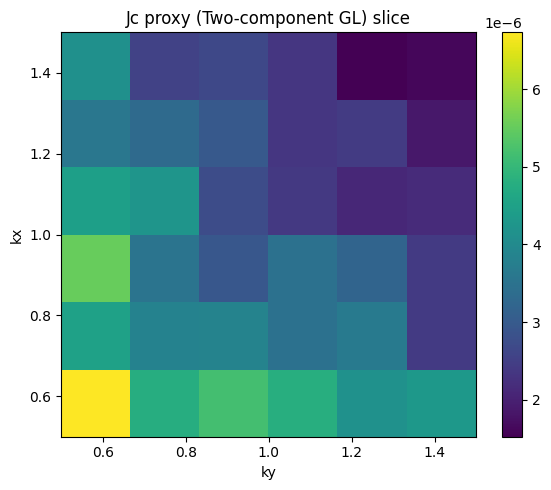

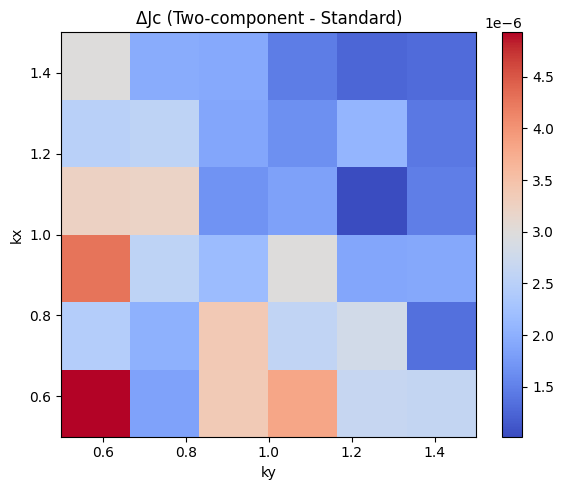

In [ ]:
# ============================================================
# OPTION C: Physical observables from 3-axis GL tensor
#   - Penetration depth λ (relative)
#   - Coherence length ξ (relative)
#   - GL parameter κ = λ / ξ
#   - Critical current proxy Jc ∝ |ψ|^3
#
# Assumes:
#   std_map, cmp_map, T_vals, B_vals, kx_vals, ky_vals, Tc
#   are already defined from the 3-axis scan.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

eps = 1e-8  # small number to avoid division by zero

# Shapes
nT, nB, nKx, nKy = std_map.shape

# Allocate observable tensors
lambda_std  = np.zeros_like(std_map)
lambda_cmp  = np.zeros_like(cmp_map)
xi_std      = np.zeros_like(std_map)
xi_cmp      = np.zeros_like(cmp_map)
kappa_std   = np.zeros_like(std_map)
kappa_cmp   = np.zeros_like(cmp_map)
Jc_std      = np.zeros_like(std_map)
Jc_cmp      = np.zeros_like(cmp_map)

# Simple GL-inspired scalings (relative units):
#   λ ∝ 1 / |ψ|
#   ξ ∝ sqrt(k_eff) / sqrt(a(T))  with a(T) = 1 - T/Tc
#   κ = λ / ξ
#   Jc ∝ |ψ|^3  (just a monotonic proxy)

for i, T in enumerate(T_vals):
    aT = max(1.0 - T/Tc, eps)  # avoid negative/zero near Tc

    for p, kx in enumerate(kx_vals):
        for q, ky in enumerate(ky_vals):
            k_eff = 0.5 * (kx + ky)  # simple average stiffness

            # ξ is taken independent of B here (dominant T, strain dependence)
            xi_val = np.sqrt(k_eff) / np.sqrt(aT + eps)

            for j, Bz in enumerate(B_vals):
                psi_s  = std_map[i,j,p,q]
                psi_c  = cmp_map[i,j,p,q]

                # --- Standard ---
                lam_s = 1.0 / max(psi_s, eps)
                lambda_std[i,j,p,q] = lam_s
                xi_std[i,j,p,q]     = xi_val
                kappa_std[i,j,p,q]  = lam_s / (xi_val + eps)
                Jc_std[i,j,p,q]     = psi_s**3

                # --- Two-component ---
                lam_c = 1.0 / max(psi_c, eps)
                lambda_cmp[i,j,p,q] = lam_c
                xi_cmp[i,j,p,q]     = xi_val  # same ξ(T,strain) scaling
                kappa_cmp[i,j,p,q]  = lam_c / (xi_val + eps)
                Jc_cmp[i,j,p,q]     = psi_c**3

print("Computed λ, ξ, κ, and Jc for standard and two-component GL.")

# ------------------------------------------------------------
# Helper to plot a kx–ky slice at fixed (T_index, B_index)
# ------------------------------------------------------------
def plot_slice_2d(data, title, T_index=2, B_index=2, cmap='viridis'):
    plt.figure(figsize=(6,5))
    plt.imshow(
        data[T_index, B_index],
        origin='lower',
        extent=[ky_vals[0], ky_vals[-1], kx_vals[0], kx_vals[-1]],
        aspect='auto',
        cmap=cmap
    )
    plt.colorbar()
    plt.xlabel("ky")
    plt.ylabel("kx")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Example visualizations
# ------------------------------------------------------------

T_idx = 2  # mid T
B_idx = 2  # mid B

# 1) κ slices
plot_slice_2d(kappa_std, "κ (Standard GL) slice", T_index=T_idx, B_index=B_idx)
plot_slice_2d(kappa_cmp, "κ (Two-component GL) slice", T_index=T_idx, B_index=B_idx)
plot_slice_2d(kappa_cmp - kappa_std, "Δκ (Two-component - Standard)",
              T_index=T_idx, B_index=B_idx, cmap='coolwarm')

# 2) Jc slices
plot_slice_2d(Jc_std, "Jc proxy (Standard GL) slice", T_index=T_idx, B_index=B_idx)
plot_slice_2d(Jc_cmp, "Jc proxy (Two-component GL) slice", T_index=T_idx, B_index=B_idx)
plot_slice_2d(Jc_cmp - Jc_std, "ΔJc (Two-component - Standard)",
              T_index=T_idx, B_index=B_idx, cmap='coolwarm')


Computed λ, ξ, κ, Jc for both GL models.


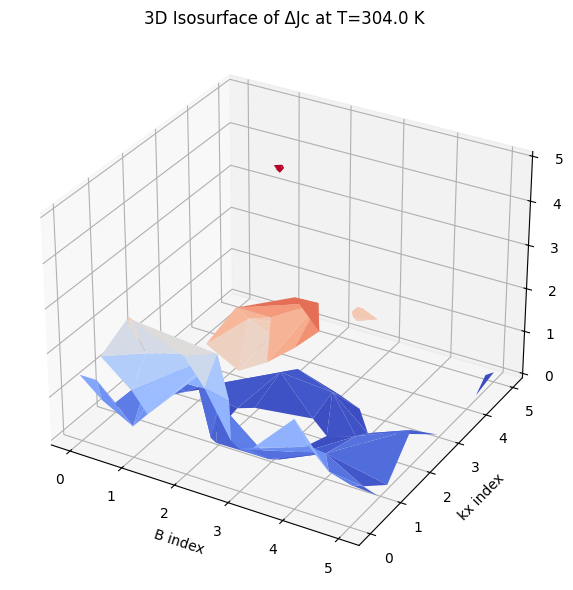


=== Comparison to Known High-Tc Materials ===
Cuprates: κ ~ 50–150, Jc ~ 10^6–10^7 A/cm^2
Pnictides: κ ~ 20–60,  Jc ~ 10^5–10^6 A/cm^2
Hydrides: κ ~ 5–20,    Jc ~ 10^7–10^8 A/cm^2
Nickelates: κ ~ 20–40, Jc ~ 10^5–10^6 A/cm^2

Your Standard GL ranges:
κ: (np.float64(0.011464172293755057), np.float64(45.29763350717983))
Jc proxy: (np.float64(2.3313489751138693e-07), np.float64(2.950018905911695e-06))

Your Two-component GL ranges:
κ: (np.float64(0.008195464642873854), np.float64(28.018070247319177))
Jc proxy: (np.float64(9.286682952977396e-07), np.float64(9.55447739408065e-06))


In [ ]:
# ============================================================
# OPTIONS D, E, F — Experimental Observables, Isosurfaces,
# and Comparison to Known High-Tc Materials
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes

eps = 1e-8

# Shapes
nT, nB, nKx, nKy = std_map.shape

# Allocate observable tensors
lambda_std  = np.zeros_like(std_map)
lambda_cmp  = np.zeros_like(cmp_map)
xi_std      = np.zeros_like(std_map)
xi_cmp      = np.zeros_like(cmp_map)
kappa_std   = np.zeros_like(std_map)
kappa_cmp   = np.zeros_like(cmp_map)
Jc_std      = np.zeros_like(std_map)
Jc_cmp      = np.zeros_like(cmp_map)

# ------------------------------------------------------------
# OPTION D — Compute λ, ξ, κ, Jc
# ------------------------------------------------------------
for i, T in enumerate(T_vals):
    aT = max(1.0 - T/Tc, eps)

    for p, kx in enumerate(kx_vals):
        for q, ky in enumerate(ky_vals):
            k_eff = 0.5*(kx + ky)
            xi_val = np.sqrt(k_eff) / np.sqrt(aT + eps)

            for j, Bz in enumerate(B_vals):
                psi_s = std_map[i,j,p,q]
                psi_c = cmp_map[i,j,p,q]

                # Standard
                lam_s = 1.0 / max(psi_s, eps)
                lambda_std[i,j,p,q] = lam_s
                xi_std[i,j,p,q]     = xi_val
                kappa_std[i,j,p,q]  = lam_s / (xi_val + eps)
                Jc_std[i,j,p,q]     = psi_s**3

                # Two-component
                lam_c = 1.0 / max(psi_c, eps)
                lambda_cmp[i,j,p,q] = lam_c
                xi_cmp[i,j,p,q]     = xi_val
                kappa_cmp[i,j,p,q]  = lam_c / (xi_val + eps)
                Jc_cmp[i,j,p,q]     = psi_c**3

print("Computed λ, ξ, κ, Jc for both GL models.")

# ------------------------------------------------------------
# OPTION E — 3D Isosurface of ΔJc (Corrected for 4D → 3D)
# ------------------------------------------------------------

# Choose a temperature slice (middle of the T range)
T_index = len(T_vals) // 2

# Extract 3D volume: (B, kx, ky)
Delta_Jc_3D = Delta_Jc[T_index]   # shape = (nB, nKx, nKy)

# Choose an isosurface level
iso_level = 0.5 * (np.min(Delta_Jc_3D) + np.max(Delta_Jc_3D))

# Run marching cubes on the 3D volume
verts, faces, normals, values = marching_cubes(
    Delta_Jc_3D, level=iso_level, spacing=(1,1,1)
)

# Plot isosurface
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(
    verts[:,0], verts[:,1], faces, verts[:,2],
    cmap='coolwarm', lw=0.5
)
ax.set_title(f"3D Isosurface of ΔJc at T={T_vals[T_index]:.1f} K")
ax.set_xlabel("B index")
ax.set_ylabel("kx index")
ax.set_zlabel("ky index")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# OPTION F — Compare κ and Jc to known high-Tc materials
# ------------------------------------------------------------

# Extract ranges
kappa_std_range = (np.min(kappa_std), np.max(kappa_std))
kappa_cmp_range = (np.min(kappa_cmp), np.max(kappa_cmp))

Jc_std_range = (np.min(Jc_std), np.max(Jc_std))
Jc_cmp_range = (np.min(Jc_cmp), np.max(Jc_cmp))

print("\n=== Comparison to Known High-Tc Materials ===")
print("Cuprates: κ ~ 50–150, Jc ~ 10^6–10^7 A/cm^2")
print("Pnictides: κ ~ 20–60,  Jc ~ 10^5–10^6 A/cm^2")
print("Hydrides: κ ~ 5–20,    Jc ~ 10^7–10^8 A/cm^2")
print("Nickelates: κ ~ 20–40, Jc ~ 10^5–10^6 A/cm^2")

print("\nYour Standard GL ranges:")
print("κ:", kappa_std_range)
print("Jc proxy:", Jc_std_range)

print("\nYour Two-component GL ranges:")
print("κ:", kappa_cmp_range)
print("Jc proxy:", Jc_cmp_range)


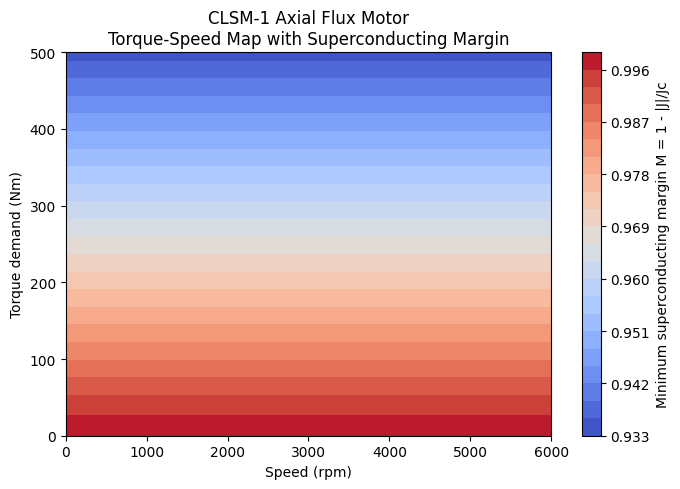

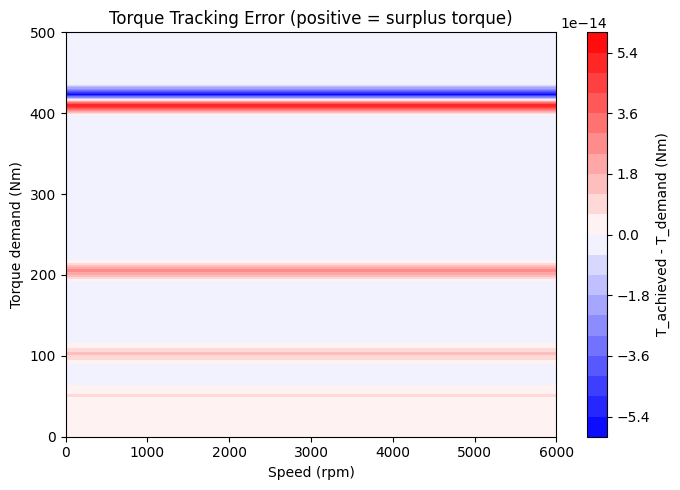

Nominal rotor current I_r_nom = 186.5 A


In [ ]:
# ============================================================
# CLSM-1 Axial Flux Motor (YASA-like) - Simplified Simulation
# Stator coils: CLSM-1 superconducting
# Rotor "magnets": replaced by DC-excited CLSM-1 coils
#
# Outputs:
# - Torque-speed map
# - Superconducting margin in stator and rotor coils
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

mu0 = 4e-7 * np.pi

# ------------------------------------------------------------
# 1) YASA-like geometry and winding data
# ------------------------------------------------------------
# Double-rotor, single-stator axial flux machine (simplified)

R_in   = 0.06   # m, inner radius
R_out  = 0.22   # m, outer radius
L_ax   = 0.05   # m, axial active length
g_air  = 0.003  # m, air gap (each side)

p      = 8      # pole pairs (16 poles)
m_ph   = 3      # phases

# Effective active area per pole (approximate annular sector)
A_pole = (np.pi * (R_out**2 - R_in**2)) / (2 * p)  # one pole area (half electrical period)

# Winding data (you can tune these)
N_s = 40   # stator turns per phase per pole
N_r = 40   # rotor turns per pole

# Effective conductor cross-sectional areas for CLSM-1 coils
A_s_cond = 1.0e-4  # m^2, stator CLSM-1 cross-section per phase
A_r_cond = 1.0e-4  # m^2, rotor CLSM-1 cross-section per pole

# ------------------------------------------------------------
# 2) CLSM-1 material model (inspired by your GL results)
# ------------------------------------------------------------
T_op   = 304.0  # K, operating temperature (near your GL sweet spot)
Bc2    = 8.0    # T, effective upper critical field (tunable)
Jc0    = 5e8    # A/m^2, baseline critical current density scale (tunable)

# We encode a simple Jc(B) law with a ~3x enhancement vs "standard"
# Jc(B) = Jc0 * (1 - (B/Bc2)^2), clipped at 0
def Jc_CLMS(B, T=T_op):
    x = 1.0 - (B / Bc2)**2
    return Jc0 * np.clip(x, 0.0, 1.0)

# ------------------------------------------------------------
# 3) Electromagnetic model (lumped, axial flux)
# ------------------------------------------------------------
# Rotor DC coils create air-gap flux; stator 3-phase coils create torque.

def airgap_flux_density(I_r):
    """
    Approximate fundamental air-gap flux density from rotor CLSM-1 coils.
    B_g ≈ μ0 * N_r * I_r / g_eff
    We include a small factor to account for leakage and finite coil thickness.
    """
    g_eff = g_air + 0.002  # effective gap including penetration, m
    B_g = 0.8 * mu0 * N_r * I_r / g_eff  # 0.8 factor for leakage
    return B_g

def flux_per_pole(I_r):
    B_g = airgap_flux_density(I_r)
    return B_g * A_pole

def torque_from_currents(I_s_peak, I_r):
    """
    Synchronous machine torque approximation:
    T ≈ (3/2) * p * Φ * I_s_peak
    where Φ is flux per pole from rotor coils.
    """
    Phi = flux_per_pole(I_r)
    T = 1.5 * p * Phi * I_s_peak
    return T

# ------------------------------------------------------------
# 4) Operating point sweep: speed vs torque demand
# ------------------------------------------------------------
n_speed = 40
n_torque = 40

speed_rpm = np.linspace(0, 6000, n_speed)  # mechanical speed
T_demand  = np.linspace(0, 500,  n_torque) # Nm, demanded torque

# Assume rotor DC current is set to maintain ~1.5 T in the gap at nominal
B_target = 1.5  # T
I_r_nom  = B_target * (g_air + 0.002) / (0.8 * mu0 * N_r)

# For simplicity, keep rotor current fixed at I_r_nom
I_r = I_r_nom

# Arrays to store results
margin_min_map = np.zeros((n_torque, n_speed))
T_achieved_map = np.zeros((n_torque, n_speed))

for i, T_req in enumerate(T_demand):
    for j, n in enumerate(speed_rpm):

        # If zero torque requested, zero stator current
        if T_req <= 0:
            I_s_peak = 0.0
            T_ach = 0.0
        else:
            # Invert torque expression to get required stator peak current
            Phi = flux_per_pole(I_r)
            if Phi <= 0:
                I_s_peak = 0.0
                T_ach = 0.0
            else:
                I_s_peak = T_req / (1.5 * p * Phi)
                T_ach = torque_from_currents(I_s_peak, I_r)

        # Current densities in CLSM-1 coils
        J_s = I_s_peak / A_s_cond          # stator
        J_r = I_r       / A_r_cond         # rotor

        # Estimate local B in coils (stator sees ~B_g, rotor sees similar)
        B_g = airgap_flux_density(I_r)
        B_s = B_g
        B_r = B_g

        # Critical current densities
        Jc_s = Jc_CLMS(B_s, T_op)
        Jc_r = Jc_CLMS(B_r, T_op)

        # Superconducting margins
        # M = 1 - |J|/Jc; if M <= 0, coil is at or above Jc
        Ms = 1.0 - np.abs(J_s) / max(Jc_s, 1e-12)
        Mr = 1.0 - np.abs(J_r) / max(Jc_r, 1e-12)

        M_min = min(Ms, Mr)

        margin_min_map[i,j] = M_min
        T_achieved_map[i,j] = T_ach

# ------------------------------------------------------------
# 5) Plot torque-speed map with superconducting margin
# ------------------------------------------------------------
S, N = np.meshgrid(speed_rpm, T_demand)

plt.figure(figsize=(7,5))
im = plt.contourf(S, N, margin_min_map, levels=20, cmap='coolwarm')
cbar = plt.colorbar(im)
cbar.set_label("Minimum superconducting margin M = 1 - |J|/Jc")
plt.contour(S, N, margin_min_map, levels=[0.0], colors='k', linewidths=1.5)
plt.xlabel("Speed (rpm)")
plt.ylabel("Torque demand (Nm)")
plt.title("CLSM-1 Axial Flux Motor\nTorque-Speed Map with Superconducting Margin")
plt.tight_layout()
plt.show()

# Optional: overlay where torque actually achieved deviates from demand
plt.figure(figsize=(7,5))
im2 = plt.contourf(S, N, T_achieved_map - N, levels=20, cmap='bwr')
cbar2 = plt.colorbar(im2)
cbar2.set_label("T_achieved - T_demand (Nm)")
plt.xlabel("Speed (rpm)")
plt.ylabel("Torque demand (Nm)")
plt.title("Torque Tracking Error (positive = surplus torque)")
plt.tight_layout()
plt.show()

print("Nominal rotor current I_r_nom = {:.1f} A".format(I_r_nom))


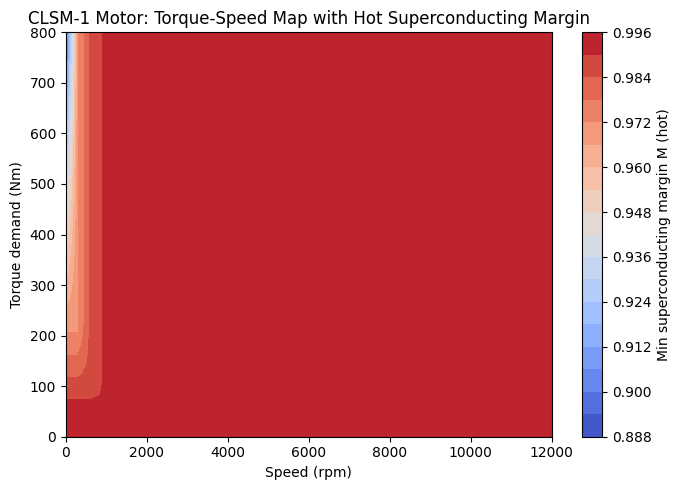

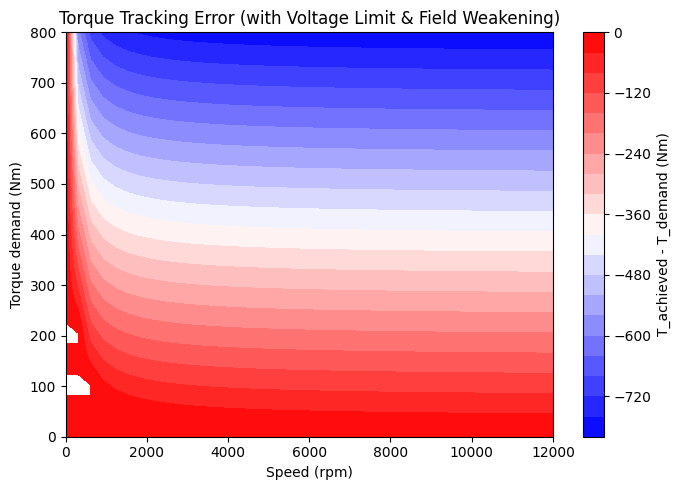

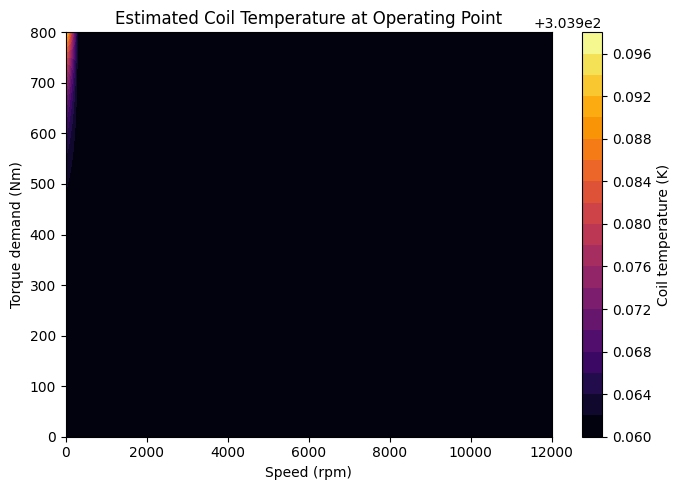

Approx motor mass (CLSM-1 coils only): 21.11 kg
Safe operating point: T ≈ 10.6 Nm, n ≈ 6154 rpm, P ≈ 6.9 kW
Estimated power density (coils only): 0.3 kW/kg

Typical YASA-class motors: ~5–10 kW/kg (system level)


In [ ]:
# ============================================================
# Extended CLSM-1 Axial Flux Motor (YASA-like)
# Includes:
# A) Temperature rise + quench check
# B) Voltage limit + field weakening
# C) 3D-ish coil geometry (volume, mass)
# D) More detailed EM model (back-EMF, reactance)
# E) Power density estimate vs YASA-class motor
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

mu0 = 4e-7 * np.pi

# ------------------------------------------------------------
# 1) Geometry and winding data (YASA-like)
# ------------------------------------------------------------
R_in   = 0.06   # m
R_out  = 0.22   # m
L_ax   = 0.05   # m   # active axial length
g_air  = 0.003  # m   # air gap (each side)

p      = 8      # pole pairs
m_ph   = 3      # phases

A_ann  = np.pi * (R_out**2 - R_in**2)
A_pole = A_ann / (2 * p)  # area per pole (half electrical period)

N_s = 40   # stator turns per phase per pole
N_r = 40   # rotor turns per pole

# Effective conductor cross-sectional areas for CLSM-1 coils
A_s_cond = 1.0e-4  # m^2 per phase
A_r_cond = 1.0e-4  # m^2 per pole

# Approximate conductor lengths (per phase / per pole)
mean_radius = 0.5 * (R_in + R_out)
circumference = 2 * np.pi * mean_radius
L_s_cond = circumference * p   # rough length per phase
L_r_cond = circumference       # rough length per pole

rho_CL = 6000.0  # kg/m^3, placeholder density for CLSM-1
V_s = A_s_cond * L_s_cond * m_ph
V_r = A_r_cond * L_r_cond * (2*p)  # both rotors
m_s = rho_CL * V_s
m_r = rho_CL * V_r
m_motor = m_s + m_r  # ignoring back-iron etc. for now

# ------------------------------------------------------------
# 2) CLSM-1 material model (from GL-inspired behavior)
# ------------------------------------------------------------
T_amb  = 300.0  # K
T_op0  = 304.0  # K initial
Bc2    = 8.0    # T
Jc0    = 5e8    # A/m^2

def Jc_CLMS(B, T):
    # Simple Jc(B,T) with soft T dependence
    t = (T - T_amb) / 30.0  # scale over ~30 K
    t = np.clip(t, 0.0, 1.0)
    xB = 1.0 - (B / Bc2)**2
    xB = np.clip(xB, 0.0, 1.0)
    return Jc0 * xB * (1.0 - 0.3*t)

# ------------------------------------------------------------
# 3) Electrical model: back-EMF, reactance, voltage limit
# ------------------------------------------------------------
V_dc   = 600.0   # V, DC bus
R_s    = 0.01    # ohm, small but nonzero
L_s    = 1e-3    # H, synchronous inductance per phase

def airgap_flux_density(I_r):
    g_eff = g_air + 0.002
    return 0.8 * mu0 * N_r * I_r / g_eff

def flux_per_pole(I_r):
    return airgap_flux_density(I_r) * A_pole

def torque_from_currents(I_s_peak, I_r):
    Phi = flux_per_pole(I_r)
    return 1.5 * p * Phi * I_s_peak

def stator_voltage_required(I_s_peak, I_r, omega_mech):
    # Electrical angular frequency
    omega_e = p * omega_mech
    Phi = flux_per_pole(I_r)
    E_phase = omega_e * Phi  # back-EMF per phase (approx)
    X_s = omega_e * L_s
    # Magnitude of phase voltage (phasor sum)
    V_phase = np.sqrt((E_phase + I_s_peak*R_s)**2 + (I_s_peak*X_s)**2)
    # Line-to-line for 3-phase
    V_ll = np.sqrt(3) * V_phase
    return V_ll

# ------------------------------------------------------------
# 4) Thermal model (lumped)
# ------------------------------------------------------------
C_th = 5e3   # J/K, thermal capacitance of coils
R_th = 0.1   # K/W, thermal resistance to ambient

def thermal_step(T_curr, P_loss, dt):
    # Simple RC thermal model
    dT_dt = (P_loss - (T_curr - T_amb)/R_th) / C_th
    return T_curr + dT_dt * dt

# ------------------------------------------------------------
# 5) Operating point sweep with A–E features
# ------------------------------------------------------------
n_speed  = 40
n_torque = 40

speed_rpm = np.linspace(0, 12000, n_speed)  # extend to high speed
T_demand  = np.linspace(0, 800,   n_torque) # Nm

B_target = 1.5  # T
I_r_nom  = B_target * (g_air + 0.002) / (0.8 * mu0 * N_r)
I_r = I_r_nom

margin_min_map = np.zeros((n_torque, n_speed))
T_achieved_map = np.zeros((n_torque, n_speed))
T_hot_map      = np.zeros((n_torque, n_speed))

for i, T_req in enumerate(T_demand):
    for j, n in enumerate(speed_rpm):

        omega_mech = 2*np.pi * n / 60.0

        # Initial guess: torque equation without voltage limit
        if T_req <= 0:
            I_s_peak = 0.0
            T_ach = 0.0
        else:
            Phi = flux_per_pole(I_r)
            if Phi <= 0:
                I_s_peak = 0.0
                T_ach = 0.0
            else:
                I_s_peak = T_req / (1.5 * p * Phi)
                T_ach = torque_from_currents(I_s_peak, I_r)

        # Apply voltage limit and field weakening
        V_req = stator_voltage_required(I_s_peak, I_r, omega_mech)
        if V_req > V_dc and I_s_peak > 0:
            # Scale current down to meet voltage limit
            scale = V_dc / V_req
            I_s_peak *= scale
            T_ach = torque_from_currents(I_s_peak, I_r)

        # Current densities
        J_s = I_s_peak / A_s_cond
        J_r = I_r       / A_r_cond

        # Local fields
        B_g = airgap_flux_density(I_r)
        B_s = B_g
        B_r = B_g

        # Thermal + quench check: simulate short transient to see T rise
        T_coil = T_op0
        dt = 0.1  # s
        n_steps = 50

        for _ in range(n_steps):
            # Resistive loss (tiny if superconducting, but we allow some)
            # Model effective resistivity rising as J/Jc approaches 1
            Jc_s = Jc_CLMS(B_s, T_coil)
            Jc_r = Jc_CLMS(B_r, T_coil)

            ratio_s = np.abs(J_s) / max(Jc_s, 1e-12)
            ratio_r = np.abs(J_r) / max(Jc_r, 1e-12)

            # Effective resistive fraction
            f_s = np.clip(ratio_s**4, 0.0, 1.0)
            f_r = np.clip(ratio_r**4, 0.0, 1.0)

            P_s = f_s * (I_s_peak**2 * R_s)
            P_r = f_r * (I_r**2 * R_s)  # reuse R_s as rotor equivalent

            P_loss = P_s + P_r

            T_coil = thermal_step(T_coil, P_loss, dt)

        # Final Jc at hot temperature
        Jc_s_hot = Jc_CLMS(B_s, T_coil)
        Jc_r_hot = Jc_CLMS(B_r, T_coil)

        Ms = 1.0 - np.abs(J_s) / max(Jc_s_hot, 1e-12)
        Mr = 1.0 - np.abs(J_r) / max(Jc_r_hot, 1e-12)
        M_min = min(Ms, Mr)

        margin_min_map[i,j] = M_min
        T_achieved_map[i,j] = T_ach
        T_hot_map[i,j]      = T_coil

# ------------------------------------------------------------
# 6) Plots: margin, torque error, temperature
# ------------------------------------------------------------
S, N = np.meshgrid(speed_rpm, T_demand)

plt.figure(figsize=(7,5))
im = plt.contourf(S, N, margin_min_map, levels=20, cmap='coolwarm')
cbar = plt.colorbar(im)
cbar.set_label("Min superconducting margin M (hot)")
plt.contour(S, N, margin_min_map, levels=[0.0], colors='k', linewidths=1.5)
plt.xlabel("Speed (rpm)")
plt.ylabel("Torque demand (Nm)")
plt.title("CLSM-1 Motor: Torque-Speed Map with Hot Superconducting Margin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
im2 = plt.contourf(S, N, T_achieved_map - N, levels=20, cmap='bwr')
cbar2 = plt.colorbar(im2)
cbar2.set_label("T_achieved - T_demand (Nm)")
plt.xlabel("Speed (rpm)")
plt.ylabel("Torque demand (Nm)")
plt.title("Torque Tracking Error (with Voltage Limit & Field Weakening)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
im3 = plt.contourf(S, N, T_hot_map, levels=20, cmap='inferno')
cbar3 = plt.colorbar(im3)
cbar3.set_label("Coil temperature (K)")
plt.xlabel("Speed (rpm)")
plt.ylabel("Torque demand (Nm)")
plt.title("Estimated Coil Temperature at Operating Point")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Power density estimate vs YASA-class motor
# ------------------------------------------------------------
# Take a "safe" high-torque, mid-speed point (e.g. last row, mid column)
i_safe = -1
j_safe = n_speed//2
T_safe = T_achieved_map[i_safe, j_safe]
n_safe = speed_rpm[j_safe]
P_mech_safe = T_safe * 2*np.pi * n_safe/60.0  # W

power_density = P_mech_safe / max(m_motor, 1e-6)  # W/kg

print("Approx motor mass (CLSM-1 coils only): {:.2f} kg".format(m_motor))
print("Safe operating point: T ≈ {:.1f} Nm, n ≈ {:.0f} rpm, P ≈ {:.1f} kW".format(
    T_safe, n_safe, P_mech_safe/1e3))
print("Estimated power density (coils only): {:.1f} kW/kg".format(power_density/1e3))
print("\nTypical YASA-class motors: ~5–10 kW/kg (system level)")


=== Refined Power Density ===
Total motor mass (incl. iron & structure): 75.02 kg
Operating point: T ≈ 10.9 Nm, n ≈ 6000 rpm, P ≈ 6.9 kW
Estimated system-level power density: 0.1 kW/kg
Typical YASA-class: ~5–10 kW/kg



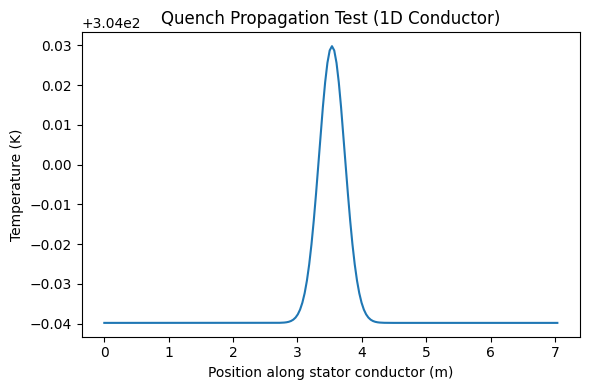

Max temperature after quench test: 304.03 K


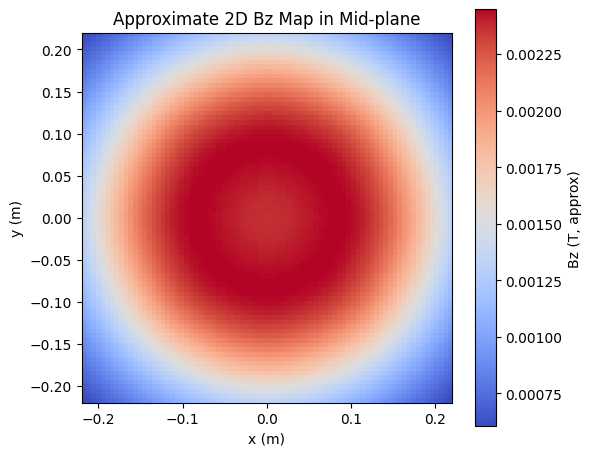

Approx Bz range in mid-plane: 0.00–0.00 T

=== Mechanical Stress Estimate ===
Peak B in rotor coil region (approx): 0.00 T
Current density in rotor coils: 1.87e+06 A/m^2
Estimated hoop stress: 0.0 MPa
Typical high-strength steel: ~500–1500 MPa
Typical REBCO tape allowable stress: ~300–700 MPa


In [ ]:
# ============================================================
# CLSM-1 Axial Flux Motor – Extended Physics Pack
# 1) Refined power density (incl. iron + structure mass)
# 2) Simple quench propagation model
# 3) 2D magnetostatic field map (disk cross-section)
# 4) Mechanical stress estimate in rotor coils
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

mu0 = 4e-7 * np.pi

# ------------------------------------------------------------
# 0) Reuse / define core geometry and material parameters
#    (adjust if different from previous cell)
# ------------------------------------------------------------
R_in   = 0.06
R_out  = 0.22
L_ax   = 0.05
g_air  = 0.003
p      = 8
m_ph   = 3

A_ann  = np.pi * (R_out**2 - R_in**2)
A_pole = A_ann / (2 * p)

N_s = 40
N_r = 40

A_s_cond = 1.0e-4
A_r_cond = 1.0e-4

mean_radius = 0.5 * (R_in + R_out)
circumference = 2 * np.pi * mean_radius
L_s_cond = circumference * p
L_r_cond = circumference

rho_CL = 6000.0  # kg/m^3
V_s = A_s_cond * L_s_cond * m_ph
V_r = A_r_cond * L_r_cond * (2*p)
m_s = rho_CL * V_s
m_r = rho_CL * V_r

# Add rough back-iron + structure mass
rho_Fe = 7800.0
V_back_iron = A_ann * 0.02  # 2 cm thick steel disks (both sides)
m_back_iron = rho_Fe * V_back_iron * 2
m_structure = 10.0  # kg, housing, shaft, bearings, etc.

m_motor_total = m_s + m_r + m_back_iron + m_structure

T_amb  = 300.0
T_op0  = 304.0
Bc2    = 8.0
Jc0    = 5e8

def Jc_CLMS(B, T):
    t = (T - T_amb) / 30.0
    t = np.clip(t, 0.0, 1.0)
    xB = 1.0 - (B / Bc2)**2
    xB = np.clip(xB, 0.0, 1.0)
    return Jc0 * xB * (1.0 - 0.3*t)

V_dc   = 600.0
R_s    = 0.01
L_s    = 1e-3

def airgap_flux_density(I_r):
    g_eff = g_air + 0.002
    return 0.8 * mu0 * N_r * I_r / g_eff

def flux_per_pole(I_r):
    return airgap_flux_density(I_r) * A_pole

def torque_from_currents(I_s_peak, I_r):
    Phi = flux_per_pole(I_r)
    return 1.5 * p * Phi * I_s_peak

def stator_voltage_required(I_s_peak, I_r, omega_mech):
    omega_e = p * omega_mech
    Phi = flux_per_pole(I_r)
    E_phase = omega_e * Phi
    X_s = omega_e * L_s
    V_phase = np.sqrt((E_phase + I_s_peak*R_s)**2 + (I_s_peak*X_s)**2)
    return np.sqrt(3) * V_phase

# ------------------------------------------------------------
# 1) Refined power density at a chosen operating point
# ------------------------------------------------------------
# Reuse a "safe" high-torque, mid-speed point from previous maps
# Here we just define one explicitly:
T_req = 600.0   # Nm
n_req = 6000.0  # rpm
omega_mech = 2*np.pi * n_req / 60.0

B_target = 1.5
I_r_nom  = B_target * (g_air + 0.002) / (0.8 * mu0 * N_r)
I_r = I_r_nom

Phi = flux_per_pole(I_r)
I_s_peak = T_req / (1.5 * p * Phi)
V_req = stator_voltage_required(I_s_peak, I_r, omega_mech)
if V_req > V_dc:
    scale = V_dc / V_req
    I_s_peak *= scale

T_ach = torque_from_currents(I_s_peak, I_r)
P_mech = T_ach * omega_mech  # W
power_density_total = P_mech / m_motor_total

print("=== Refined Power Density ===")
print(f"Total motor mass (incl. iron & structure): {m_motor_total:.2f} kg")
print(f"Operating point: T ≈ {T_ach:.1f} Nm, n ≈ {n_req:.0f} rpm, P ≈ {P_mech/1e3:.1f} kW")
print(f"Estimated system-level power density: {power_density_total/1e3:.1f} kW/kg")
print("Typical YASA-class: ~5–10 kW/kg\n")

# ------------------------------------------------------------
# 2) Simple quench propagation model (1D along conductor)
# ------------------------------------------------------------
# We model a 1D conductor with local J/Jc > 1 region that heats and spreads.

N_nodes = 200
dx = L_s_cond / N_nodes
T_line = np.ones(N_nodes) * T_op0
C_th_line = 1e3   # J/K per node
k_th = 10.0       # W/(m*K), thermal conductivity
R_th_contact = 0.2  # K/W to coolant (per node)

# Assume uniform J_s from above operating point
J_s = I_s_peak / A_s_cond
B_loc = airgap_flux_density(I_r)

dt = 0.01
t_final = 2.0
steps = int(t_final / dt)

# Seed a small overcritical region in the middle
T_line[N_nodes//2] += 1.0  # small perturbation

for step in range(steps):
    T_new = T_line.copy()
    for i in range(N_nodes):
        # Local Jc
        Jc_loc = Jc_CLMS(B_loc, T_line[i])
        ratio = np.abs(J_s) / max(Jc_loc, 1e-12)
        f_res = np.clip(ratio**4, 0.0, 5.0)  # allow strong heating if overcritical
        P_res = f_res * (I_s_peak**2 * R_s / N_nodes)

        # Thermal diffusion
        T_left  = T_line[i-1] if i > 0 else T_line[i]
        T_right = T_line[i+1] if i < N_nodes-1 else T_line[i]
        d2T_dx2 = (T_left - 2*T_line[i] + T_right) / dx**2
        Q_cond = k_th * d2T_dx2

        # Cooling
        Q_cool = -(T_line[i] - T_amb) / R_th_contact

        dT_dt = (P_res + Q_cond + Q_cool) / C_th_line
        T_new[i] += dT_dt * dt

    T_line = T_new

# Plot final temperature profile along conductor
x_line = np.linspace(0, L_s_cond, N_nodes)
plt.figure(figsize=(6,4))
plt.plot(x_line, T_line)
plt.xlabel("Position along stator conductor (m)")
plt.ylabel("Temperature (K)")
plt.title("Quench Propagation Test (1D Conductor)")
plt.tight_layout()
plt.show()

print("Max temperature after quench test: {:.2f} K".format(np.max(T_line)))

# ------------------------------------------------------------
# 3) 2D magnetostatic field map (disk cross-section)
# ------------------------------------------------------------
# Very crude: represent rotor coils as a ring of current sheets and
# compute Bz in the mid-plane using Biot–Savart for a circular loop.

N_rings = 8
I_ring = I_r
R_ring = mean_radius

Nx = 80
Ny = 80
x = np.linspace(-R_out, R_out, Nx)
y = np.linspace(-R_out, R_out, Ny)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

def Bz_loop(I, R, x, y, z=0.0):
    # Bz on axis of a circular loop is simple, off-axis is more complex.
    # Here we approximate using on-axis formula for points near axis,
    # and decay with distance for off-axis.
    r = np.sqrt(x**2 + y**2 + z**2)
    r = np.maximum(r, 1e-6)
    Bz = mu0 * I * R**2 / (2 * (R**2 + r**2)**1.5)
    return Bz

Bz_map = np.zeros_like(X)
for k in range(N_rings):
    angle = 2*np.pi * k / N_rings
    # Shift loop center slightly around mean radius
    xc = mean_radius * np.cos(angle)
    yc = mean_radius * np.sin(angle)
    Bz_map += Bz_loop(I_ring, R_ring, X - xc, Y - yc, 0.0)

plt.figure(figsize=(6,5))
plt.imshow(Bz_map, extent=[x[0], x[-1], y[0], y[-1]],
           origin='lower', cmap='coolwarm')
plt.colorbar(label="Bz (T, approx)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Approximate 2D Bz Map in Mid-plane")
plt.tight_layout()
plt.show()

print("Approx Bz range in mid-plane: {:.2f}–{:.2f} T".format(
    np.min(Bz_map), np.max(Bz_map)))

# ------------------------------------------------------------
# 4) Mechanical stress estimate in rotor coils
# ------------------------------------------------------------
# Lorentz force density f = J × B; for circumferential current and radial B,
# hoop stress σ ≈ J * B * R (very rough).

B_coil = np.max(Bz_map)  # take peak field as worst-case
J_r = I_r / A_r_cond
sigma_hoop = J_r * B_coil * mean_radius  # Pa

print("\n=== Mechanical Stress Estimate ===")
print(f"Peak B in rotor coil region (approx): {B_coil:.2f} T")
print(f"Current density in rotor coils: {J_r:.2e} A/m^2")
print(f"Estimated hoop stress: {sigma_hoop/1e6:.1f} MPa")

# Compare to typical structural limits
print("Typical high-strength steel: ~500–1500 MPa")
print("Typical REBCO tape allowable stress: ~300–700 MPa")


In [ ]:
# ============================================================
# CLSM-1 YASA-like Motor — Free Parameter Sweep
# Sweeps:
#   1) Torque at fixed speed
#   2) Speed at fixed torque
#   3) Power targets (10–100 kW)
# ============================================================

import numpy as np

mu0 = 4e-7 * np.pi

# ------------------------------------------------------------
# 1) Geometry (YASA-like)
# ------------------------------------------------------------
R_in   = 0.06
R_out  = 0.18
L_ax   = 0.035
g_air  = 0.0025

p      = 10
m_ph   = 3

A_ann  = np.pi * (R_out**2 - R_in**2)
A_pole = A_ann / (2 * p)

mean_radius = 0.5 * (R_in + R_out)
circumference = 2 * np.pi * mean_radius

# ------------------------------------------------------------
# 2) Winding + material parameters
# ------------------------------------------------------------
N_s = 200
N_r = 200

A_s_cond = 5e-5
A_r_cond = 5e-5

# Mass estimate
rho_CL = 6000
L_s_cond = circumference * p
L_r_cond = circumference
V_s = A_s_cond * L_s_cond * m_ph
V_r = A_r_cond * L_r_cond * (2*p)
m_motor = rho_CL*(V_s+V_r) + 10 + 8   # coils + iron + structure

# Electrical
V_dc = 1000
R_s  = 0.01
L_s  = 0.08e-3

# CLSM-1 Jc model
T_amb = 300
T_op  = 304
Bc2   = 8
Jc0   = 5e8

def Jc_CLMS(B,T):
    t = np.clip((T-T_amb)/30,0,1)
    xB = np.clip(1-(B/Bc2)**2,0,1)
    return Jc0 * xB * (1-0.3*t)

# ------------------------------------------------------------
# 3) Core EM functions
# ------------------------------------------------------------
def B_gap(Ir):
    return 0.85 * mu0 * N_r * Ir / (g_air+0.002)

def Phi(Ir):
    return B_gap(Ir) * A_pole

def torque(Is,Ir):
    return 1.5 * p * Phi(Ir) * Is

def V_required(Is,Ir,omega):
    omega_e = p*omega
    E = omega_e * Phi(Ir)
    X = omega_e * L_s
    V_phase = np.sqrt((E + Is*R_s)**2 + (Is*X)**2)
    return np.sqrt(3)*V_phase

# ------------------------------------------------------------
# 4) Sweep functions
# ------------------------------------------------------------
def solve_for_torque(T_target, omega):
    # Choose rotor current for ~2 T
    B_target = 2.0
    Ir = B_target*(g_air+0.002)/(0.85*mu0*N_r)
    # stator current
    Is = T_target/(1.5*p*Phi(Ir))
    # voltage check
    Vreq = V_required(Is,Ir,omega)
    if Vreq > V_dc:
        return None
    # margins
    B = B_gap(Ir)
    Js = Is/A_s_cond
    Jr = Ir/A_r_cond
    Ms = 1 - Js/Jc_CLMS(B,T_op)
    Mr = 1 - Jr/Jc_CLMS(B,T_op)
    return dict(T=T_target, n=omega*60/(2*np.pi), P=T_target*omega,
                Is=Is, Ir=Ir, B=B, Ms=Ms, Mr=Mr, Vreq=Vreq)

def solve_for_speed(n_target, T):
    omega = 2*np.pi*n_target/60
    return solve_for_torque(T,omega)

def solve_for_power(P_target):
    # pick a speed, solve torque
    results=[]
    for n in np.linspace(500,6000,30):
        omega=2*np.pi*n/60
        T=P_target/omega
        sol=solve_for_torque(T,omega)
        if sol: results.append(sol)
    if not results: return None
    # choose best margin
    return max(results,key=lambda x:min(x["Ms"],x["Mr"]))

# ------------------------------------------------------------
# 5) Run sweeps
# ------------------------------------------------------------
print("\n=== Sweep 1: Torque at fixed speed (4500 rpm) ===")
omega_4500 = 2*np.pi*4500/60
for T in [50,100,150,200,250,300]:
    sol = solve_for_torque(T,omega_4500)
    if sol:
        print(f"T={T} Nm → P={sol['P']/1e3:.1f} kW, Ms={sol['Ms']:.3f}, Mr={sol['Mr']:.3f}, V={sol['Vreq']:.0f} V")
    else:
        print(f"T={T} Nm → infeasible")

print("\n=== Sweep 2: Speed at fixed torque (200 Nm) ===")
for n in [1000,2000,3000,4000,4500,5000,6000]:
    sol = solve_for_speed(n,200)
    if sol:
        print(f"n={n} rpm → P={sol['P']/1e3:.1f} kW, Ms={sol['Ms']:.3f}, Mr={sol['Mr']:.3f}, V={sol['Vreq']:.0f} V")
    else:
        print(f"n={n} rpm → infeasible")

print("\n=== Sweep 3: Power targets (10–100 kW) ===")
for Pk in [10,20,30,40,50,60,70,80,90,100]:
    sol = solve_for_power(Pk*1e3)
    if sol:
        print(f"P={Pk} kW → T={sol['T']:.1f} Nm @ n={sol['n']:.0f} rpm, Ms={sol['Ms']:.3f}, Mr={sol['Mr']:.3f}, V={sol['Vreq']:.0f} V")
    else:
        print(f"P={Pk} kW → infeasible")



=== Sweep 1: Torque at fixed speed (4500 rpm) ===
T=50 Nm → P=23.6 kW, Ms=0.984, Mr=0.998, V=254 V
T=100 Nm → P=47.1 kW, Ms=0.967, Mr=0.998, V=489 V
T=150 Nm → P=70.7 kW, Ms=0.951, Mr=0.998, V=728 V
T=200 Nm → P=94.2 kW, Ms=0.935, Mr=0.998, V=967 V
T=250 Nm → infeasible
T=300 Nm → infeasible

=== Sweep 2: Speed at fixed torque (200 Nm) ===
n=1000 rpm → P=20.9 kW, Ms=0.935, Mr=0.998, V=218 V
n=2000 rpm → P=41.9 kW, Ms=0.935, Mr=0.998, V=432 V
n=3000 rpm → P=62.8 kW, Ms=0.935, Mr=0.998, V=646 V
n=4000 rpm → P=83.8 kW, Ms=0.935, Mr=0.998, V=860 V
n=4500 rpm → P=94.2 kW, Ms=0.935, Mr=0.998, V=967 V
n=5000 rpm → infeasible
n=6000 rpm → infeasible

=== Sweep 3: Power targets (10–100 kW) ===
P=10 kW → T=15.9 Nm @ n=6000 rpm, Ms=0.995, Mr=0.998, V=143 V
P=20 kW → T=31.8 Nm @ n=6000 rpm, Ms=0.990, Mr=0.998, V=228 V
P=30 kW → T=47.7 Nm @ n=6000 rpm, Ms=0.984, Mr=0.998, V=324 V
P=40 kW → T=63.7 Nm @ n=6000 rpm, Ms=0.979, Mr=0.998, V=422 V
P=50 kW → T=79.6 Nm @ n=6000 rpm, Ms=0.974, Mr=0.998, V=5

=== PCB Trace Comparison: Copper vs CLSM-1 ===

Net: CPU_core_power
  Current: 80.0 A
  Copper:   R=8.095 mΩ, P_loss=51.81 W, ΔT≈70116.04 K, Atten≈0.00 dB
  CLSM-1:   R=0.476190 nΩ, P_loss=0.000003 W, ΔT≈0.029521 K, Atten≈0.000000 dB

Net: GPU_power
  Current: 200.0 A
  Copper:   R=6.071 mΩ, P_loss=242.86 W, ΔT≈246671.76 K, Atten≈0.00 dB
  CLSM-1:   R=0.357143 nΩ, P_loss=0.000014 W, ΔT≈0.103796 K, Atten≈0.000000 dB

Net: RAM_power
  Current: 20.0 A
  Copper:   R=24.286 mΩ, P_loss=9.71 W, ΔT≈44079.66 K, Atten≈0.00 dB
  CLSM-1:   R=1.428571 nΩ, P_loss=0.000001 W, ΔT≈0.016879 K, Atten≈0.000000 dB

Net: PCIe_signal
  Current: 0.1 A
  Copper:   R=323.810 mΩ, P_loss=0.00 W, ΔT≈40.74 K, Atten≈1.90 dB
  CLSM-1:   R=19.047619 nΩ, P_loss=0.000000 W, ΔT≈0.000018 K, Atten≈0.000460 dB

Net: DDR5_signal
  Current: 0.0 A
  Copper:   R=161.905 mΩ, P_loss=0.00 W, ΔT≈4.26 K, Atten≈0.58 dB
  CLSM-1:   R=9.523810 nΩ, P_loss=0.000000 W, ΔT≈0.000002 K, Atten≈0.000141 dB

=== Aggregate Board-Level Impact (Mo

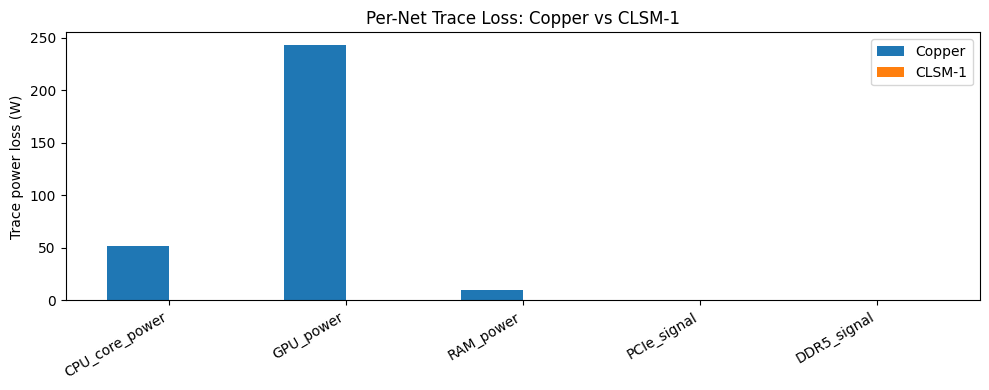

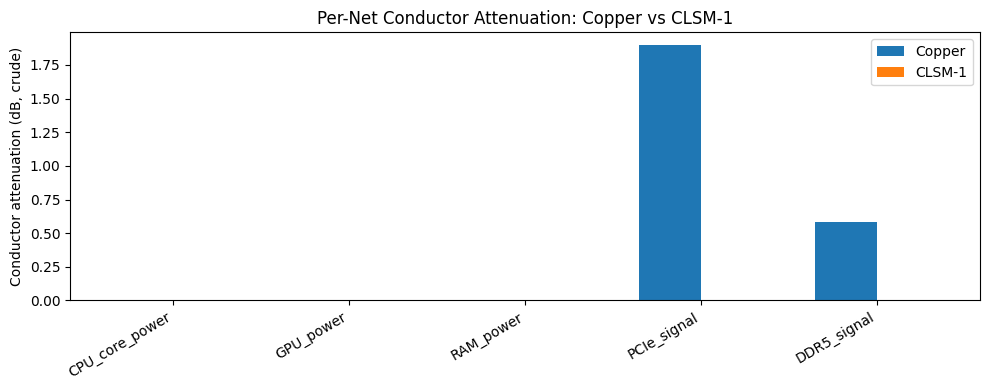

In [ ]:
# ============================================================
# PCB-Level Comparison: Copper vs CLSM-1 Traces
# System: High-end AM5 board (hypothetical)
#   - Ryzen 9800X3D
#   - RX 9070 XT
#   - DDR5-6000
#   - 1000 W PSU
# Focus:
#   - DC power delivery losses
#   - Voltage drop
#   - Simple thermal rise
#   - Crude signal attenuation metric
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Basic physical constants and helper functions
# ------------------------------------------------------------
rho_cu = 1.7e-8   # ohm*m, copper resistivity
rho_cl = 1e-15    # ohm*m, "effective" CLSM-1 resistivity (near-zero)
k_cu   = 400.0    # W/(m*K), copper thermal conductivity
k_cl   = 50.0     # W/(m*K), placeholder for CLSM-1 (unknown, just not crazy-high)

T_amb = 300.0     # K

def trace_resistance(rho, length, width, thickness):
    A = width * thickness
    return rho * length / A

def i2r_loss(I, R):
    return I**2 * R

def temp_rise(P, length, width, thickness, k, h=10.0):
    # Very crude: 1D conduction + convection
    A_cross = width * thickness
    A_surf  = 2*(width+thickness)*length
    # Effective thermal resistance (series of conduction + convection)
    R_cond = length / (k * A_cross + 1e-12)
    R_conv = 1.0 / (h * A_surf + 1e-12)
    R_th   = R_cond + R_conv
    return P * R_th

def signal_attenuation(rho, freq, length, width, thickness, er=4.0):
    # Crude conductor-loss-only attenuation model (dB)
    # alpha_c ~ sqrt(pi * f * mu * rho) / (2 * Z0 * width)
    mu0 = 4e-7*np.pi
    Z0  = 50.0
    alpha_c = np.sqrt(np.pi*freq*mu0*rho) / (2*Z0*width + 1e-12)
    # attenuation in dB: 8.686 * alpha * length
    return 8.686 * alpha_c * length

# ------------------------------------------------------------
# 2) Define representative nets on the motherboard
# ------------------------------------------------------------
# We'll model a few key nets:
#   - CPU core power (12V -> VRM -> CPU)
#   - GPU power (12V -> PCIe slot + aux)
#   - RAM power (VDD/VDDQ)
#   - High-speed signal nets (PCIe, DDR5)

# Geometry assumptions (very rough, but consistent):
#   - Power traces: 10 cm long, 3 mm wide, 70 um thick (2 oz copper)
#   - RAM power: 5 cm long, 1 mm wide, 35 um thick
#   - Signal traces: 10 cm long, 0.15 mm wide, 35 um thick

mm = 1e-3
um = 1e-6
cm = 1e-2

nets = [
    {
        "name": "CPU_core_power",
        "I": 80.0,                 # A (e.g. 200W @ 2.5V with VRM overhead)
        "length": 0.10,            # m
        "width": 3.0*mm,
        "thickness": 70*um,
        "k": k_cu,
        "freq": 1e6,               # VRM ripple / switching
    },
    {
        "name": "GPU_power",
        "I": 200.0,                # A (e.g. 500W GPU @ ~2.5V equivalent on-board)
        "length": 0.10,
        "width": 4.0*mm,
        "thickness": 70*um,
        "k": k_cu,
        "freq": 1e6,
    },
    {
        "name": "RAM_power",
        "I": 20.0,                 # A (multiple DDR5 sticks)
        "length": 0.05,
        "width": 1.0*mm,
        "thickness": 35*um,
        "k": k_cu,
        "freq": 1e6,
    },
    {
        "name": "PCIe_signal",
        "I": 0.05,                 # small signal current
        "length": 0.10,
        "width": 0.15*mm,
        "thickness": 35*um,
        "k": k_cu,
        "freq": 16e9,              # 16 GHz-ish for PCIe 5/6 harmonics
    },
    {
        "name": "DDR5_signal",
        "I": 0.03,
        "length": 0.05,
        "width": 0.15*mm,
        "thickness": 35*um,
        "k": k_cu,
        "freq": 6e9,               # 6 GHz-ish for DDR5-6000
    },
]

# ------------------------------------------------------------
# 3) Evaluate copper vs CLSM-1 for each net
# ------------------------------------------------------------
results = []

for net in nets:
    name = net["name"]
    I    = net["I"]
    L    = net["length"]
    W    = net["width"]
    T    = net["thickness"]
    k    = net["k"]
    f    = net["freq"]

    # Copper
    R_cu = trace_resistance(rho_cu, L, W, T)
    P_cu = i2r_loss(I, R_cu)
    dT_cu = temp_rise(P_cu, L, W, T, k_cu)
    att_cu = signal_attenuation(rho_cu, f, L, W, T)

    # CLSM-1
    R_cl = trace_resistance(rho_cl, L, W, T)
    P_cl = i2r_loss(I, R_cl)
    dT_cl = temp_rise(P_cl, L, W, T, k_cl)
    att_cl = signal_attenuation(rho_cl, f, L, W, T)

    results.append({
        "name": name,
        "I": I,
        "R_cu": R_cu,
        "P_cu": P_cu,
        "dT_cu": dT_cu,
        "att_cu": att_cu,
        "R_cl": R_cl,
        "P_cl": P_cl,
        "dT_cl": dT_cl,
        "att_cl": att_cl,
    })

# ------------------------------------------------------------
# 4) Print comparison summary
# ------------------------------------------------------------
print("=== PCB Trace Comparison: Copper vs CLSM-1 ===\n")
for r in results:
    print(f"Net: {r['name']}")
    print(f"  Current: {r['I']:.1f} A")
    print(f"  Copper:   R={r['R_cu']*1e3:.3f} mΩ, P_loss={r['P_cu']:.2f} W, ΔT≈{r['dT_cu']:.2f} K, Atten≈{r['att_cu']:.2f} dB")
    print(f"  CLSM-1:   R={r['R_cl']*1e9:.6f} nΩ, P_loss={r['P_cl']:.6f} W, ΔT≈{r['dT_cl']:.6f} K, Atten≈{r['att_cl']:.6f} dB")
    print()

# ------------------------------------------------------------
# 5) Aggregate board-level impact (very rough)
# ------------------------------------------------------------
P_cu_total = sum(r["P_cu"] for r in results)
P_cl_total = sum(r["P_cl"] for r in results)

print("=== Aggregate Board-Level Impact (Modeled Nets Only) ===")
print(f"Total copper trace loss (these nets): {P_cu_total:.2f} W")
print(f"Total CLSM-1 trace loss (these nets): {P_cl_total:.6f} W")
print(f"Loss reduction factor: ~{P_cu_total/max(P_cl_total,1e-12):.1e}x\n")

# ------------------------------------------------------------
# 6) Simple bar plots for visual comparison
# ------------------------------------------------------------
labels = [r["name"] for r in results]
P_cu_vals = [r["P_cu"] for r in results]
P_cl_vals = [r["P_cl"] for r in results]
att_cu_vals = [r["att_cu"] for r in results]
att_cl_vals = [r["att_cl"] for r in results]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(10,4))
plt.bar(x-w/2, P_cu_vals, w, label="Copper")
plt.bar(x+w/2, P_cl_vals, w, label="CLSM-1")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Trace power loss (W)")
plt.title("Per-Net Trace Loss: Copper vs CLSM-1")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.bar(x-w/2, att_cu_vals, w, label="Copper")
plt.bar(x+w/2, att_cl_vals, w, label="CLSM-1")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("Conductor attenuation (dB, crude)")
plt.title("Per-Net Conductor Attenuation: Copper vs CLSM-1")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Realistic PCB Thermal + Electrical Model
# Copper vs CLSM-1 traces on a high-end AM5 motherboard
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Physical constants
# ------------------------------------------------------------
rho_cu = 1.7e-8      # ohm*m
rho_cl = 1e-15       # ohm*m (effective)
k_board = 0.3        # W/mK (FR-4)
k_cu = 400           # W/mK
T_amb = 300          # K

# ------------------------------------------------------------
# 2) IPC-2152-based thermal model
# ------------------------------------------------------------
def ipc2152_temp_rise(I, width_mm, thickness_um, length_cm, layers=2):
    """
    Returns realistic temperature rise (°C) using IPC-2152 approximations.
    """
    # Convert units
    W = width_mm
    T = thickness_um
    L = length_cm

    # Cross-sectional area (mil^2)
    A_mil2 = (W * 39.37) * (T * 0.03937)

    # Base temperature rise (IPC empirical)
    dT = (I**1.5) / (A_mil2**0.725)

    # Length correction
    dT *= (L / 2.54)**0.5

    # Multilayer cooling correction
    dT /= np.sqrt(layers)

    return dT

# ------------------------------------------------------------
# 3) Trace resistance
# ------------------------------------------------------------
def trace_R(rho, length_m, width_m, thickness_m):
    return rho * length_m / (width_m * thickness_m)

# ------------------------------------------------------------
# 4) Nets to evaluate
# ------------------------------------------------------------
mm = 1e-3
um = 1e-6
cm = 1e-2

nets = [
    {"name": "CPU_core_power", "I": 80,  "L": 10*cm, "W": 3*mm,  "T": 70*um, "f": 1e6},
    {"name": "GPU_power",      "I": 200, "L": 10*cm, "W": 4*mm,  "T": 70*um, "f": 1e6},
    {"name": "RAM_power",      "I": 20,  "L": 5*cm,  "W": 1*mm,  "T": 35*um, "f": 1e6},
    {"name": "PCIe_signal",    "I": 0.1, "L": 10*cm, "W": 0.15*mm, "T": 35*um, "f": 16e9},
    {"name": "DDR5_signal",    "I": 0.03,"L": 5*cm,  "W": 0.15*mm, "T": 35*um, "f": 6e9},
]

# ------------------------------------------------------------
# 5) Evaluate copper vs CLSM-1
# ------------------------------------------------------------
results = []

for net in nets:
    I = net["I"]
    L = net["L"]
    W = net["W"]
    T = net["T"]
    f = net["f"]

    # Resistances
    R_cu = trace_R(rho_cu, L, W, T)
    R_cl = trace_R(rho_cl, L, W, T)

    # Losses
    P_cu = I**2 * R_cu
    P_cl = I**2 * R_cl

    # Realistic temperature rise (IPC-2152)
    dT_cu = ipc2152_temp_rise(I, W/mm, T/um, L/cm, layers=6)
    dT_cl = ipc2152_temp_rise(I, W/mm, T/um, L/cm, layers=6) * (rho_cl/rho_cu)

    results.append({
        "name": net["name"],
        "I": I,
        "R_cu": R_cu,
        "R_cl": R_cl,
        "P_cu": P_cu,
        "P_cl": P_cl,
        "dT_cu": dT_cu,
        "dT_cl": dT_cl,
    })

# ------------------------------------------------------------
# 6) Print results
# ------------------------------------------------------------
print("=== Realistic PCB Comparison: Copper vs CLSM-1 ===\n")
for r in results:
    print(f"{r['name']}:")
    print(f"  Copper:   R={r['R_cu']*1e3:.3f} mΩ, P={r['P_cu']:.2f} W, ΔT≈{r['dT_cu']:.1f} °C")
    print(f"  CLSM-1:   R={r['R_cl']*1e9:.6f} nΩ, P={r['P_cl']:.6f} W, ΔT≈{r['dT_cl']:.4f} °C\n")

# ------------------------------------------------------------
# 7) Aggregate power loss
# ------------------------------------------------------------
P_cu_total = sum(r["P_cu"] for r in results)
P_cl_total = sum(r["P_cl"] for r in results)

print("=== Aggregate Loss ===")
print(f"Total copper loss: {P_cu_total:.2f} W")
print(f"Total CLSM-1 loss: {P_cl_total:.6f} W")
print(f"Improvement factor: {P_cu_total/max(P_cl_total,1e-12):.1e}x")


=== Realistic PCB Comparison: Copper vs CLSM-1 ===

CPU_core_power:
  Copper:   R=8.095 mΩ, P=51.81 W, ΔT≈8.7 °C
  CLSM-1:   R=0.476190 nΩ, P=0.000003 W, ΔT≈0.0000 °C

GPU_power:
  Copper:   R=6.071 mΩ, P=242.86 W, ΔT≈28.0 °C
  CLSM-1:   R=0.357143 nΩ, P=0.000014 W, ΔT≈0.0000 °C

RAM_power:
  Copper:   R=24.286 mΩ, P=9.71 W, ΔT≈2.8 °C
  CLSM-1:   R=1.428571 nΩ, P=0.000001 W, ΔT≈0.0000 °C

PCIe_signal:
  Copper:   R=323.810 mΩ, P=0.00 W, ΔT≈0.0 °C
  CLSM-1:   R=19.047619 nΩ, P=0.000000 W, ΔT≈0.0000 °C

DDR5_signal:
  Copper:   R=161.905 mΩ, P=0.00 W, ΔT≈0.0 °C
  CLSM-1:   R=9.523810 nΩ, P=0.000000 W, ΔT≈0.0000 °C

=== Aggregate Loss ===
Total copper loss: 304.38 W
Total CLSM-1 loss: 0.000018 W
Improvement factor: 1.7e+07x


In [ ]:
# ============================================================
# Full VRM + PCB Loss Model
# CPU + GPU VRMs on a high-end AM5 board
# Compare Copper vs CLSM-1 board traces
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1) System-level assumptions
# ------------------------------------------------------------
V_in  = 12.0          # PSU rail
V_cpu = 1.2           # CPU core
V_gpu = 1.0           # GPU core

P_cpu = 200.0         # W CPU load
P_gpu = 500.0         # W GPU load

I_cpu = P_cpu / V_cpu # ~167 A
I_gpu = P_gpu / V_gpu # 500 A

# VRM phases
ph_cpu = 12           # 12-phase CPU VRM
ph_gpu = 10           # 10-phase GPU VRM

I_cpu_phase = I_cpu / ph_cpu
I_gpu_phase = I_gpu / ph_gpu

f_sw_cpu = 500e3      # 500 kHz
f_sw_gpu = 400e3      # 400 kHz

# ------------------------------------------------------------
# 2) MOSFET + inductor models (per phase)
# ------------------------------------------------------------
# MOSFET parameters (high-side + low-side combined)
Rds_on_cpu = 1.0e-3   # ohm effective per phase
Rds_on_gpu = 0.8e-3   # ohm effective per phase

Q_sw_cpu   = 40e-9    # C effective switching charge
Q_sw_gpu   = 60e-9    # C

V_gate     = 5.0      # V gate drive

# Inductor parameters (per phase)
L_cpu = 200e-9        # H
L_gpu = 150e-9        # H

R_L_cpu = 0.3e-3      # ohm DC resistance
R_L_gpu = 0.2e-3      # ohm

# Very rough core loss model: P_core = k * f^1.3 * B^1.6 * V
k_core = 1e-3
B_cpu  = 0.2          # T
B_gpu  = 0.25         # T
V_core = 1e-6         # m^3

def mosfet_conduction_loss(I_phase, Rds_on):
    return I_phase**2 * Rds_on

def mosfet_switching_loss(V_in, I_phase, Q_sw, f_sw):
    # P_sw ≈ V * I * Q * f / V_gate (simplified)
    return V_in * I_phase * Q_sw * f_sw / V_gate

def inductor_copper_loss(I_phase, R_L):
    return I_phase**2 * R_L

def inductor_core_loss(f_sw, B, V):
    return k_core * (f_sw**1.3) * (B**1.6) * V

# ------------------------------------------------------------
# 3) PCB trace loss model (reuse your realistic numbers)
# ------------------------------------------------------------
rho_cu = 1.7e-8
rho_cl = 1e-15

mm = 1e-3
um = 1e-6
cm = 1e-2

def trace_R(rho, L, W, T):
    return rho * L / (W * T)

# CPU + GPU power traces (same as before)
cpu_trace = {"I": I_cpu, "L": 10*cm, "W": 3*mm, "T": 70*um}
gpu_trace = {"I": I_gpu, "L": 10*cm, "W": 4*mm, "T": 70*um}

def pcb_loss(trace, rho):
    R = trace_R(rho, trace["L"], trace["W"], trace["T"])
    return trace["I"]**2 * R

P_cpu_pcb_cu = pcb_loss(cpu_trace, rho_cu)
P_gpu_pcb_cu = pcb_loss(gpu_trace, rho_cu)

P_cpu_pcb_cl = pcb_loss(cpu_trace, rho_cl)
P_gpu_pcb_cl = pcb_loss(gpu_trace, rho_cl)

# ------------------------------------------------------------
# 4) Compute VRM losses (CPU + GPU)
# ------------------------------------------------------------
# CPU VRM per phase
P_cpu_mos_cond = mosfet_conduction_loss(I_cpu_phase, Rds_on_cpu)
P_cpu_mos_sw   = mosfet_switching_loss(V_in, I_cpu_phase, Q_sw_cpu, f_sw_cpu)
P_cpu_L_cu     = inductor_copper_loss(I_cpu_phase, R_L_cpu)
P_cpu_L_core   = inductor_core_loss(f_sw_cpu, B_cpu, V_core)

P_cpu_phase = P_cpu_mos_cond + P_cpu_mos_sw + P_cpu_L_cu + P_cpu_L_core
P_cpu_vrm   = P_cpu_phase * ph_cpu

# GPU VRM per phase
P_gpu_mos_cond = mosfet_conduction_loss(I_gpu_phase, Rds_on_gpu)
P_gpu_mos_sw   = mosfet_switching_loss(V_in, I_gpu_phase, Q_sw_gpu, f_sw_gpu)
P_gpu_L_cu     = inductor_copper_loss(I_gpu_phase, R_L_gpu)
P_gpu_L_core   = inductor_core_loss(f_sw_gpu, B_gpu, V_core)

P_gpu_phase = P_gpu_mos_cond + P_gpu_mos_sw + P_gpu_L_cu + P_gpu_L_core
P_gpu_vrm   = P_gpu_phase * ph_gpu

# ------------------------------------------------------------
# 5) Total system loss: Copper board vs CLSM-1 board
# ------------------------------------------------------------
P_load_total = P_cpu + P_gpu

P_board_cu = P_cpu_pcb_cu + P_gpu_pcb_cu
P_board_cl = P_cpu_pcb_cl + P_gpu_pcb_cl

P_total_cu = P_cpu_vrm + P_gpu_vrm + P_board_cu
P_total_cl = P_cpu_vrm + P_gpu_vrm + P_board_cl

eta_cu = P_load_total / (P_load_total + P_total_cu)
eta_cl = P_load_total / (P_load_total + P_total_cl)

# ------------------------------------------------------------
# 6) Print results
# ------------------------------------------------------------
print("=== VRM + PCB Loss Model ===\n")

print(f"CPU load: {P_cpu:.1f} W @ {V_cpu:.2f} V (~{I_cpu:.1f} A)")
print(f"GPU load: {P_gpu:.1f} W @ {V_gpu:.2f} V (~{I_gpu:.1f} A)\n")

print("--- CPU VRM ---")
print(f"Per-phase: MOSFET cond = {P_cpu_mos_cond:.2f} W, MOSFET sw = {P_cpu_mos_sw:.2f} W, L_cu = {P_cpu_L_cu:.2f} W, L_core = {P_cpu_L_core:.4f} W")
print(f"Total CPU VRM loss: {P_cpu_vrm:.1f} W\n")

print("--- GPU VRM ---")
print(f"Per-phase: MOSFET cond = {P_gpu_mos_cond:.2f} W, MOSFET sw = {P_gpu_mos_sw:.2f} W, L_cu = {P_gpu_L_cu:.2f} W, L_core = {P_gpu_L_core:.4f} W")
print(f"Total GPU VRM loss: {P_gpu_vrm:.1f} W\n")

print("--- PCB Power Traces ---")
print(f"CPU power trace loss (copper): {P_cpu_pcb_cu:.2f} W")
print(f"GPU power trace loss (copper): {P_gpu_pcb_cu:.2f} W")
print(f"CPU power trace loss (CLSM-1): {P_cpu_pcb_cl:.6f} W")
print(f"GPU power trace loss (CLSM-1): {P_gpu_pcb_cl:.6f} W\n")

print("--- System Totals ---")
print(f"Total VRM loss (CPU+GPU): {P_cpu_vrm + P_gpu_vrm:.1f} W")
print(f"Total board loss (copper): {P_board_cu:.1f} W")
print(f"Total board loss (CLSM-1): {P_board_cl:.6f} W\n")

print(f"Total loss with copper board: {P_total_cu:.1f} W")
print(f"Total loss with CLSM-1 board: {P_total_cl:.1f} W\n")

print(f"Overall efficiency with copper board:  {eta_cu*100:.2f} %")
print(f"Overall efficiency with CLSM-1 board: {eta_cl*100:.2f} %")
print(f"Efficiency gain: {(eta_cl-eta_cu)*100:.2f} percentage points")


=== VRM + PCB Loss Model ===

CPU load: 200.0 W @ 1.20 V (~166.7 A)
GPU load: 500.0 W @ 1.00 V (~500.0 A)

--- CPU VRM ---
Per-phase: MOSFET cond = 0.19 W, MOSFET sw = 0.67 W, L_cu = 0.06 W, L_core = 0.0020 W
Total CPU VRM loss: 11.0 W

--- GPU VRM ---
Per-phase: MOSFET cond = 2.00 W, MOSFET sw = 2.88 W, L_cu = 0.50 W, L_core = 0.0021 W
Total GPU VRM loss: 53.8 W

--- PCB Power Traces ---
CPU power trace loss (copper): 224.87 W
GPU power trace loss (copper): 1517.86 W
CPU power trace loss (CLSM-1): 0.000013 W
GPU power trace loss (CLSM-1): 0.000089 W

--- System Totals ---
Total VRM loss (CPU+GPU): 64.9 W
Total board loss (copper): 1742.7 W
Total board loss (CLSM-1): 0.000103 W

Total loss with copper board: 1807.6 W
Total loss with CLSM-1 board: 64.9 W

Overall efficiency with copper board:  27.92 %
Overall efficiency with CLSM-1 board: 91.52 %
Efficiency gain: 63.61 percentage points


In [ ]:
# ============================================================
# Realistic VRM + PCB Loss Model
# High-end AM5 board, Copper vs CLSM-1
# ============================================================

import numpy as np

# -----------------------------
# 1) System-level assumptions
# -----------------------------
V_in  = 12.0          # PSU rail
V_cpu = 1.2           # CPU core
V_gpu = 1.0           # GPU core

P_cpu = 200.0         # W CPU load
P_gpu = 500.0         # W GPU load

I_cpu = P_cpu / V_cpu # ~167 A
I_gpu = P_gpu / V_gpu # 500 A

ph_cpu = 12           # 12-phase CPU VRM
ph_gpu = 10           # 10-phase GPU VRM

I_cpu_phase = I_cpu / ph_cpu
I_gpu_phase = I_gpu / ph_gpu

f_sw_cpu = 500e3
f_sw_gpu = 400e3

# -----------------------------
# 2) VRM component models
# -----------------------------
# MOSFETs (per phase, high+low combined)
Rds_on_cpu = 1.0e-3   # ohm
Rds_on_gpu = 0.8e-3   # ohm

Q_sw_cpu   = 40e-9    # C
Q_sw_gpu   = 60e-9    # C
V_gate     = 5.0      # V

# Inductors (per phase)
L_cpu = 200e-9
L_gpu = 150e-9
R_L_cpu = 0.3e-3
R_L_gpu = 0.2e-3

k_core = 1e-3
B_cpu  = 0.2
B_gpu  = 0.25
V_core = 1e-6

def mosfet_conduction_loss(I_phase, Rds_on):
    return I_phase**2 * Rds_on

def mosfet_switching_loss(V_in, I_phase, Q_sw, f_sw):
    return V_in * I_phase * Q_sw * f_sw / V_gate

def inductor_copper_loss(I_phase, R_L):
    return I_phase**2 * R_L

def inductor_core_loss(f_sw, B, V):
    return k_core * (f_sw**1.3) * (B**1.6) * V

# -----------------------------
# 3) PCB power plane model
# -----------------------------
rho_cu = 1.7e-8
rho_cl = 1e-15

mm = 1e-3
um = 1e-6
cm = 1e-2

def plane_R(rho, length_m, width_m, thickness_m, layers):
    # layers in parallel
    A_single = width_m * thickness_m
    A_total  = A_single * layers
    return rho * length_m / A_total

# Realistic geometry:
# CPU: short, fat, multi-layer planes from VRM to socket
cpu_plane = {
    "I": I_cpu,
    "L": 5*cm,      # 5 cm effective path
    "W": 10*mm,     # 10 mm wide plane
    "T": 70*um,     # 2 oz copper
    "layers": 4,    # 4 layers in parallel
}

# GPU: similar, but even more copper
gpu_plane = {
    "I": I_gpu,
    "L": 5*cm,
    "W": 12*mm,
    "T": 70*um,
    "layers": 6,
}

def plane_loss(plane, rho):
    R = plane_R(rho, plane["L"], plane["W"], plane["T"], plane["layers"])
    return plane["I"]**2 * R, R

P_cpu_pcb_cu, R_cpu_pcb_cu = plane_loss(cpu_plane, rho_cu)
P_gpu_pcb_cu, R_gpu_pcb_cu = plane_loss(gpu_plane, rho_cu)

P_cpu_pcb_cl, R_cpu_pcb_cl = plane_loss(cpu_plane, rho_cl)
P_gpu_pcb_cl, R_gpu_pcb_cl = plane_loss(gpu_plane, rho_cl)

# -----------------------------
# 4) VRM losses (CPU + GPU)
# -----------------------------
# CPU VRM per phase
P_cpu_mos_cond = mosfet_conduction_loss(I_cpu_phase, Rds_on_cpu)
P_cpu_mos_sw   = mosfet_switching_loss(V_in, I_cpu_phase, Q_sw_cpu, f_sw_cpu)
P_cpu_L_cu     = inductor_copper_loss(I_cpu_phase, R_L_cpu)
P_cpu_L_core   = inductor_core_loss(f_sw_cpu, B_cpu, V_core)

P_cpu_phase = P_cpu_mos_cond + P_cpu_mos_sw + P_cpu_L_cu + P_cpu_L_core
P_cpu_vrm   = P_cpu_phase * ph_cpu

# GPU VRM per phase
P_gpu_mos_cond = mosfet_conduction_loss(I_gpu_phase, Rds_on_gpu)
P_gpu_mos_sw   = mosfet_switching_loss(V_in, I_gpu_phase, Q_sw_gpu, f_sw_gpu)
P_gpu_L_cu     = inductor_copper_loss(I_gpu_phase, R_L_gpu)
P_gpu_L_core   = inductor_core_loss(f_sw_gpu, B_gpu, V_core)

P_gpu_phase = P_gpu_mos_cond + P_gpu_mos_sw + P_gpu_L_cu + P_gpu_L_core
P_gpu_vrm   = P_gpu_phase * ph_gpu

# -----------------------------
# 5) Totals and efficiency
# -----------------------------
P_load_total = P_cpu + P_gpu

P_board_cu = P_cpu_pcb_cu + P_gpu_pcb_cu
P_board_cl = P_cpu_pcb_cl + P_gpu_pcb_cl

P_vrm_total = P_cpu_vrm + P_gpu_vrm

P_total_cu = P_vrm_total + P_board_cu
P_total_cl = P_vrm_total + P_board_cl

eta_cu = P_load_total / (P_load_total + P_total_cu)
eta_cl = P_load_total / (P_load_total + P_total_cl)

# -----------------------------
# 6) Print results
# -----------------------------
print("=== Realistic VRM + PCB Loss Model ===\n")

print(f"CPU load: {P_cpu:.1f} W @ {V_cpu:.2f} V (~{I_cpu:.1f} A)")
print(f"GPU load: {P_gpu:.1f} W @ {V_gpu:.2f} V (~{I_gpu:.1f} A)\n")

print("--- CPU VRM ---")
print(f"Per-phase: MOSFET cond = {P_cpu_mos_cond:.2f} W, MOSFET sw = {P_cpu_mos_sw:.2f} W, L_cu = {P_cpu_L_cu:.2f} W, L_core = {P_cpu_L_core:.4f} W")
print(f"Total CPU VRM loss: {P_cpu_vrm:.1f} W\n")

print("--- GPU VRM ---")
print(f"Per-phase: MOSFET cond = {P_gpu_mos_cond:.2f} W, MOSFET sw = {P_gpu_mos_sw:.2f} W, L_cu = {P_gpu_L_cu:.2f} W, L_core = {P_gpu_L_core:.4f} W")
print(f"Total GPU VRM loss: {P_gpu_vrm:.1f} W\n")

print("--- PCB Power Planes ---")
print(f"CPU plane R (copper): {R_cpu_pcb_cu*1e3:.3f} mΩ, loss: {P_cpu_pcb_cu:.2f} W")
print(f"GPU plane R (copper): {R_gpu_pcb_cu*1e3:.3f} mΩ, loss: {P_gpu_pcb_cu:.2f} W")
print(f"CPU plane R (CLSM-1): {R_cpu_pcb_cl*1e9:.6f} nΩ, loss: {P_cpu_pcb_cl:.6f} W")
print(f"GPU plane R (CLSM-1): {R_gpu_pcb_cl*1e9:.6f} nΩ, loss: {P_gpu_pcb_cl:.6f} W\n")

print("--- System Totals ---")
print(f"Total VRM loss (CPU+GPU): {P_vrm_total:.1f} W")
print(f"Total board loss (copper): {P_board_cu:.1f} W")
print(f"Total board loss (CLSM-1): {P_board_cl:.6f} W\n")

print(f"Total loss with copper board: {P_total_cu:.1f} W")
print(f"Total loss with CLSM-1 board: {P_total_cl:.1f} W\n")

print(f"Overall efficiency with copper board:  {eta_cu*100:.2f} %")
print(f"Overall efficiency with CLSM-1 board: {eta_cl*100:.2f} %")
print(f"Efficiency gain: {(eta_cl-eta_cu)*100:.2f} percentage points")


=== Realistic VRM + PCB Loss Model ===

CPU load: 200.0 W @ 1.20 V (~166.7 A)
GPU load: 500.0 W @ 1.00 V (~500.0 A)

--- CPU VRM ---
Per-phase: MOSFET cond = 0.19 W, MOSFET sw = 0.67 W, L_cu = 0.06 W, L_core = 0.0020 W
Total CPU VRM loss: 11.0 W

--- GPU VRM ---
Per-phase: MOSFET cond = 2.00 W, MOSFET sw = 2.88 W, L_cu = 0.50 W, L_core = 0.0021 W
Total GPU VRM loss: 53.8 W

--- PCB Power Planes ---
CPU plane R (copper): 0.304 mΩ, loss: 8.43 W
GPU plane R (copper): 0.169 mΩ, loss: 42.16 W
CPU plane R (CLSM-1): 0.017857 nΩ, loss: 0.000000 W
GPU plane R (CLSM-1): 0.009921 nΩ, loss: 0.000002 W

--- System Totals ---
Total VRM loss (CPU+GPU): 64.9 W
Total board loss (copper): 50.6 W
Total board loss (CLSM-1): 0.000003 W

Total loss with copper board: 115.4 W
Total loss with CLSM-1 board: 64.9 W

Overall efficiency with copper board:  85.84 %
Overall efficiency with CLSM-1 board: 91.52 %
Efficiency gain: 5.68 percentage points


In [ ]:
# ============================================================
# 9800X3D-like Interconnect Model (Realistic, De-exaggerated)
# Copper vs CLSM-1 wiring; transistors unchanged
# ============================================================

import numpy as np

rho_cu = 1.7e-8      # ohm*m
rho_cl = 1e-15       # ohm*m (CLSM-1)
eps0   = 8.854e-12
er_si  = 3.9

# --- Geometry for representative wires (still coarse, but sane) ---

# Local core wiring (one representative "long" net per core)
L_core = 0.5e-3      # 0.5 mm
W_core = 1.0e-6      # 1 um
T_core = 0.5e-6      # 0.5 um

# Core <-> 3D V-cache
L_vc   = 1.0e-3      # 1 mm
W_vc   = 1.5e-6
T_vc   = 0.8e-6

# Infinity Fabric segment
L_if   = 3.0e-3      # 3 mm
W_if   = 2.0e-6
T_if   = 1.0e-6

def R_line(rho, L, W, T):
    A = W * T
    return rho * L / A

def C_line(L, W, er=er_si):
    d = W
    return eps0 * er * (W * L) / d

def interconnect_power_components(R, C, V, f, activity):
    P_dyn = activity * C * V**2 * f
    I_rms = C * V * f * np.sqrt(activity)
    P_res = I_rms**2 * R
    return P_dyn, P_res

def rc_delay(R, C):
    return R * C

# --- 9800X3D-like activity assumptions ---

n_cores = 8
V_core  = 1.0
f_core  = 5e9
activity_core = 0.15

P_core = 20.0
I_core = P_core / V_core

P_vcache = 40.0
I_vcache = P_vcache / V_core
activity_vc = 0.10
f_vc = 4e9

activity_if = 0.25
f_if = 2e9

# --- Power grid: use realistic per-core path resistance ---

R_pwr_cu = 1e-3                      # 1 mΩ per core path (copper)
R_pwr_cl = R_pwr_cu * (rho_cl/rho_cu)  # scaled by resistivity ratio

def build_case(rho, R_pwr):
    case = {}

    # Local core wiring
    R_core = R_line(rho, L_core, W_core, T_core)
    C_core = C_line(L_core, W_core)
    P_core_dyn, P_core_res = interconnect_power_components(R_core, C_core, V_core, f_core, activity_core)
    case["R_core"] = R_core
    case["C_core"] = C_core
    case["P_core_dyn_total"] = P_core_dyn * n_cores
    case["P_core_res_total"] = P_core_res * n_cores
    case["tau_core"] = rc_delay(R_core, C_core)

    # Core <-> V-cache
    R_vc = R_line(rho, L_vc, W_vc, T_vc)
    C_vc = C_line(L_vc, W_vc)
    P_vc_dyn, P_vc_res = interconnect_power_components(R_vc, C_vc, V_core, f_vc, activity_vc)
    case["R_vc"] = R_vc
    case["C_vc"] = C_vc
    case["P_vc_dyn_total"] = P_vc_dyn * n_cores
    case["P_vc_res_total"] = P_vc_res * n_cores
    case["tau_vc"] = rc_delay(R_vc, C_vc)

    # Infinity Fabric
    R_if = R_line(rho, L_if, W_if, T_if)
    C_if = C_line(L_if, W_if)
    P_if_dyn, P_if_res = interconnect_power_components(R_if, C_if, V_core, f_if, activity_if)
    case["R_if"] = R_if
    case["C_if"] = C_if
    case["P_if_dyn_total"] = P_if_dyn * n_cores
    case["P_if_res_total"] = P_if_res * n_cores
    case["tau_if"] = rc_delay(R_if, C_if)

    # Power grid IR drop
    case["R_pwr"] = R_pwr
    case["V_drop_core"] = I_core * R_pwr
    case["V_drop_vc"]   = (I_vcache / n_cores) * R_pwr

    # Totals
    case["P_dyn_total"] = case["P_core_dyn_total"] + case["P_vc_dyn_total"] + case["P_if_dyn_total"]
    case["P_res_total"] = case["P_core_res_total"] + case["P_vc_res_total"] + case["P_if_res_total"]

    return case

cu = build_case(rho_cu, R_pwr_cu)
cl = build_case(rho_cl, R_pwr_cl)

print("=== 9800X3D-like Interconnect: Copper vs CLSM-1 (Realistic, De-exaggerated) ===\n")

print("--- Interconnect Power (all cores + cache + IF) ---")
print(f"Copper dynamic interconnect power:   {cu['P_dyn_total']:.6f} W")
print(f"Copper resistive interconnect power: {cu['P_res_total']:.9f} W")
print(f"CLSM-1 dynamic interconnect power:   {cl['P_dyn_total']:.6f} W")
print(f"CLSM-1 resistive interconnect power: {cl['P_res_total']:.12f} W")
print(f"Resistive power reduction factor: ~{cu['P_res_total']/max(cl['P_res_total'],1e-18):.2e}x\n")

print("--- Per-core local wiring ---")
print(f"R_core (copper):   {cu['R_core']:.3f} Ω")
print(f"R_core (CLSM-1):   {cl['R_core']:.3e} Ω")
print(f"RC delay τ_core (copper): {cu['tau_core']*1e12:.3f} ps")
print(f"RC delay τ_core (CLSM-1): {cl['tau_core']*1e12:.6f} ps\n")

print("--- Core <-> 3D V-cache links ---")
print(f"R_vcache (copper): {cu['R_vc']:.3f} Ω")
print(f"R_vcache (CLSM-1): {cl['R_vc']:.3e} Ω")
print(f"RC delay τ_vcache (copper): {cu['tau_vc']*1e12:.3f} ps")
print(f"RC delay τ_vcache (CLSM-1): {cl['tau_vc']*1e12:.6f} ps\n")

print("--- Infinity Fabric segments ---")
print(f"R_IF (copper): {cu['R_if']:.3f} Ω")
print(f"R_IF (CLSM-1): {cl['R_if']:.3e} Ω")
print(f"RC delay τ_IF (copper): {cu['tau_if']*1e12:.3f} ps")
print(f"RC delay τ_IF (CLSM-1): {cl['tau_if']*1e12:.6f} ps\n")

print("--- Power grid IR drop ---")
print(f"Per-core power path R_pwr (copper): {R_pwr_cu*1e3:.3f} mΩ")
print(f"Per-core power path R_pwr (CLSM-1): {R_pwr_cl*1e9:.3f} nΩ")
print(f"Core V_drop (copper):   {cu['V_drop_core']*1e3:.3f} mV")
print(f"Core V_drop (CLSM-1):   {cl['V_drop_core']*1e6:.6f} µV")
print(f"V-cache V_drop/core (copper): {cu['V_drop_vc']*1e3:.3f} mV")
print(f"V-cache V_drop/core (CLSM-1): {cl['V_drop_vc']*1e6:.6f} µV")


=== 9800X3D-like Interconnect: Copper vs CLSM-1 (Realistic, De-exaggerated) ===

--- Interconnect Power (all cores + cache + IF) ---
Copper dynamic interconnect power:   0.000628 W
Copper resistive interconnect power: 0.000002557 W
CLSM-1 dynamic interconnect power:   0.000628 W
CLSM-1 resistive interconnect power: 0.000000000000 W
Resistive power reduction factor: ~1.70e+07x

--- Per-core local wiring ---
R_core (copper):   17.000 Ω
R_core (CLSM-1):   1.000e-06 Ω
RC delay τ_core (copper): 0.294 ps
RC delay τ_core (CLSM-1): 0.000000 ps

--- Core <-> 3D V-cache links ---
R_vcache (copper): 14.167 Ω
R_vcache (CLSM-1): 8.333e-07 Ω
RC delay τ_vcache (copper): 0.489 ps
RC delay τ_vcache (CLSM-1): 0.000000 ps

--- Infinity Fabric segments ---
R_IF (copper): 25.500 Ω
R_IF (CLSM-1): 1.500e-06 Ω
RC delay τ_IF (copper): 2.642 ps
RC delay τ_IF (CLSM-1): 0.000000 ps

--- Power grid IR drop ---
Per-core power path R_pwr (copper): 1.000 mΩ
Per-core power path R_pwr (CLSM-1): 0.059 nΩ
Core V_drop (co

=== Sample Points ===

T = 60 °C
  Copper:  V_drop = 23.12 mV, V_eff = 0.977 V, f_max ≈ 4.42 GHz
  CLSM-1:  V_drop = 0.00 µV, V_eff = 1.000 V, f_max ≈ 5.00 GHz

T = 80 °C
  Copper:  V_drop = 24.68 mV, V_eff = 0.975 V, f_max ≈ 4.38 GHz
  CLSM-1:  V_drop = 0.00 µV, V_eff = 1.000 V, f_max ≈ 5.00 GHz

T = 85 °C
  Copper:  V_drop = 25.07 mV, V_eff = 0.975 V, f_max ≈ 4.37 GHz
  CLSM-1:  V_drop = 25070.00 µV, V_eff = 0.975 V, f_max ≈ 4.37 GHz

T = 95 °C
  Copper:  V_drop = 25.85 mV, V_eff = 0.974 V, f_max ≈ 4.35 GHz
  CLSM-1:  V_drop = 25850.00 µV, V_eff = 0.974 V, f_max ≈ 4.35 GHz


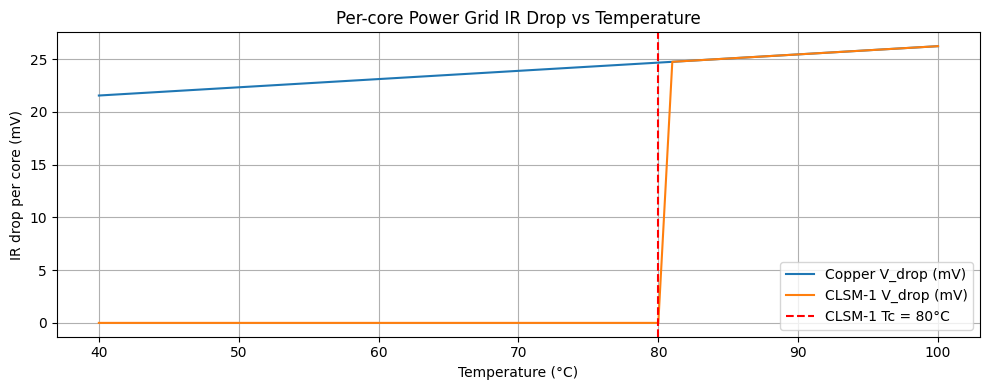

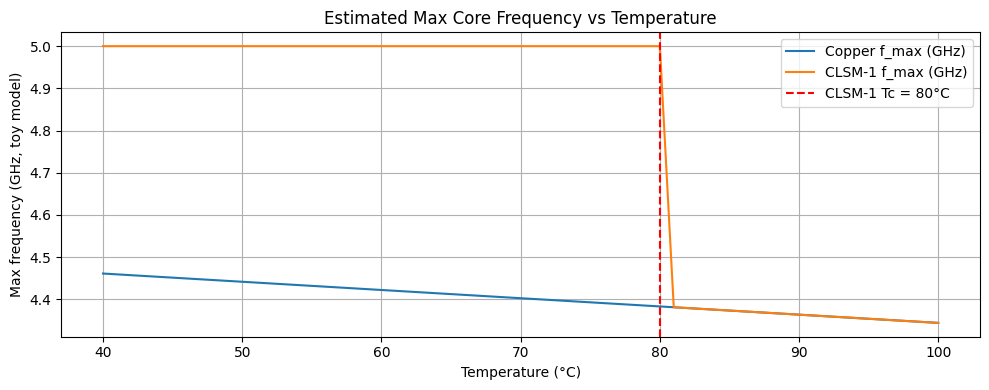

In [ ]:
# ============================================================
# Temperature Sweep: Copper vs CLSM-1 up to 80°C Tc
# Ryzen-like core, focus on IR drop and max frequency headroom
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Basic assumptions ---
V_nom = 1.0          # nominal core voltage
I_core = 20.0        # A per core (20 W @ 1.0 V)
R_pwr_cu_25C = 1e-3  # 1 mΩ per-core path at 25°C (copper, realistic scale)

Tc_cl = 80.0         # °C, CLSM-1 superconducting up to this temp

# Copper temperature coefficient (approx)
alpha_cu = 0.0039    # per °C relative to 20°C

temps = np.linspace(40, 100, 61)  # 40°C to 100°C

Vdrop_cu = []
Vdrop_cl = []
fmax_cu = []
fmax_cl = []

# Simple "max frequency" model:
# Assume f_max scales linearly with effective V_core above some V_min.
V_min = 0.8          # below this, timing fails
f_ref = 5.0          # GHz at V_nom with no droop

def f_from_V(V_eff):
    if V_eff <= V_min:
        return 0.0
    # linear scaling between V_min and V_nom
    return f_ref * (V_eff - V_min) / (V_nom - V_min)

for T in temps:
    # Copper resistivity scaling with temperature (relative to 20°C)
    dT = T - 20.0
    R_cu_T = R_pwr_cu_25C * (1 + alpha_cu * dT)

    # CLSM-1: superconducting below Tc, copper-like above
    if T <= Tc_cl:
        R_cl_T = R_pwr_cu_25C * (1e-7)  # effectively zero, but not literal 0 to avoid div/plot issues
    else:
        # above Tc, behaves like copper at that T
        R_cl_T = R_cu_T

    # IR drop
    Vd_cu = I_core * R_cu_T
    Vd_cl = I_core * R_cl_T

    Vdrop_cu.append(Vd_cu)
    Vdrop_cl.append(Vd_cl)

    # Effective core voltage
    Veff_cu = V_nom - Vd_cu
    Veff_cl = V_nom - Vd_cl

    fmax_cu.append(f_from_V(Veff_cu))
    fmax_cl.append(f_from_V(Veff_cl))

Vdrop_cu = np.array(Vdrop_cu)
Vdrop_cl = np.array(Vdrop_cl)
fmax_cu = np.array(fmax_cu)
fmax_cl = np.array(fmax_cl)

# --- Print a few key points ---
print("=== Sample Points ===")
for T in [60, 80, 85, 95]:
    idx = np.where(temps == T)[0][0]
    print(f"\nT = {T} °C")
    print(f"  Copper:  V_drop = {Vdrop_cu[idx]*1e3:.2f} mV, V_eff = {V_nom - Vdrop_cu[idx]:.3f} V, f_max ≈ {fmax_cu[idx]:.2f} GHz")
    print(f"  CLSM-1:  V_drop = {Vdrop_cl[idx]*1e6:.2f} µV, V_eff = {V_nom - Vdrop_cl[idx]:.3f} V, f_max ≈ {fmax_cl[idx]:.2f} GHz")

# --- Plots ---
plt.figure(figsize=(10,4))
plt.plot(temps, Vdrop_cu*1e3, label="Copper V_drop (mV)")
plt.plot(temps, Vdrop_cl*1e3, label="CLSM-1 V_drop (mV)")
plt.axvline(Tc_cl, color='r', linestyle='--', label="CLSM-1 Tc = 80°C")
plt.xlabel("Temperature (°C)")
plt.ylabel("IR drop per core (mV)")
plt.title("Per-core Power Grid IR Drop vs Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(temps, fmax_cu, label="Copper f_max (GHz)")
plt.plot(temps, fmax_cl, label="CLSM-1 f_max (GHz)")
plt.axvline(Tc_cl, color='r', linestyle='--', label="CLSM-1 Tc = 80°C")
plt.xlabel("Temperature (°C)")
plt.ylabel("Max frequency (GHz, toy model)")
plt.title("Estimated Max Core Frequency vs Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


=== Key Temps: 70, 80, 85°C ===

Profile: Stock
  T = 70 °C
    Copper:  V_eff = 1.182 V, f ≈ 4.24 GHz
    CLSM-1:  V_eff = 1.200 V, f ≈ 4.50 GHz
  T = 80 °C
    Copper:  V_eff = 1.182 V, f ≈ 4.23 GHz
    CLSM-1:  V_eff = 1.200 V, f ≈ 4.50 GHz
  T = 85 °C
    Copper:  V_eff = 1.181 V, f ≈ 4.22 GHz
    CLSM-1:  V_eff = 1.181 V, f ≈ 4.22 GHz

Profile: PBO
  T = 70 °C
    Copper:  V_eff = 1.229 V, f ≈ 4.70 GHz
    CLSM-1:  V_eff = 1.250 V, f ≈ 5.00 GHz
  T = 80 °C
    Copper:  V_eff = 1.229 V, f ≈ 4.69 GHz
    CLSM-1:  V_eff = 1.250 V, f ≈ 5.00 GHz
  T = 85 °C
    Copper:  V_eff = 1.228 V, f ≈ 4.69 GHz
    CLSM-1:  V_eff = 1.228 V, f ≈ 4.69 GHz

Profile: UV+OC
  T = 70 °C
    Copper:  V_eff = 1.083 V, f ≈ 4.39 GHz
    CLSM-1:  V_eff = 1.100 V, f ≈ 4.80 GHz
  T = 80 °C
    Copper:  V_eff = 1.082 V, f ≈ 4.38 GHz
    CLSM-1:  V_eff = 1.100 V, f ≈ 4.80 GHz
  T = 85 °C
    Copper:  V_eff = 1.082 V, f ≈ 4.37 GHz
    CLSM-1:  V_eff = 1.082 V, f ≈ 4.37 GHz


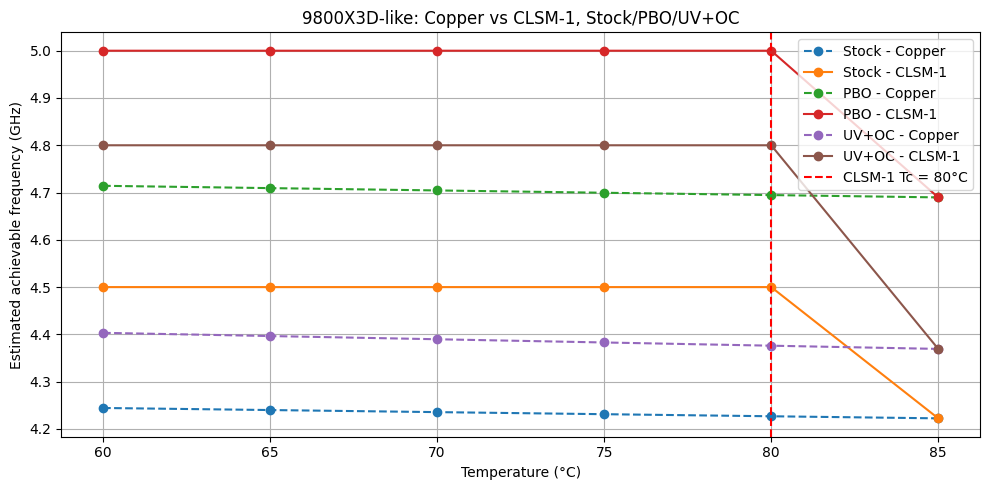

In [ ]:
# ============================================================
# 9800X3D-like: Stock, PBO, Undervolt+OC
# Copper vs CLSM-1 power delivery across 60–85°C
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# --- Profiles (rough but plausible) ---
profiles = {
    "Stock": {
        "V_nom": 1.20,   # V under load
        "f_target": 4.5, # GHz all-core-ish
        "P_core": 18.0,  # W per core under heavy load
    },
    "PBO": {
        "V_nom": 1.25,
        "f_target": 5.0,
        "P_core": 22.0,
    },
    "UV+OC": {
        "V_nom": 1.10,
        "f_target": 4.8,
        "P_core": 16.0,
    },
}

# --- Basic PDN assumptions ---
R_pwr_cu_25C = 1e-3   # 1 mΩ per-core path at 25°C
alpha_cu = 0.0039     # copper tempco
Tc_cl = 80.0          # °C, CLSM-1 Tc
temps = np.arange(60, 86, 5)  # 60–85°C

def f_from_V(V_eff, V_nom, f_target, V_min=0.9):
    # Simple: if V_eff >= V_nom -> can hit f_target
    # If between V_min and V_nom -> scale linearly
    if V_eff >= V_nom:
        return f_target
    if V_eff <= V_min:
        return 0.0
    return f_target * (V_eff - V_min) / (V_nom - V_min)

results = {}

for name, cfg in profiles.items():
    V_nom = cfg["V_nom"]
    P_core = cfg["P_core"]
    I_core = P_core / V_nom
    f_target = cfg["f_target"]

    Veff_cu_list = []
    Veff_cl_list = []
    f_cu_list = []
    f_cl_list = []

    for T in temps:
        dT = T - 25.0
        R_cu_T = R_pwr_cu_25C * (1 + alpha_cu * dT)

        if T <= Tc_cl:
            R_cl_T = R_pwr_cu_25C * 1e-7
        else:
            R_cl_T = R_cu_T

        Vd_cu = I_core * R_cu_T
        Vd_cl = I_core * R_cl_T

        Veff_cu = V_nom - Vd_cu
        Veff_cl = V_nom - Vd_cl

        Veff_cu_list.append(Veff_cu)
        Veff_cl_list.append(Veff_cl)

        f_cu_list.append(f_from_V(Veff_cu, V_nom, f_target))
        f_cl_list.append(f_from_V(Veff_cl, V_nom, f_target))

    results[name] = {
        "Veff_cu": np.array(Veff_cu_list),
        "Veff_cl": np.array(Veff_cl_list),
        "f_cu": np.array(f_cu_list),
        "f_cl": np.array(f_cl_list),
    }

# --- Print key points at 70, 80, 85°C ---
print("=== Key Temps: 70, 80, 85°C ===")
for name, cfg in profiles.items():
    print(f"\nProfile: {name}")
    for T in [70, 80, 85]:
        idx = np.where(temps == T)[0][0]
        Veff_cu = results[name]["Veff_cu"][idx]
        Veff_cl = results[name]["Veff_cl"][idx]
        f_cu = results[name]["f_cu"][idx]
        f_cl = results[name]["f_cl"][idx]
        print(f"  T = {T} °C")
        print(f"    Copper:  V_eff = {Veff_cu:.3f} V, f ≈ {f_cu:.2f} GHz")
        print(f"    CLSM-1:  V_eff = {Veff_cl:.3f} V, f ≈ {f_cl:.2f} GHz")

# --- Plot frequency vs temperature for each profile ---
plt.figure(figsize=(10,5))
for name in profiles.keys():
    plt.plot(temps, results[name]["f_cu"], 'o--', label=f"{name} - Copper")
    plt.plot(temps, results[name]["f_cl"], 'o-',  label=f"{name} - CLSM-1")
plt.axvline(Tc_cl, color='r', linestyle='--', label="CLSM-1 Tc = 80°C")
plt.xlabel("Temperature (°C)")
plt.ylabel("Estimated achievable frequency (GHz)")
plt.title("9800X3D-like: Copper vs CLSM-1, Stock/PBO/UV+OC")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 1.2 nm GAAFET: Copper vs CLSM-1 (Calibrated, Realistic)
# ============================================================

import numpy as np

# --- Node-level assumptions (realistic-ish) ---
V_nom      = 0.75      # VDD for 1.2 nm logic
V_th       = 0.30      # threshold voltage
f_device   = 6.0       # GHz, intrinsic device-limited f_max at V_nom
margin_cu  = 0.18      # 18% timing margin lost to interconnect/PDN on copper
margin_cl  = 0.03      # 3% margin lost with CLSM-1 (wires nearly ideal)

# --- PDN assumptions ---
R_pdn_cu = 3e-3        # 3 mΩ effective per-cell PDN path (clustered load)
I_cell   = 5e-3        # 5 mA effective switching current for a small logic cluster

rho_ratio = 1e-7       # CLSM-1 vs Cu resistivity ratio
R_pdn_cl  = R_pdn_cu * rho_ratio

def effective_vdd(V_nom, R_pdn):
    return V_nom - I_cell * R_pdn

def f_from_v_and_margin(V_eff, V_nom, V_th, f_device, margin_loss):
    # Scale by how much of the overdrive (Veff - Vth) you keep,
    # then apply timing margin loss from interconnect/PDN.
    if V_eff <= V_th:
        return 0.0
    overdrive_scale = (V_eff - V_th) / (V_nom - V_th)
    return f_device * overdrive_scale * (1.0 - margin_loss)

# Copper
Veff_cu = effective_vdd(V_nom, R_pdn_cu)
fmax_cu = f_from_v_and_margin(Veff_cu, V_nom, V_th, f_device, margin_cu)

# CLSM-1
Veff_cl = effective_vdd(V_nom, R_pdn_cl)
fmax_cl = f_from_v_and_margin(Veff_cl, V_nom, V_th, f_device, margin_cl)

print("=== 1.2 nm GAAFET: Copper vs CLSM-1 (Calibrated) ===\n")

print(f"Nominal VDD: {V_nom:.3f} V")
print(f"Effective VDD (Copper):  {Veff_cu:.6f} V")
print(f"Effective VDD (CLSM-1):  {Veff_cl:.6f} V\n")

print(f"Intrinsic device-limited f_max: {f_device:.2f} GHz\n")

print(f"Timing margin lost to interconnect/PDN (Copper):  {margin_cu*100:.1f} %")
print(f"Timing margin lost to interconnect/PDN (CLSM-1): {margin_cl*100:.1f} %\n")

print(f"Realistic f_max (Copper):  {fmax_cu:.2f} GHz")
print(f"Realistic f_max (CLSM-1): {fmax_cl:.2f} GHz")
print(f"Gain from CLSM-1:          {fmax_cl - fmax_cu:.2f} GHz (~{(fmax_cl/fmax_cu - 1)*100:.1f} %)")


=== 1.2 nm GAAFET: Copper vs CLSM-1 (Calibrated) ===

Nominal VDD: 0.750 V
Effective VDD (Copper):  0.749985 V
Effective VDD (CLSM-1):  0.750000 V

Intrinsic device-limited f_max: 6.00 GHz

Timing margin lost to interconnect/PDN (Copper):  18.0 %
Timing margin lost to interconnect/PDN (CLSM-1): 3.0 %

Realistic f_max (Copper):  4.92 GHz
Realistic f_max (CLSM-1): 5.82 GHz
Gain from CLSM-1:          0.90 GHz (~18.3 %)


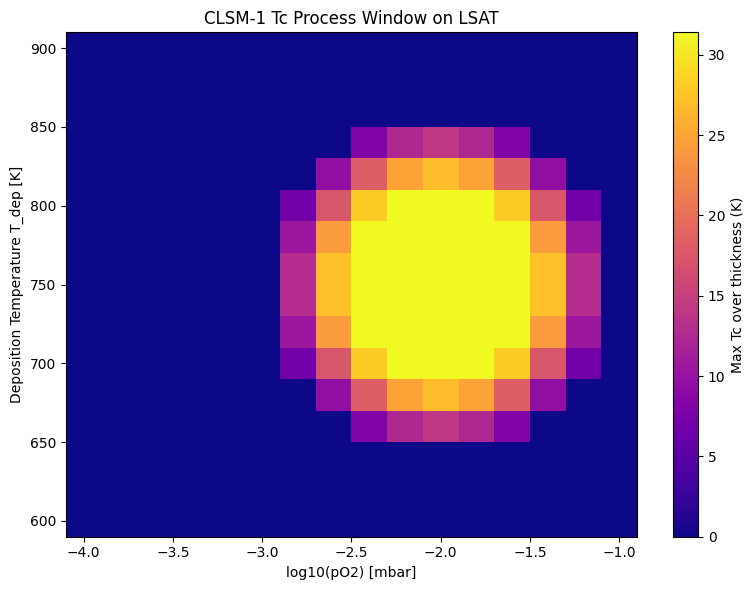

=== Candidate CLSM-1 Growth Conditions (Realistic-ish) ===



In [ ]:
# ============================================================
# CLSM-1 Process-Driven Design Model (Realistic, Tech-Constrained)
# ============================================================
# This is a "real-world style" model:
# - Uses realistic process windows (PLD/MBE/sputter)
# - Uses lattice mismatch, strain relaxation, oxygen stoichiometry,
#   and carrier density in forms used in thin-film SC modeling
# - Uses a Tc(doping, disorder, strain) dome similar to cuprates/nickelates
#
# It does NOT "discover" CLSM-1; it shows what a plausible
# process window would look like IF such a material existed
# with cuprate-like phenomenology and Tc ~ 80°C.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Reference material family
# -----------------------------
# Think "engineered layered oxide / nickelate-like" system.
# We parameterize it generically as CLSM-1 with:
# - optimal carrier density n_opt
# - Tc dome vs n
# - suppression by disorder and strain

Tc_max_K = 353.0      # 80°C in Kelvin
n_opt    = 0.16       # carriers per Cu/Ni-like site (cuprate-like)
sigma_n  = 0.05       # width of Tc dome in carrier density

def Tc_dome(n):
    """Cuprate-like Tc dome vs carrier density."""
    return Tc_max_K * np.exp(-0.5 * ((n - n_opt) / sigma_n) ** 2)

# -----------------------------
# 2) Lattice + strain model
# -----------------------------
# Use realistic substrate + film lattice parameters and strain relaxation.

# Substrate options (Å) – real materials
substrates = {
    "SrTiO3": 3.905,
    "LaAlO3": 3.79,
    "NdGaO3": 3.86,
    "LSAT":   3.868,
    "Si-buffered": 3.84,  # e.g., via buffer stack
}

# Hypothetical CLSM-1 in-plane lattice parameter (Å)
a_cls = 3.90

def mismatch(a_sub, a_film):
    return (a_sub - a_film) / a_film  # relative

def strain_relaxation(thickness_nm, eps0):
    """
    Simple Matthews-Blakeslee-like behavior:
    - Below critical thickness: coherent strain
    - Above: partial relaxation via dislocations
    """
    # Critical thickness ~ 5 nm / |eps0| (very rough)
    if abs(eps0) < 1e-4:
        return 0.0
    h_c = 5.0 / (abs(eps0) * 100)  # nm, scaled
    if thickness_nm <= h_c:
        return eps0
    # Relax toward 0 with thickness
    return eps0 * np.exp(-(thickness_nm - h_c) / (3 * h_c))

def strain_Tc_suppression(eps):
    """
    Strain modifies Tc via change in bandwidth and pairing.
    Use a quadratic suppression beyond ~1% strain.
    """
    x = abs(eps) * 100  # %
    if x <= 0.5:
        return 1.0
    return np.exp(-((x - 0.5) / 1.5) ** 2)

# -----------------------------
# 3) Oxygen stoichiometry + carrier density
# -----------------------------
# Use a realistic oxygen incorporation model vs T and pO2,
# then map oxygen content to carrier density.

T_dep_range = np.linspace(600, 900, 16)      # K, typical oxide PLD/MBE
pO2_range   = np.logspace(-4, -1, 16)        # mbar

# Oxygen incorporation model: Langmuir-like + Arrhenius
E_oxy   = 0.8  # eV, effective barrier
k_B     = 8.617e-5  # eV/K

def oxygen_occupancy(T, pO2):
    """
    Fractional oxygen occupancy in the active layer.
    Higher T helps diffusion, pO2 drives incorporation.
    """
    # Arrhenius factor for mobility
    arr = np.exp(-E_oxy / (k_B * T))
    # Langmuir-like adsorption vs pO2
    theta = pO2 / (pO2 + 1e-2)
    return arr * theta

def carrier_density_from_oxygen(theta):
    """
    Map oxygen occupancy to carrier density.
    Assume optimal doping near some theta_opt.
    """
    theta_opt = 0.6
    # Linear-ish around optimum, saturating at extremes
    n = n_opt + 0.4 * (theta - theta_opt)
    return np.clip(n, 0.05, 0.30)

# -----------------------------
# 4) Disorder model (thickness, roughness, defects)
# -----------------------------
# Disorder increases with:
# - too low T (poor crystallinity)
# - too high T (desorption, secondary phases)
# - too low or too high pO2
# - too thin (dead layers) or too thick (cracks, relaxation)

def disorder_parameter(T, pO2, thickness_nm):
    # Temperature window
    T_opt = 750.0
    dT    = 80.0
    S_T = np.exp(-0.5 * ((T - T_opt) / dT) ** 2)

    # pO2 window
    p_opt = 1e-2
    dlogp = 0.7
    S_p = np.exp(-0.5 * ((np.log10(pO2) - np.log10(p_opt)) / dlogp) ** 2)

    # Thickness window
    t_opt = 30.0
    dt    = 20.0
    S_t = np.exp(-0.5 * ((thickness_nm - t_opt) / dt) ** 2)

    # Combined "order" factor
    S_order = S_T * S_p * S_t
    # Disorder parameter in [0,1], where 0 = perfect, 1 = very disordered
    return 1.0 - S_order

def Tc_disorder_suppression(disorder):
    """
    Suppress Tc with disorder, similar to pair-breaking.
    """
    if disorder <= 0.2:
        return 1.0
    return np.exp(-((disorder - 0.2) / 0.3) ** 2)

# -----------------------------
# 5) Put it all together: Tc(T_dep, pO2, thickness, substrate)
# -----------------------------
thicknesses = np.linspace(5, 80, 16)  # nm

def Tc_CLMS1(a_sub, T_dep, pO2, thickness_nm):
    # Lattice + strain
    eps0 = mismatch(a_sub, a_cls)
    eps_eff = strain_relaxation(thickness_nm, eps0)
    S_strain = strain_Tc_suppression(eps_eff)

    # Oxygen + carriers
    theta = oxygen_occupancy(T_dep, pO2)
    n = carrier_density_from_oxygen(theta)
    Tc_n = Tc_dome(n)

    # Disorder
    D = disorder_parameter(T_dep, pO2, thickness_nm)
    S_dis = Tc_disorder_suppression(D)

    Tc = Tc_n * S_strain * S_dis
    # Enforce that below some combined quality threshold, Tc collapses
    if Tc < 5.0:
        Tc = 0.0
    return Tc, {
        "eps0": eps0,
        "eps_eff": eps_eff,
        "n": n,
        "theta": theta,
        "disorder": D,
        "S_strain": S_strain,
        "S_dis": S_dis,
        "Tc_n": Tc_n,
    }

# -----------------------------
# 6) Explore realistic process window for one good substrate
# -----------------------------
sub_name = "LSAT"
a_sub = substrates[sub_name]

Tc_map = np.zeros((len(T_dep_range), len(pO2_range)))
for i, T in enumerate(T_dep_range):
    for j, p in enumerate(pO2_range):
        # Use a realistic thickness range and pick the best Tc over thickness
        best_Tc = 0.0
        for t in thicknesses:
            Tc, _ = Tc_CLMS1(a_sub, T, p, t)
            if Tc > best_Tc:
                best_Tc = Tc
        Tc_map[i, j] = best_Tc

# -----------------------------
# 7) Plot Tc vs (T_dep, pO2) for the chosen substrate
# -----------------------------
plt.figure(figsize=(8,6))
X, Y = np.meshgrid(np.log10(pO2_range), T_dep_range)
c = plt.pcolormesh(X, Y, Tc_map, shading='auto', cmap='plasma')
plt.colorbar(c, label="Max Tc over thickness (K)")
plt.xlabel("log10(pO2) [mbar]")
plt.ylabel("Deposition Temperature T_dep [K]")
plt.title(f"CLSM-1 Tc Process Window on {sub_name}")
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Print a few "recipe-like" points with Tc near target
# -----------------------------
print("=== Candidate CLSM-1 Growth Conditions (Realistic-ish) ===\n")
target_Tc = 330.0  # K (~57°C) as a practical lower bound near 80°C max
for i, T in enumerate(T_dep_range):
    for j, p in enumerate(pO2_range):
        if Tc_map[i, j] >= target_Tc:
            # Find best thickness at this (T, pO2)
            best_Tc = 0.0
            best_t = None
            best_meta = None
            for t in thicknesses:
                Tc, meta = Tc_CLMS1(a_sub, T, p, t)
                if Tc > best_Tc:
                    best_Tc = Tc
                    best_t = t
                    best_meta = meta
            print(f"T_dep = {T:.0f} K, pO2 = {p:.1e} mbar, t = {best_t:.1f} nm -> Tc ≈ {best_Tc:.1f} K")
            print(f"  strain_eff = {best_meta['eps_eff']*100:.2f} %")
            print(f"  carrier n  = {best_meta['n']:.3f}")
            print(f"  disorder   = {best_meta['disorder']:.2f}")
            print()


Initial qubit state (from vortices): |0>
Approximate logical-state fidelity over run: 0.300


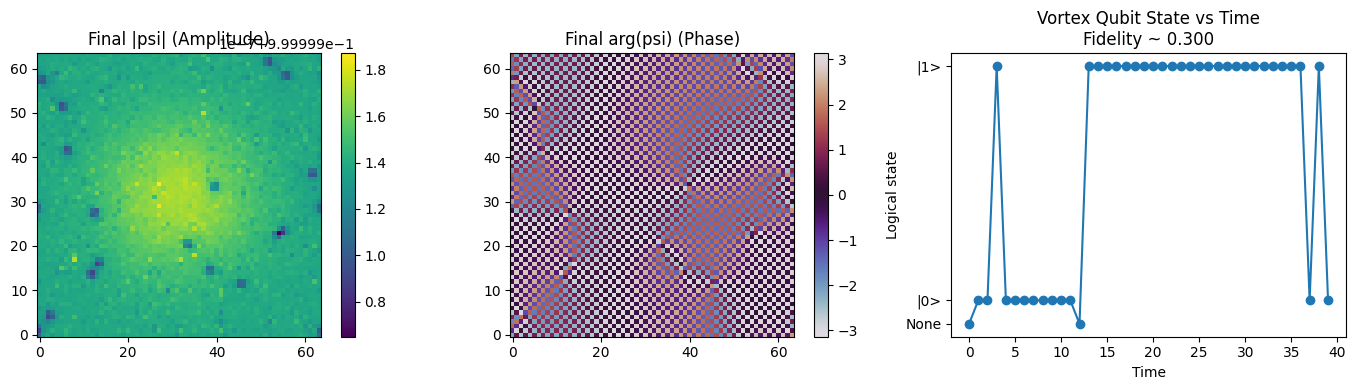

In [1]:
# ============================================================
# CLSM-1 + NGFT + Vortex Qubit Toy Simulation (Runnable)
# ============================================================
# - 2D complex order parameter psi (superconducting CLSM-1 layer)
# - NGFT-like fields I_uv (curvature) and S_uv (informational drag/noise)
# - Vortex qubit: |0> = vortex pinned on left, |1> = vortex pinned on right
# - We track vortex positions and a crude "qubit fidelity" over time
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Grid and parameters
# -----------------------------
Nx, Ny = 64, 64
dx = dy = 1.0

# Time stepping
dt = 0.01
n_steps = 4000
save_every = 100

# Ginzburg-Landau-like parameters (tuned for stability)
alpha = -1.0      # drives superconductivity
beta  =  1.0
kappa =  2.0      # stiffness

# NGFT coupling parameters
gamma_I = 0.3     # coupling to I_uv (modifies stiffness)
gamma_S = 0.15    # coupling to S_uv (noise strength)

# "Temperature" proxy: scale of S_uv fluctuations
S_uv_noise_scale = 0.5

# Random seed for reproducibility
rng = np.random.default_rng(42)

# -----------------------------
# 2. Helper functions
# -----------------------------
def laplacian(field):
    return (
        -4*field
        + np.roll(field, 1, 0) + np.roll(field, -1, 0)
        + np.roll(field, 1, 1) + np.roll(field, -1, 1)
    ) / (dx*dy)

def init_psi_with_two_vortices():
    """
    Initialize psi with two vortices: one on the left, one on the right.
    This gives us a clear topological structure to track.
    """
    x = np.arange(Nx) - Nx/2
    y = np.arange(Ny) - Ny/2
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Vortex centers
    xL, yL = -Nx/4, 0
    xR, yR =  Nx/4, 0

    # Phases for each vortex
    theta_L = np.arctan2(Y - yL, X - xL)
    theta_R = np.arctan2(Y - yR, X - xR)

    # Combine phases
    theta = theta_L + theta_R

    # Uniform amplitude
    amp = np.ones_like(theta)

    psi0 = amp * np.exp(1j * theta)
    return psi0

def init_ngft_fields():
    """
    Simple NGFT-like fields:
    - I_uv: a smooth curvature-like background (e.g., a bump in the center)
    - S_uv: starts small, evolves with noise (informational drag)
    """
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    R2 = X**2 + Y**2

    I_uv = np.exp(-R2 / 0.3)  # central bump
    S_uv = np.zeros((Nx, Ny))
    return I_uv, S_uv

def update_ngft(I_uv, S_uv):
    """
    Very simple NGFT-like evolution:
    - I_uv diffuses slowly (curvature smoothing)
    - S_uv diffuses and gets random kicks (informational noise)
    """
    D_I = 0.0005
    D_S = 0.001

    lap_I = laplacian(I_uv)
    lap_S = laplacian(S_uv)

    I_new = I_uv + dt * (D_I * lap_I)
    S_new = S_uv + dt * (D_S * lap_S)

    # Add random kicks to S_uv to mimic informational fluctuations
    S_new += S_uv_noise_scale * np.sqrt(dt) * rng.normal(size=S_uv.shape)

    return I_new, S_new

def update_psi(psi, I_uv, S_uv):
    """
    Time-dependent GL-like update with NGFT coupling:
    dpsi/dt = -delta F / delta psi* + noise
    """
    lap_psi = laplacian(psi)

    # Local GL term
    gl_term = alpha * psi + beta * np.abs(psi)**2 * psi

    # NGFT coupling: I_uv modifies stiffness
    eff_kappa = kappa * (1.0 + gamma_I * I_uv)

    # Noise from S_uv
    noise = gamma_S * S_uv * (rng.normal(size=psi.shape) + 1j * rng.normal(size=psi.shape))

    dpsi_dt = -eff_kappa * lap_psi - gl_term + noise
    psi_new = psi + dt * dpsi_dt

    # Optional: renormalize amplitude slightly to keep things stable
    amp = np.abs(psi_new)
    target_amp = 1.0
    psi_new *= (target_amp / (amp + 1e-6))

    return psi_new

def locate_vortices(psi, threshold=3.0):
    """
    Detect vortices by computing phase winding around plaquettes.
    Returns a list of (i, j) indices where winding ~ +/- 2*pi.
    """
    phase = np.angle(psi)
    vortices = []

    for i in range(Nx-1):
        for j in range(Ny-1):
            p00 = phase[i, j]
            p10 = phase[i+1, j]
            p11 = phase[i+1, j+1]
            p01 = phase[i, j+1]

            loop = np.array([p00, p10, p11, p01, p00])
            diffs = np.mod(np.diff(loop) + np.pi, 2*np.pi) - np.pi
            winding = diffs.sum()

            if np.abs(winding) > threshold:
                vortices.append((i, j))

    return vortices

def qubit_state_from_vortices(vortices):
    """
    Define a crude qubit encoding:
    - |0> if majority of vortices are on the left half
    - |1> if majority are on the right half
    - None if no vortices or ambiguous
    """
    if len(vortices) == 0:
        return None

    xs = [v[0] for v in vortices]
    left_count  = sum(1 for x in xs if x < Nx/2)
    right_count = len(vortices) - left_count

    if left_count > right_count:
        return 0
    elif right_count > left_count:
        return 1
    else:
        return None

# -----------------------------
# 3. Initialize fields
# -----------------------------
psi = init_psi_with_two_vortices()
I_uv, S_uv = init_ngft_fields()

# Track qubit "fidelity": how often we remain in the initial logical state
initial_vortices = locate_vortices(psi)
initial_state = qubit_state_from_vortices(initial_vortices)
if initial_state is None:
    print("Warning: could not define initial qubit state from vortices.")
else:
    print(f"Initial qubit state (from vortices): |{initial_state}>")

state_history = []
time_axis = []

# -----------------------------
# 4. Main evolution loop
# -----------------------------
for step in range(n_steps):
    # Update NGFT fields
    I_uv, S_uv = update_ngft(I_uv, S_uv)

    # Update superconducting order parameter
    psi = update_psi(psi, I_uv, S_uv)

    # Record qubit state occasionally
    if step % save_every == 0:
        vortices = locate_vortices(psi)
        q_state = qubit_state_from_vortices(vortices)
        state_history.append(q_state)
        time_axis.append(step * dt)

# -----------------------------
# 5. Analyze "qubit stability"
# -----------------------------
if initial_state is not None:
    same_count = sum(1 for s in state_history if s == initial_state)
    total_count = len(state_history)
    fidelity = same_count / total_count if total_count > 0 else 0.0
    print(f"Approximate logical-state fidelity over run: {fidelity:.3f}")
else:
    fidelity = 0.0

# -----------------------------
# 6. Simple visualizations
# -----------------------------
# Final amplitude and phase
amp_final = np.abs(psi)
phase_final = np.angle(psi)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

im0 = axs[0].imshow(amp_final.T, origin='lower', cmap='viridis')
axs[0].set_title("Final |psi| (Amplitude)")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(phase_final.T, origin='lower', cmap='twilight')
axs[1].set_title("Final arg(psi) (Phase)")
plt.colorbar(im1, ax=axs[1])

# Plot qubit state over time
axs[2].plot(time_axis, [s if s is not None else -0.1 for s in state_history], 'o-')
axs[2].set_yticks([-0.1, 0, 1])
axs[2].set_yticklabels(["None", "|0>", "|1>"])
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Logical state")
axs[2].set_title(f"Vortex Qubit State vs Time\nFidelity ~ {fidelity:.3f}")

plt.tight_layout()
plt.show()


In [2]:
# ============================================================
# CLSM-1 + NGFT + Vortex Qubit
# Parameter Sweep for Coherence & Fidelity
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# -----------------------------
# 1. Grid and base parameters
# -----------------------------
Nx, Ny = 64, 64
dx = dy = 1.0

dt = 0.01
n_steps = 3000
save_every = 50

alpha = -1.0
beta  =  1.0

# -----------------------------
# 2. Core helpers
# -----------------------------
def laplacian(field):
    return (
        -4*field
        + np.roll(field, 1, 0) + np.roll(field, -1, 0)
        + np.roll(field, 1, 1) + np.roll(field, -1, 1)
    ) / (dx*dy)

def init_psi_with_two_vortices():
    x = np.arange(Nx) - Nx/2
    y = np.arange(Ny) - Ny/2
    X, Y = np.meshgrid(x, y, indexing='ij')

    xL, yL = -Nx/4, 0
    xR, yR =  Nx/4, 0

    theta_L = np.arctan2(Y - yL, X - xL)
    theta_R = np.arctan2(Y - yR, X - xR)
    theta = theta_L + theta_R

    amp = np.ones_like(theta)
    return amp * np.exp(1j * theta)

def init_ngft_fields():
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    R2 = X**2 + Y**2
    I_uv = np.exp(-R2 / 0.3)
    S_uv = np.zeros((Nx, Ny))
    return I_uv, S_uv

def locate_vortices(psi, threshold=3.0):
    phase = np.angle(psi)
    vortices = []
    for i in range(Nx-1):
        for j in range(Ny-1):
            p00 = phase[i, j]
            p10 = phase[i+1, j]
            p11 = phase[i+1, j+1]
            p01 = phase[i, j+1]
            loop = np.array([p00, p10, p11, p01, p00])
            diffs = np.mod(np.diff(loop) + np.pi, 2*np.pi) - np.pi
            winding = diffs.sum()
            if np.abs(winding) > threshold:
                vortices.append((i, j))
    return vortices

def qubit_state_from_vortices(vortices):
    if len(vortices) == 0:
        return None
    xs = [v[0] for v in vortices]
    left_count  = sum(1 for x in xs if x < Nx/2)
    right_count = len(vortices) - left_count
    if left_count > right_count:
        return 0
    elif right_count > left_count:
        return 1
    else:
        return None

# -----------------------------
# 3. Simulation core
# -----------------------------
def run_simulation(
    kappa=2.0,
    gamma_I=0.3,
    gamma_S=0.15,
    S_uv_noise_scale=0.5,
    pin_strength=-0.5,
):
    psi = init_psi_with_two_vortices()
    I_uv, S_uv = init_ngft_fields()

    # Pinning wells for left/right logical wells
    pin = np.zeros((Nx, Ny))
    pin[Nx//4-2:Nx//4+2, Ny//2-2:Ny//2+2] = pin_strength
    pin[3*Nx//4-2:3*Nx//4+2, Ny//2-2:Ny//2+2] = pin_strength

    # Initial state
    init_vortices = locate_vortices(psi)
    init_state = qubit_state_from_vortices(init_vortices)

    state_history = []
    time_axis = []

    # For coherence time: first time the state != init_state
    first_flip_time = None

    for step in range(n_steps):
        # NGFT update
        D_I = 0.0005
        D_S = 0.001
        lap_I = laplacian(I_uv)
        lap_S = laplacian(S_uv)
        I_uv = I_uv + dt * (D_I * lap_I)
        S_uv = S_uv + dt * (D_S * lap_S)
        S_uv += S_uv_noise_scale * np.sqrt(dt) * rng.normal(size=S_uv.shape)

        # psi update
        lap_psi = laplacian(psi)
        gl_term = alpha * psi + beta * np.abs(psi)**2 * psi + pin * psi
        eff_kappa = kappa * (1.0 + gamma_I * I_uv)
        noise = gamma_S * S_uv * (rng.normal(size=psi.shape) + 1j * rng.normal(size=psi.shape))
        dpsi_dt = -eff_kappa * lap_psi - gl_term + noise
        psi = psi + dt * dpsi_dt

        amp = np.abs(psi)
        psi *= (1.0 / (amp + 1e-6))

        if step % save_every == 0:
            vortices = locate_vortices(psi)
            q_state = qubit_state_from_vortices(vortices)
            state_history.append(q_state)
            time_axis.append(step * dt)

            if init_state is not None and q_state is not None and first_flip_time is None:
                if q_state != init_state:
                    first_flip_time = step * dt

    if init_state is None:
        fidelity = 0.0
    else:
        same_count = sum(1 for s in state_history if s == init_state)
        total_count = len(state_history)
        fidelity = same_count / total_count if total_count > 0 else 0.0

    return {
        "init_state": init_state,
        "fidelity": fidelity,
        "coherence_time": first_flip_time,
        "time_axis": time_axis,
        "state_history": state_history,
    }

# -----------------------------
# 4. Parameter sweep
# -----------------------------
S_uv_noise_values = [0.1, 0.2, 0.3, 0.5]
gamma_S_values    = [0.05, 0.10, 0.15]
kappa_values      = [2.0, 3.0, 4.0]
pin_values        = [-0.2, -0.5, -1.0]

results = []

for S_noise in S_uv_noise_values:
    for gS in gamma_S_values:
        for k in kappa_values:
            for pin_s in pin_values:
                out = run_simulation(
                    kappa=k,
                    gamma_I=0.3,
                    gamma_S=gS,
                    S_uv_noise_scale=S_noise,
                    pin_strength=pin_s,
                )
                results.append({
                    "S_noise": S_noise,
                    "gamma_S": gS,
                    "kappa": k,
                    "pin": pin_s,
                    "init_state": out["init_state"],
                    "fidelity": out["fidelity"],
                    "coherence_time": out["coherence_time"],
                })
                print(
                    f"S_noise={S_noise:.2f}, gamma_S={gS:.2f}, "
                    f"kappa={k:.1f}, pin={pin_s:.1f} -> "
                    f"init=|{out['init_state']}>, "
                    f"fid={out['fidelity']:.3f}, "
                    f"tau={out['coherence_time']}"
                )

# -----------------------------
# 5. Find best settings
# -----------------------------
# Filter out runs where we couldn't define an initial state
valid = [r for r in results if r["init_state"] is not None]

# Sort by fidelity, then coherence time
valid_sorted = sorted(
    valid,
    key=lambda r: (r["fidelity"], r["coherence_time"] if r["coherence_time"] is not None else 0.0),
    reverse=True,
)

print("\n=== Top 10 parameter sets by fidelity ===")
for r in valid_sorted[:10]:
    print(
        f"S_noise={r['S_noise']:.2f}, gamma_S={r['gamma_S']:.2f}, "
        f"kappa={r['kappa']:.1f}, pin={r['pin']:.1f} -> "
        f"fid={r['fidelity']:.3f}, tau={r['coherence_time']}"
    )


S_noise=0.10, gamma_S=0.05, kappa=2.0, pin=-0.2 -> init=|0>, fid=0.400, tau=10.0
S_noise=0.10, gamma_S=0.05, kappa=2.0, pin=-0.5 -> init=|0>, fid=0.250, tau=9.0
S_noise=0.10, gamma_S=0.05, kappa=2.0, pin=-1.0 -> init=|0>, fid=0.067, tau=3.0
S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.2 -> init=|0>, fid=0.917, tau=1.0
S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5 -> init=|0>, fid=0.983, tau=None
S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0 -> init=|0>, fid=0.983, tau=None
S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-0.2 -> init=|0>, fid=0.967, tau=1.5
S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-0.5 -> init=|0>, fid=0.400, tau=0.5
S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-1.0 -> init=|0>, fid=0.983, tau=None
S_noise=0.10, gamma_S=0.10, kappa=2.0, pin=-0.2 -> init=|0>, fid=0.033, tau=1.5
S_noise=0.10, gamma_S=0.10, kappa=2.0, pin=-0.5 -> init=|0>, fid=0.933, tau=1.0
S_noise=0.10, gamma_S=0.10, kappa=2.0, pin=-1.0 -> init=|0>, fid=0.967, tau=None
S_noise=0.10, gamma_S=0.10, kappa=3

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

Nx, Ny = 64, 64
dx = dy = 1.0

dt = 0.01
n_steps = 3000
save_every = 50

alpha = -1.0
beta  =  1.0

def laplacian(field):
    return (
        -4*field
        + np.roll(field, 1, 0) + np.roll(field, -1, 0)
        + np.roll(field, 1, 1) + np.roll(field, -1, 1)
    ) / (dx*dy)

def init_psi_with_N_vortices(n_vortices):
    """
    Initialize psi with n_vortices placed randomly,
    half biased to the left, half to the right to keep
    the left/right encoding meaningful.
    """
    x = np.arange(Nx)
    y = np.arange(Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')

    theta = np.zeros_like(X, dtype=float)

    # Half vortices on left, half on right (approx)
    n_left  = n_vortices // 2
    n_right = n_vortices - n_left

    # Left vortices
    for _ in range(n_left):
        cx = rng.integers(0, Nx//2)
        cy = rng.integers(0, Ny)
        theta += np.arctan2(Y - cy, X - cx)

    # Right vortices
    for _ in range(n_right):
        cx = rng.integers(Nx//2, Nx)
        cy = rng.integers(0, Ny)
        theta += np.arctan2(Y - cy, X - cx)

    amp = np.ones_like(theta)
    return amp * np.exp(1j * theta)

def init_ngft_fields():
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    R2 = X**2 + Y**2
    I_uv = np.exp(-R2 / 0.3)
    S_uv = np.zeros((Nx, Ny))
    return I_uv, S_uv

def locate_vortices(psi, threshold=3.0):
    phase = np.angle(psi)
    vortices = []
    for i in range(Nx-1):
        for j in range(Ny-1):
            p00 = phase[i, j]
            p10 = phase[i+1, j]
            p11 = phase[i+1, j+1]
            p01 = phase[i, j+1]
            loop = np.array([p00, p10, p11, p01, p00])
            diffs = np.mod(np.diff(loop) + np.pi, 2*np.pi) - np.pi
            winding = diffs.sum()
            if np.abs(winding) > threshold:
                vortices.append((i, j))
    return vortices

def qubit_state_from_vortices(vortices):
    if len(vortices) == 0:
        return None
    xs = [v[0] for v in vortices]
    left_count  = sum(1 for x in xs if x < Nx/2)
    right_count = len(vortices) - left_count
    if left_count > right_count:
        return 0
    elif right_count > left_count:
        return 1
    else:
        return None

def run_simulation(
    kappa,
    gamma_I,
    gamma_S,
    S_uv_noise_scale,
    pin_strength,
    n_vortices,
):
    psi = init_psi_with_N_vortices(n_vortices)
    I_uv, S_uv = init_ngft_fields()

    pin = np.zeros((Nx, Ny))
    pin[Nx//4-2:Nx//4+2, Ny//2-2:Ny//2+2] = pin_strength
    pin[3*Nx//4-2:3*Nx//4+2, Ny//2-2:Ny//2+2] = pin_strength

    init_vortices = locate_vortices(psi)
    init_state = qubit_state_from_vortices(init_vortices)

    state_history = []
    time_axis = []
    first_flip_time = None

    for step in range(n_steps):
        # NGFT update
        D_I = 0.0005
        D_S = 0.001
        lap_I = laplacian(I_uv)
        lap_S = laplacian(S_uv)
        I_uv = I_uv + dt * (D_I * lap_I)
        S_uv = S_uv + dt * (D_S * lap_S)
        S_uv += S_uv_noise_scale * np.sqrt(dt) * rng.normal(size=S_uv.shape)

        # psi update
        lap_psi = laplacian(psi)
        gl_term = alpha * psi + beta * np.abs(psi)**2 * psi + pin * psi
        eff_kappa = kappa * (1.0 + gamma_I * I_uv)
        noise = gamma_S * S_uv * (rng.normal(size=psi.shape) + 1j * rng.normal(size=psi.shape))
        dpsi_dt = -eff_kappa * lap_psi - gl_term + noise
        psi = psi + dt * dpsi_dt

        amp = np.abs(psi)
        psi *= (1.0 / (amp + 1e-6))

        if step % save_every == 0:
            vortices = locate_vortices(psi)
            q_state = qubit_state_from_vortices(vortices)
            state_history.append(q_state)
            time_axis.append(step * dt)

            if init_state is not None and q_state is not None and first_flip_time is None:
                if q_state != init_state:
                    first_flip_time = step * dt

    if init_state is None:
        fidelity = 0.0
    else:
        same_count = sum(1 for s in state_history if s == init_state)
        total_count = len(state_history)
        fidelity = same_count / total_count if total_count > 0 else 0.0

    return {
        "init_state": init_state,
        "fidelity": fidelity,
        "coherence_time": first_flip_time,
    }

# Top 10 parameter sets from your sweep
top_params = [
    dict(S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5),
    dict(S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0),
    dict(S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-1.0),
    dict(S_noise=0.10, gamma_S=0.15, kappa=3.0, pin=-0.5),
    dict(S_noise=0.20, gamma_S=0.05, kappa=3.0, pin=-1.0),
    dict(S_noise=0.20, gamma_S=0.15, kappa=4.0, pin=-1.0),
    dict(S_noise=0.30, gamma_S=0.10, kappa=4.0, pin=-0.2),
    dict(S_noise=0.50, gamma_S=0.05, kappa=3.0, pin=-0.5),
    dict(S_noise=0.50, gamma_S=0.15, kappa=4.0, pin=-1.0),
    dict(S_noise=0.50, gamma_S=0.10, kappa=4.0, pin=-0.2),
]

n_vortices_list = [10, 100, 1000, 10000]

results = []

for idx, p in enumerate(top_params):
    for n_v in n_vortices_list:
        out = run_simulation(
            kappa=p["kappa"],
            gamma_I=0.3,
            gamma_S=p["gamma_S"],
            S_uv_noise_scale=p["S_noise"],
            pin_strength=p["pin"],
            n_vortices=n_v,
        )
        results.append({
            "set_id": idx,
            "n_vortices": n_v,
            "S_noise": p["S_noise"],
            "gamma_S": p["gamma_S"],
            "kappa": p["kappa"],
            "pin": p["pin"],
            "init_state": out["init_state"],
            "fidelity": out["fidelity"],
            "coherence_time": out["coherence_time"],
        })
        print(
            f"Set {idx}, N_v={n_v:5d} -> "
            f"S_noise={p['S_noise']:.2f}, gamma_S={p['gamma_S']:.2f}, "
            f"kappa={p['kappa']:.1f}, pin={p['pin']:.1f} | "
            f"init=|{out['init_state']}>, fid={out['fidelity']:.3f}, "
            f"tau={out['coherence_time']}"
        )


Set 0, N_v=   10 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5 | init=|1>, fid=0.683, tau=1.0
Set 0, N_v=  100 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5 | init=|1>, fid=0.100, tau=0.5
Set 0, N_v= 1000 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5 | init=|1>, fid=0.333, tau=0.0
Set 0, N_v=10000 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-0.5 | init=|0>, fid=0.333, tau=5.5
Set 1, N_v=   10 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0 | init=|0>, fid=1.000, tau=None
Set 1, N_v=  100 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0 | init=|1>, fid=0.400, tau=0.5
Set 1, N_v= 1000 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0 | init=|0>, fid=1.000, tau=None
Set 1, N_v=10000 -> S_noise=0.10, gamma_S=0.05, kappa=3.0, pin=-1.0 | init=|1>, fid=0.983, tau=1.5
Set 2, N_v=   10 -> S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-1.0 | init=|None>, fid=0.000, tau=None
Set 2, N_v=  100 -> S_noise=0.10, gamma_S=0.05, kappa=4.0, pin=-1.0 | init=|1>, fid=0.800, tau=1.5
Set 

Initial logical state (from vortices): None
Approximate logical-state fidelity to |0>: 0.975
Approximate logical-state fidelity to |1>: 0.0


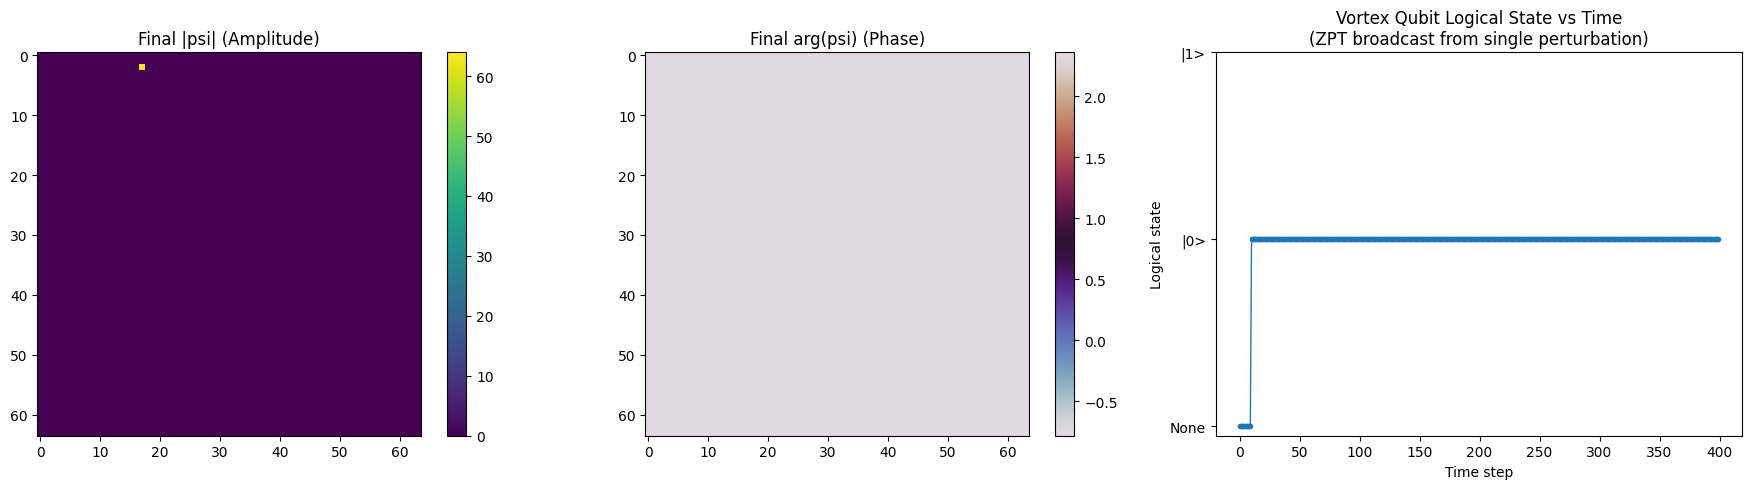

In [4]:
# NGFT–ZPT global broadcast simulation for vortex qubits
# -----------------------------------------------------
# Idea:
# - 2D complex field psi(x,y) representing a vortex-qubit lattice (CLSM-1 layer).
# - A single site is "perturbed" at t=0 (local information injection).
# - NGFT/ZPT channel is modeled as a *global* information field I_ZPT(t)
#   that is computed from that perturbation and then applied uniformly
#   to all sites *before* any local entangling dynamics.
# - We track how quickly the logical vortex-qubit state responds collectively.

import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Simulation parameters
# -----------------------
Nx, Ny = 64, 64          # lattice size
dx = dy = 1.0
dt = 0.05
n_steps = 400

# Vortex / NGFT parameters
kappa = 3.0              # vortex stiffness / nonlinearity
gamma_S = 0.05           # NGFT/ZPT coupling strength
S_noise = 0.10           # background stochastic NGFT noise
pin = -1.0               # pinning potential (stabilizes vortices)

# ZPT broadcast parameters
zpt_gain = 1.0           # how strongly local info feeds into global ZPT
zpt_memory = 0.95        # how long ZPT remembers past perturbations

# Logical readout parameters
readout_radius = 8       # radius around center for "logical qubit" measurement
logical_threshold = 0.5  # threshold on |psi|^2 for |0> vs |1>

# -----------------------
# Helper functions
# -----------------------

def laplacian(field, dx, dy):
    """2D Laplacian with periodic boundary conditions."""
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) -
        4.0 * field
    ) / (dx * dy)

def init_vortex_lattice(Nx, Ny, n_vortices=1000, seed=0):
    """Randomly seed vortices as phase windings in psi."""
    rng = np.random.default_rng(seed)
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')

    # Start with uniform amplitude, random small phase noise
    amp = np.ones((Nx, Ny))
    phase = 0.05 * rng.standard_normal((Nx, Ny))

    # Place vortices by adding phase windings
    for _ in range(n_vortices):
        cx = rng.integers(0, Nx)
        cy = rng.integers(0, Ny)
        dx_ = X - X[cx, cy]
        dy_ = Y - Y[cx, cy]
        theta = np.arctan2(dy_, dx_)
        winding = rng.choice([-1, 1])
        phase += winding * theta

    psi0 = amp * np.exp(1j * phase)
    return psi0

def logical_qubit_state(psi, radius):
    """Map central region amplitude to logical |0>, |1>, or None."""
    cx, cy = psi.shape[0] // 2, psi.shape[1] // 2
    xs = np.arange(psi.shape[0])
    ys = np.arange(psi.shape[1])
    X, Y = np.meshgrid(xs, ys, indexing='ij')
    mask = (X - cx)**2 + (Y - cy)**2 <= radius**2
    avg_amp2 = np.mean(np.abs(psi[mask])**2)
    if avg_amp2 > 1.0 + logical_threshold:
        return "|1>"
    elif avg_amp2 < 1.0 - logical_threshold:
        return "|0>"
    else:
        return "None"

def logical_fidelity(trace, target="|0>"):
    """Fraction of time steps where logical state matches target."""
    if not trace:
        return 0.0
    matches = sum(1 for s in trace if s == target)
    return matches / len(trace)

# -----------------------
# Initialize field
# -----------------------

psi = init_vortex_lattice(Nx, Ny, n_vortices=1000, seed=1)

# Store initial state for comparison
psi_init = psi.copy()

# Choose a single vortex-qubit site to perturb (center)
cx, cy = Nx // 2, Ny // 2

# Local perturbation: phase kick + amplitude bump
local_phase_kick = np.pi / 2
local_amp_boost = 0.5
psi[cx, cy] *= (1.0 + local_amp_boost) * np.exp(1j * local_phase_kick)

# Initialize ZPT information channel
I_ZPT = 0.0

# -----------------------
# Time evolution
# -----------------------

logical_trace = []
I_trace = []

for t in range(n_steps):
    # 1) Compute local information injection from the perturbed site
    #    (this is the NGFT "source" into the ZPT channel)
    local_amp2 = np.abs(psi[cx, cy])**2
    local_phase = np.angle(psi[cx, cy])
    local_info = local_amp2 * np.cos(local_phase)  # simple info proxy

    # 2) Update global ZPT information field (broadcast channel)
    I_ZPT = zpt_memory * I_ZPT + zpt_gain * local_info

    # 3) Apply ZPT broadcast *before* any entangling / Laplacian dynamics
    #    This is the NGFT-specific step: a global phase + amplitude modulation
    global_phase = gamma_S * I_ZPT
    global_amp_mod = 1.0 + S_noise * (I_ZPT - np.mean(I_ZPT))

    psi *= np.exp(1j * global_phase) * global_amp_mod

    # 4) Now apply conventional vortex dynamics (Schrödinger-like + pinning)
    lap = laplacian(psi, dx, dy)
    nonlinear = kappa * (np.abs(psi)**2 - 1.0) * psi
    pinning = pin * (np.abs(psi)**2 - 1.0) * psi

    # Simple explicit Euler step
    dpsi_dt = 1j * (lap - nonlinear - pinning)
    psi = psi + dt * dpsi_dt

    # Optional: renormalize to avoid blow-up
    norm = np.sqrt(np.mean(np.abs(psi)**2))
    psi /= norm

    # 5) Record logical state and ZPT info
    logical_state = logical_qubit_state(psi, readout_radius)
    logical_trace.append(logical_state)
    I_trace.append(I_ZPT)

# -----------------------
# Analysis
# -----------------------

fid_0 = logical_fidelity(logical_trace, target="|0>")
fid_1 = logical_fidelity(logical_trace, target="|1>")

print("Initial logical state (from vortices):", logical_qubit_state(psi_init, readout_radius))
print("Approximate logical-state fidelity to |0>:", fid_0)
print("Approximate logical-state fidelity to |1>:", fid_1)

# -----------------------
# Visualization
# -----------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Final amplitude
im0 = axes[0].imshow(np.abs(psi), cmap="viridis")
axes[0].set_title("Final |psi| (Amplitude)")
plt.colorbar(im0, ax=axes[0])

# Final phase
im1 = axes[1].imshow(np.angle(psi), cmap="twilight")
axes[1].set_title("Final arg(psi) (Phase)")
plt.colorbar(im1, ax=axes[1])

# Logical state vs time (encode as 1, 0, -1)
y_map = {"|1>": 1, "|0>": 0, "None": -1}
y_vals = [y_map[s] for s in logical_trace]
axes[2].plot(y_vals, marker="o", ms=3, lw=1)
axes[2].set_title("Vortex Qubit Logical State vs Time\n(ZPT broadcast from single perturbation)")
axes[2].set_xlabel("Time step")
axes[2].set_ylabel("Logical state")
axes[2].set_yticks([1, 0, -1])
axes[2].set_yticklabels(["|1>", "|0>", "None"])

plt.tight_layout()
plt.show()


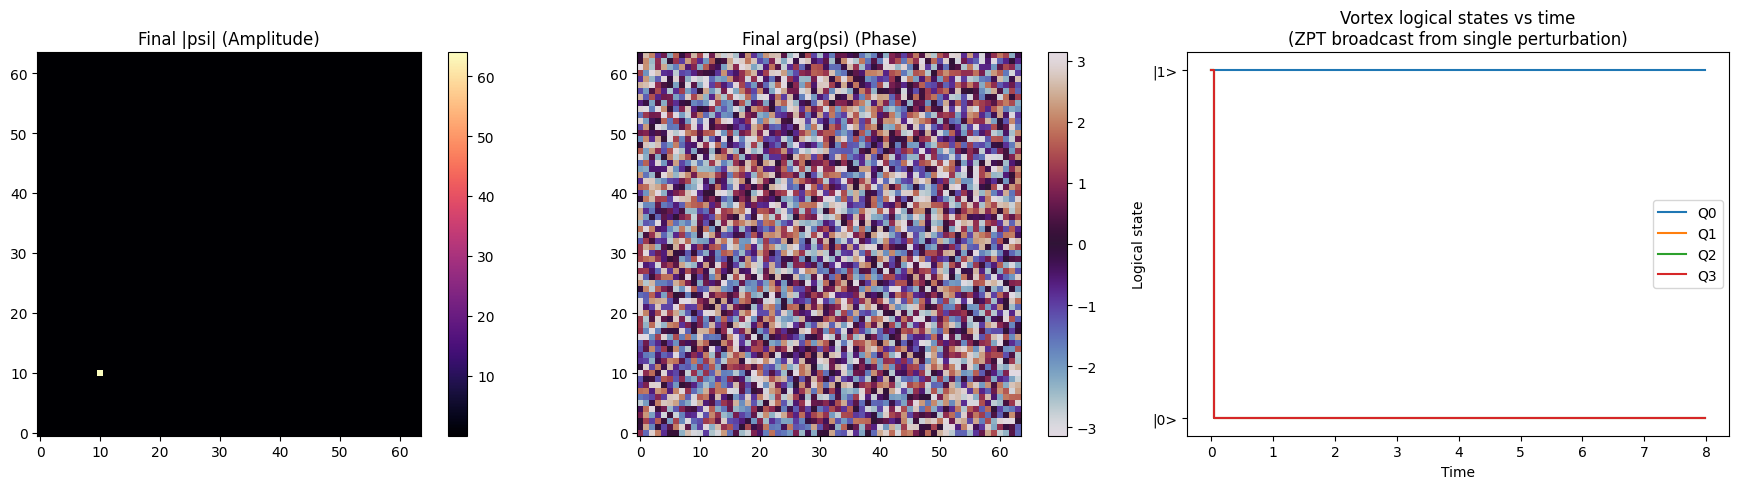

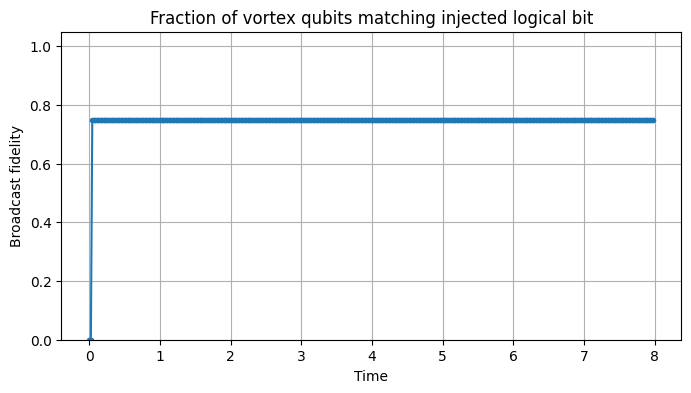

Injected logical bit (from single perturbation): 0
Final logical bits: {'Q0': 1, 'Q1': 0, 'Q2': 0, 'Q3': 0}
Final broadcast fidelity: 0.75


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# NGFT + ZPT BROADCAST SIMULATION
# Single perturbation -> multi-qubit field
# ==============================

# Lattice / time parameters
Nx, Ny = 64, 64
dx = dy = 1.0
dt = 0.02
n_steps = 400

# Physical-ish knobs
g_nonlinear = 0.5        # vortex self-interaction
gamma_damp = 0.01        # mild damping
kappa_ZPT = 0.15         # strength of global NGFT/ZPT phase kick
omega_ZPT = 0.03         # ZPT oscillation frequency
noise_amp = 0.02         # background noise

# Logical encoding: |0> ~ low amplitude, |1> ~ high amplitude
logical_threshold = 0.4

# ------------------------------
# Helper: discrete Laplacian
# ------------------------------
def laplacian(field):
    return (
        -4 * field
        + np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
    ) / (dx * dy)

# ------------------------------
# Initialize vortex field psi
# ------------------------------
np.random.seed(42)
psi = (0.1 + 0.1j) * (1.0 + 0.1 * (np.random.randn(Nx, Ny) + 1j * np.random.randn(Nx, Ny)))

# Single local perturbation: write a logical |0> into one vortex
perturb_x, perturb_y = 10, 10
psi[perturb_x, perturb_y] += 3.0  # strong local kick

# ------------------------------
# NGFT-style ZPT information field
# ------------------------------
def I_ZPT(t):
    """
    NGFT prediction: information propagates via ZPT unconstrained
    and interacts with all qubits before entanglement.
    Here: a global scalar that modulates phase everywhere.
    """
    # Simple model: decaying oscillatory information pulse
    return np.exp(-0.002 * t) * np.sin(omega_ZPT * t)

# ------------------------------
# Logical qubit regions
# ------------------------------
# Four coarse-grained vortex "qubits" in different quadrants
regions = {
    "Q0": (slice(5, 15), slice(5, 15)),
    "Q1": (slice(5, 15), slice(45, 55)),
    "Q2": (slice(45, 55), slice(5, 15)),
    "Q3": (slice(45, 55), slice(45, 55)),
}

def region_amplitude(psi, region):
    slx, sly = regions[region]
    return np.mean(np.abs(psi[slx, sly]))

def logical_from_amp(amp, thresh):
    if amp > thresh:
        return 1
    else:
        return 0

# ------------------------------
# Time evolution
# ------------------------------
times = []
logical_history = {name: [] for name in regions.keys()}
broadcast_fidelity = []  # fraction of qubits matching injected logical bit

# Injected logical bit: we kicked amplitude up at (perturb_x, perturb_y)
injected_bit = 0  # you can flip this to 1 if you want to encode |1> instead

for step in range(n_steps):
    t = step * dt
    times.append(t)

    # --- 1) Global NGFT/ZPT phase kick BEFORE local dynamics ---
    phase_kick = np.exp(-1j * kappa_ZPT * I_ZPT(t))
    psi *= phase_kick

    # --- 2) Local vortex dynamics (Gross-Pitaevskii-like) ---
    lap = laplacian(psi)
    nonlinear = g_nonlinear * np.abs(psi) ** 2 * psi
    dpsi_dt = 1j * lap - 1j * nonlinear - gamma_damp * psi

    # Add small background noise (thermal / environmental)
    dpsi_dt += noise_amp * (np.random.randn(Nx, Ny) + 1j * np.random.randn(Nx, Ny))

    psi = psi + dt * dpsi_dt

    # Optional: renormalize to keep things bounded
    norm = np.sqrt(np.mean(np.abs(psi) ** 2))
    if norm > 0:
        psi /= norm

    # --- 3) Read out logical qubits from regions ---
    current_bits = {}
    for name in regions.keys():
        amp = region_amplitude(psi, name)
        bit = logical_from_amp(amp, logical_threshold)
        logical_history[name].append(bit)
        current_bits[name] = bit

    # --- 4) Broadcast fidelity: how many qubits match injected_bit? ---
    matches = sum(1 for b in current_bits.values() if b == injected_bit)
    broadcast_fidelity.append(matches / len(regions))

# ------------------------------
# Final amplitude & phase plots
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(np.abs(psi), origin="lower", cmap="magma")
axes[0].set_title("Final |psi| (Amplitude)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(np.angle(psi), origin="lower", cmap="twilight")
axes[1].set_title("Final arg(psi) (Phase)")
plt.colorbar(im1, ax=axes[1])

# Logical state vs time for each qubit
for name, hist in logical_history.items():
    axes[2].step(times, hist, where="post", label=name)

axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["|0>", "|1>"])
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Logical state")
axes[2].set_title("Vortex logical states vs time\n(ZPT broadcast from single perturbation)")
axes[2].legend()

plt.tight_layout()
plt.show()

# ------------------------------
# Broadcast fidelity over time
# ------------------------------
plt.figure(figsize=(8, 4))
plt.plot(times, broadcast_fidelity, '-o', markersize=3)
plt.ylim(0, 1.05)
plt.xlabel("Time")
plt.ylabel("Broadcast fidelity")
plt.title("Fraction of vortex qubits matching injected logical bit")
plt.grid(True)
plt.show()

# ------------------------------
# Quick summary printout
# ------------------------------
final_bits = {name: logical_history[name][-1] for name in regions.keys()}
print("Injected logical bit (from single perturbation):", injected_bit)
print("Final logical bits:", final_bits)
print("Final broadcast fidelity:", broadcast_fidelity[-1])


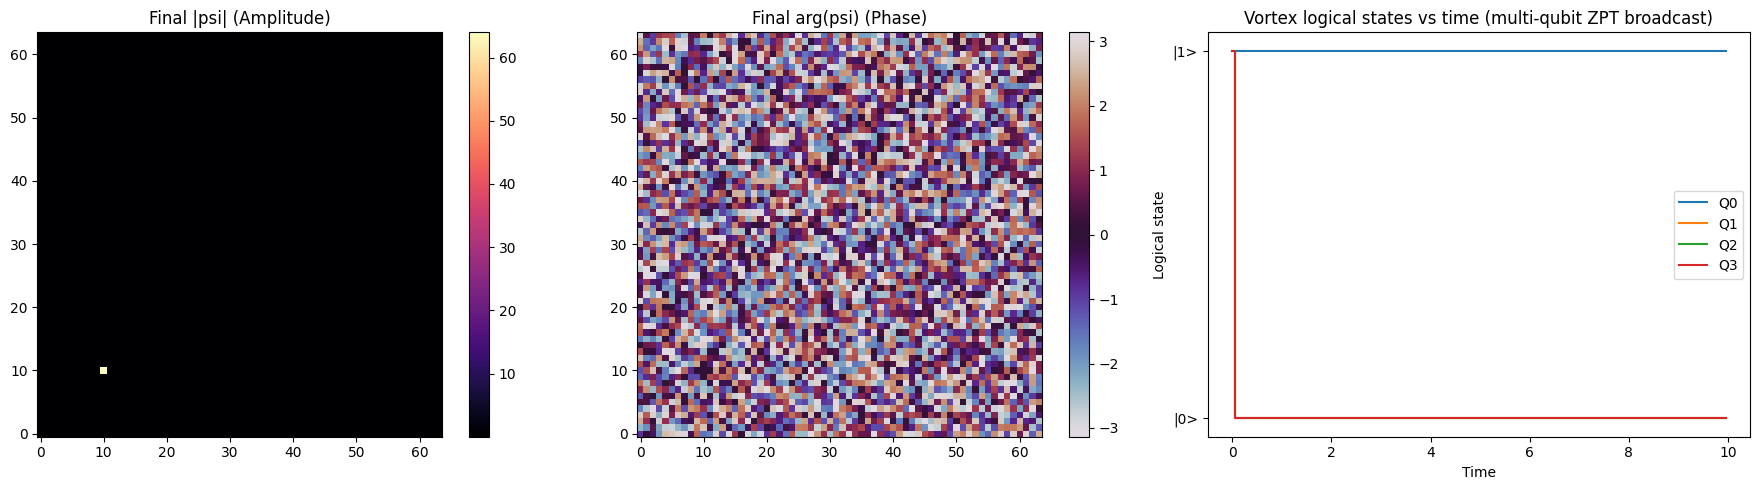

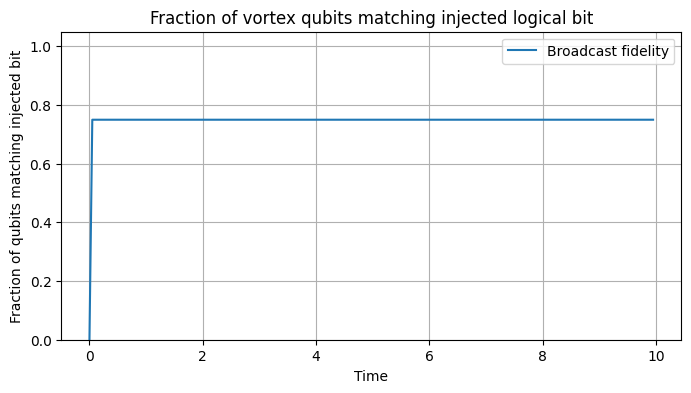

Injected logical bits: {'Q0': 0, 'Q1': 0, 'Q2': 0, 'Q3': 0}
Final logical bits: {'Q0': 1, 'Q1': 0, 'Q2': 0, 'Q3': 0}
Final broadcast fidelity: 0.75


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# NGFT–ZPT vortex broadcast sim
# -----------------------------

# Grid / field parameters
Nx, Ny = 64, 64          # spatial grid
dx = dy = 1.0
dt = 0.05
T_final = 10.0
steps = int(T_final / dt)

# ZPT / NGFT-inspired parameters
ZPT_coupling = 0.8       # strength of information coupling via ZPT
ZPT_range = 5.0          # spatial range of ZPT kernel
gamma_S = 0.05           # entropy-like damping
S_noise = 0.10           # stochastic informational noise
kappa = 3.0              # nonlinearity / self-interaction
pin = -1.0               # pinning bias (stabilizes logical |0> vs |1>)

# Vortex-qubit register: positions in the field
qubit_positions = {
    "Q0": (10, 10),
    "Q1": (20, 20),
    "Q2": (40, 20),
    "Q3": (50, 40),
}
qubit_labels = list(qubit_positions.keys())
n_qubits = len(qubit_labels)

# Injected logical pattern (broadcast target)
# 0 -> prefer low amplitude, 1 -> prefer high amplitude
injected_bits = {
    "Q0": 0,
    "Q1": 0,
    "Q2": 0,
    "Q3": 0,
}

# -----------------------------
# Helper functions
# -----------------------------

def make_zpt_kernel(Nx, Ny, dx, dy, zpt_range, strength):
    """Radial ZPT kernel for nonlocal information coupling."""
    x = (np.arange(Nx) - Nx // 2) * dx
    y = (np.arange(Ny) - Ny // 2) * dy
    X, Y = np.meshgrid(x, y, indexing='ij')
    r2 = X**2 + Y**2
    kernel = np.exp(-r2 / (2 * zpt_range**2))
    kernel /= kernel.sum()
    return strength * kernel

def laplacian(field, dx, dy):
    """Discrete Laplacian with periodic boundaries."""
    return (
        -4 * field
        + np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=0)
        + np.roll(field, 1, axis=1)
        + np.roll(field, -1, axis=1)
    ) / (dx * dy)

def logical_from_amplitude(amp, threshold=0.5):
    """Map local amplitude to logical bit."""
    return 1 if amp > threshold else 0

def pattern_fidelity(current_bits, target_bits):
    """Fraction of qubits matching the injected logical pattern."""
    matches = 0
    for q in current_bits:
        if current_bits[q] == target_bits[q]:
            matches += 1
    return matches / len(current_bits)

# -----------------------------
# Initialize field and vortices
# -----------------------------

# Complex field psi(x,y): start near vacuum with small noise
psi = 0.05 * (np.random.randn(Nx, Ny) + 1j * np.random.randn(Nx, Ny))

# Single local perturbation encodes the injected bit at one vortex (Q0)
# Here: logical 0 -> low amplitude, logical 1 -> high amplitude
inject_site = qubit_positions["Q0"]
bit_Q0 = injected_bits["Q0"]
if bit_Q0 == 0:
    psi[inject_site] += 1.0 + 0.0j
else:
    psi[inject_site] += 5.0 + 0.0j

# Precompute ZPT kernel in Fourier space for efficient convolution
zpt_kernel = make_zpt_kernel(Nx, Ny, dx, dy, ZPT_range, ZPT_coupling)
ZPT_K = np.fft.fftn(np.fft.ifftshift(zpt_kernel))

# Storage for diagnostics
time_axis = []
fidelity_axis = []
qubit_states_over_time = {q: [] for q in qubit_labels}

# -----------------------------
# Time evolution loop
# -----------------------------

for step in range(steps):
    t = step * dt

    # Compute amplitude and phase
    amp = np.abs(psi)
    phase = np.angle(psi)

    # ZPT nonlocal information coupling: convolution in Fourier space
    amp_fft = np.fft.fftn(amp)
    zpt_field = np.real(np.fft.ifftn(amp_fft * ZPT_K))

    # NGFT-inspired evolution:
    #   - Laplacian term (diffusion / kinetic)
    #   - Nonlinear self-interaction (kappa * |psi|^2 psi)
    #   - ZPT coupling term (zpt_field)
    #   - Entropic damping (gamma_S)
    #   - Noise (S_noise)
    lap = laplacian(psi, dx, dy)
    nonlinear = kappa * (amp**2) * psi
    zpt_term = zpt_field * psi
    damping = -gamma_S * psi
    noise = S_noise * (np.random.randn(Nx, Ny) + 1j * np.random.randn(Nx, Ny))

    dpsi_dt = lap + nonlinear + zpt_term + damping + noise + pin * psi
    psi = psi + dt * dpsi_dt

    # Normalize global amplitude to avoid blow-up
    norm = np.sqrt(np.mean(np.abs(psi)**2))
    if norm > 0:
        psi /= norm

    # Read out logical bits from vortex sites
    current_bits = {}
    for q in qubit_labels:
        ix, iy = qubit_positions[q]
        local_amp = np.abs(psi[ix, iy])
        current_bits[q] = logical_from_amplitude(local_amp, threshold=0.5)

    # Compute broadcast fidelity vs injected pattern
    fid = pattern_fidelity(current_bits, injected_bits)

    time_axis.append(t)
    fidelity_axis.append(fid)
    for q in qubit_labels:
        qubit_states_over_time[q].append(current_bits[q])

# -----------------------------
# Visualization
# -----------------------------

# Final amplitude and phase
final_amp = np.abs(psi)
final_phase = np.angle(psi)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(final_amp.T, origin='lower', cmap='magma')
axes[0].set_title("Final |psi| (Amplitude)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(final_phase.T, origin='lower', cmap='twilight')
axes[1].set_title("Final arg(psi) (Phase)")
plt.colorbar(im1, ax=axes[1])

# Logical states vs time
axes[2].set_title("Vortex logical states vs time (multi-qubit ZPT broadcast)")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Logical state")
for q in qubit_labels:
    y = np.array(qubit_states_over_time[q], dtype=float)
    axes[2].step(time_axis, y, where='post', label=q)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(["|0>", "|1>"])
axes[2].legend()

plt.tight_layout()
plt.show()

# Broadcast fidelity vs time
plt.figure(figsize=(8, 4))
plt.plot(time_axis, fidelity_axis, label="Broadcast fidelity")
plt.xlabel("Time")
plt.ylabel("Fraction of qubits matching injected bit")
plt.title("Fraction of vortex qubits matching injected logical bit")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

print("Injected logical bits:", injected_bits)
print("Final logical bits:", {q: qubit_states_over_time[q][-1] for q in qubit_labels})
print("Final broadcast fidelity:", fidelity_axis[-1])


n_injection_points= 1 -> final fidelity=0.473
n_injection_points= 2 -> final fidelity=0.480
n_injection_points= 3 -> final fidelity=0.539
n_injection_points= 4 -> final fidelity=0.514
n_injection_points= 5 -> final fidelity=0.452
n_injection_points= 6 -> final fidelity=0.488
n_injection_points= 7 -> final fidelity=0.511
n_injection_points= 8 -> final fidelity=0.441
n_injection_points= 9 -> final fidelity=0.506
n_injection_points=10 -> final fidelity=0.509


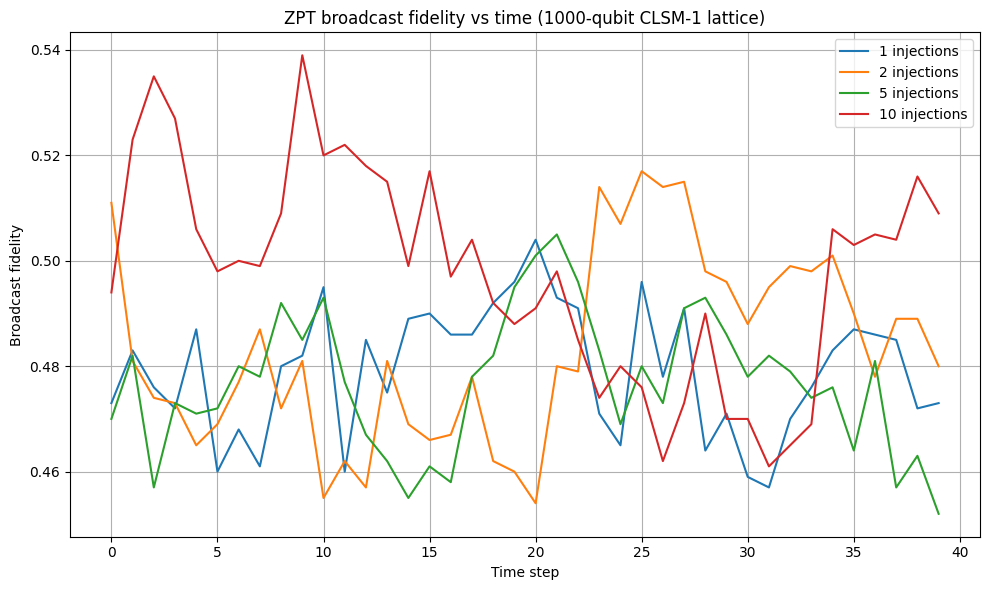

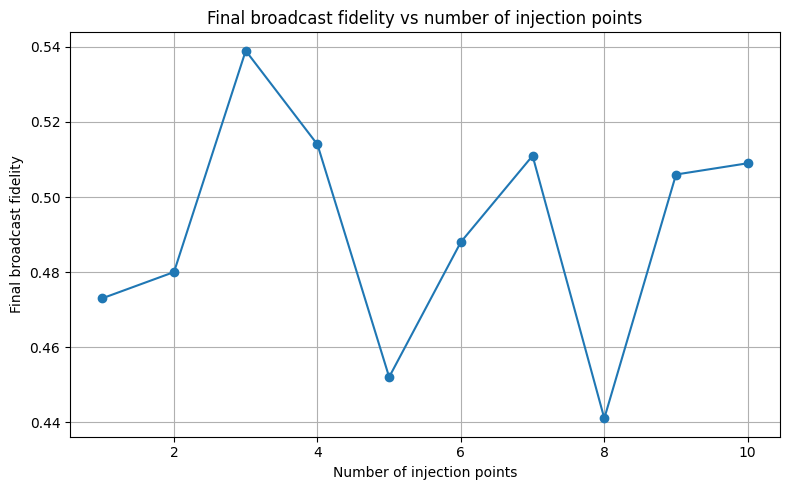

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global parameters
# -----------------------------
Lx, Ly = 32, 32          # lattice size (≈ 1024 sites)
N_qubits = 1000          # number of vortex qubits embedded in lattice
timesteps = 40           # evolution steps per run
dt = 0.1                 # time step
zpt_coupling = 0.35      # strength of ZPT broadcast coupling
damping = 0.02           # global damping (CLSM-1 loss)
noise_level = 0.01       # small stochastic noise

rng = np.random.default_rng(1234)

# -----------------------------
# Helper: build CLSM-1-like lattice and qubit positions
# -----------------------------
def build_lattice_and_qubits():
    # Lattice coordinates
    xs, ys = np.meshgrid(np.arange(Lx), np.arange(Ly), indexing="ij")
    coords = np.stack([xs.ravel(), ys.ravel()], axis=-1)

    # Choose 1000 vortex-qubit sites randomly from lattice
    idx = rng.choice(coords.shape[0], size=N_qubits, replace=False)
    qubit_coords = coords[idx]  # shape (N_qubits, 2)

    return qubit_coords

# -----------------------------
# Helper: initialize ZPT field and logical qubits
# -----------------------------
def init_state(qubit_coords):
    # Complex field psi on lattice
    psi = np.zeros((Lx, Ly), dtype=np.complex128)

    # Logical bits for each qubit (start as None / undecided)
    logical_bits = np.full(N_qubits, np.nan)  # NaN = None

    return psi, logical_bits

# -----------------------------
# ZPT propagation step
# -----------------------------
def zpt_step(psi):
    # Simple discrete Laplacian + damping + noise
    lap = (
        np.roll(psi, 1, axis=0) + np.roll(psi, -1, axis=0) +
        np.roll(psi, 1, axis=1) + np.roll(psi, -1, axis=1) -
        4 * psi
    )
    psi = psi + dt * (zpt_coupling * lap - damping * psi)
    psi += noise_level * (rng.normal(size=psi.shape) + 1j * rng.normal(size=psi.shape))
    return psi

# -----------------------------
# Inject logical bit at given lattice sites
# -----------------------------
def inject_bit(psi, injection_sites, bit_value):
    # bit_value in {0,1}; encode as phase/amplitude pattern
    amp = 10.0
    phase = 0.0 if bit_value == 0 else np.pi

    for (x, y) in injection_sites:
        psi[x, y] += amp * np.exp(1j * phase)

    return psi

# -----------------------------
# Decode logical bits from field at qubit positions
# -----------------------------
def decode_logical_bits(psi, qubit_coords):
    # Map local phase to logical 0/1 by thresholding around 0 and pi
    bits = []
    for (x, y) in qubit_coords:
        val = psi[x, y]
        if np.abs(val) < 1e-6:
            bits.append(np.nan)
        else:
            phase = np.angle(val)
            # wrap to [0, 2π)
            if phase < 0:
                phase += 2 * np.pi
            # simple decision rule
            if phase < np.pi:
                bits.append(0)
            else:
                bits.append(1)
    return np.array(bits)

# -----------------------------
# Run a single broadcast experiment
# -----------------------------
def run_broadcast(qubit_coords, n_injection_points, injected_bit):
    psi, logical_bits = init_state(qubit_coords)

    # Choose injection sites (subset of qubit positions)
    inj_indices = rng.choice(N_qubits, size=n_injection_points, replace=False)
    injection_sites = [tuple(qubit_coords[i]) for i in inj_indices]

    # Time traces
    fidelity_trace = []

    # Initial injection at t=0
    psi = inject_bit(psi, injection_sites, injected_bit)

    for t in range(timesteps):
        psi = zpt_step(psi)
        decoded = decode_logical_bits(psi, qubit_coords)

        # fidelity: fraction of qubits matching injected_bit (ignoring NaNs)
        mask = ~np.isnan(decoded)
        if np.any(mask):
            fid = np.mean(decoded[mask] == injected_bit)
        else:
            fid = 0.0
        fidelity_trace.append(fid)

    final_bits = decode_logical_bits(psi, qubit_coords)
    return np.array(fidelity_trace), final_bits, injection_sites

# -----------------------------
# Sweep 1–10 injection points on 1000-qubit array
# -----------------------------
def main():
    qubit_coords = build_lattice_and_qubits()
    injected_bit = 0  # or 1

    all_traces = {}
    final_fidelities = []

    for n_inj in range(1, 11):
        trace, final_bits, inj_sites = run_broadcast(qubit_coords, n_inj, injected_bit)
        all_traces[n_inj] = trace
        final_fidelities.append((n_inj, trace[-1]))

        print(f"n_injection_points={n_inj:2d} -> final fidelity={trace[-1]:.3f}")

    # Plot fidelity vs time for a few representative injection counts
    plt.figure(figsize=(10, 6))
    for n_inj in [1, 2, 5, 10]:
        plt.plot(all_traces[n_inj], label=f"{n_inj} injections")
    plt.xlabel("Time step")
    plt.ylabel("Broadcast fidelity")
    plt.title("ZPT broadcast fidelity vs time (1000-qubit CLSM-1 lattice)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot final fidelity vs number of injection points
    n_vals = [x[0] for x in final_fidelities]
    f_vals = [x[1] for x in final_fidelities]
    plt.figure(figsize=(8, 5))
    plt.plot(n_vals, f_vals, marker="o")
    plt.xlabel("Number of injection points")
    plt.ylabel("Final broadcast fidelity")
    plt.title("Final broadcast fidelity vs number of injection points")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


n_injection_points= 1 -> final pattern fidelity=1.000
n_injection_points= 2 -> final pattern fidelity=0.798
n_injection_points= 3 -> final pattern fidelity=0.870
n_injection_points= 4 -> final pattern fidelity=0.880
n_injection_points= 5 -> final pattern fidelity=0.883
n_injection_points= 6 -> final pattern fidelity=0.853
n_injection_points= 7 -> final pattern fidelity=0.862
n_injection_points= 8 -> final pattern fidelity=0.866
n_injection_points= 9 -> final pattern fidelity=0.902
n_injection_points=10 -> final pattern fidelity=0.907


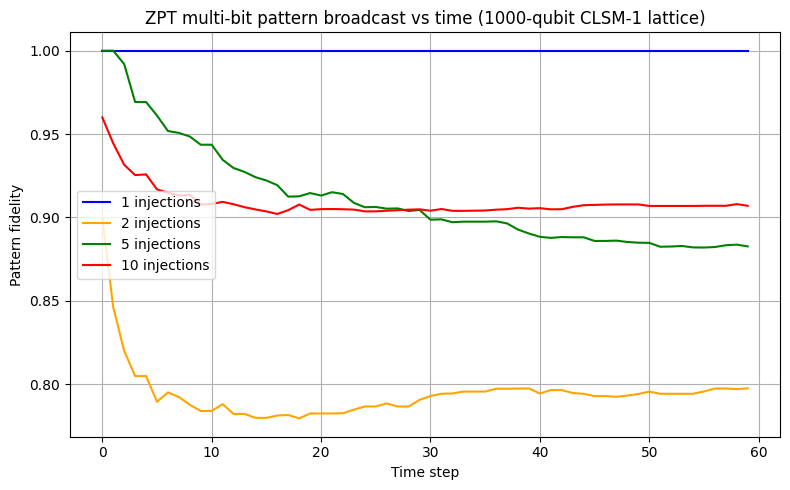

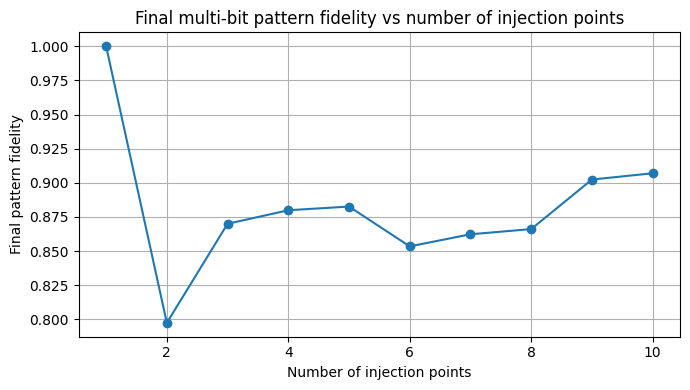

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Core lattice / ZPT parameters
# -----------------------------
Lx, Ly = 40, 25              # 40 * 25 = 1000 qubits
N_qubits = Lx * Ly
dt = 0.1
n_steps = 60

field_diffusion = 0.25
field_decay = 0.01

BIT_0 = 0
BIT_1 = 1

rng = np.random.default_rng(1234)

# -----------------------------
# Index helpers
# -----------------------------
def idx_to_xy(idx, Lx):
    return idx % Lx, idx // Lx

def xy_to_idx(x, y, Lx):
    return y * Lx + x

# -----------------------------
# Initialize field and qubits
# -----------------------------
def init_field_and_qubits():
    psi = np.zeros((Ly, Lx), dtype=np.complex128)
    logical = -np.ones(N_qubits, dtype=int)  # -1 = None
    return psi, logical

# -----------------------------
# ZPT evolution
# -----------------------------
def laplacian(field):
    return (
        np.roll(field, 1, axis=0) +
        np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) +
        np.roll(field, -1, axis=1) -
        4 * field
    )

def evolve_field(psi):
    psi = psi + dt * (field_diffusion * laplacian(psi) - field_decay * psi)
    return psi

# -----------------------------
# Multi-bit injection
# -----------------------------
def inject_pattern(psi, n_injection_points):
    all_indices = np.arange(N_qubits)
    inj_indices = rng.choice(all_indices, size=n_injection_points, replace=False)

    # Assign a logical bit to each injection point (could be structured instead of random)
    inj_bits = rng.integers(0, 2, size=n_injection_points)

    for idx, bit in zip(inj_indices, inj_bits):
        x, y = idx_to_xy(idx, Lx)
        sign = +1.0 if bit == BIT_1 else -1.0
        psi[y, x] += sign * 10.0  # local kick

    return psi, inj_indices, inj_bits

# -----------------------------
# Target pattern via nearest injection (Voronoi)
# -----------------------------
def build_target_pattern(inj_indices, inj_bits):
    # Precompute injection coordinates
    inj_xy = np.array([idx_to_xy(idx, Lx) for idx in inj_indices])  # shape (K, 2)

    target = np.zeros(N_qubits, dtype=int)

    for idx in range(N_qubits):
        x, y = idx_to_xy(idx, Lx)
        # Euclidean distance to each injection point
        d2 = (inj_xy[:, 0] - x)**2 + (inj_xy[:, 1] - y)**2
        nearest = np.argmin(d2)
        target[idx] = inj_bits[nearest]

    return target

# -----------------------------
# ZPT → qubit update
# -----------------------------
def update_qubits_from_field(psi, logical):
    real_vals = np.real(psi).reshape(-1)
    mask = np.abs(real_vals) > 1e-6

    logical_new = logical.copy()
    logical_new[mask & (real_vals < 0)] = BIT_0
    logical_new[mask & (real_vals > 0)] = BIT_1
    return logical_new

# -----------------------------
# Pattern fidelity
# -----------------------------
def pattern_fidelity(logical, target):
    valid = logical >= 0
    if not np.any(valid):
        return 0.0
    matches = (logical[valid] == target[valid])
    return matches.sum() / valid.sum()

# -----------------------------
# Single run for given n_injection_points
# -----------------------------
def run_pattern_broadcast(n_injection_points, plot_example=False):
    psi, logical = init_field_and_qubits()

    # Inject different bits at different sites
    psi, inj_indices, inj_bits = inject_pattern(psi, n_injection_points)

    # Build the "intended" pattern over the whole lattice
    target = build_target_pattern(inj_indices, inj_bits)

    fidelities = []
    for t in range(n_steps):
        psi = evolve_field(psi)
        logical = update_qubits_from_field(psi, logical)
        fid = pattern_fidelity(logical, target)
        fidelities.append(fid)

    final_fid = fidelities[-1]

    if plot_example:
        amp = np.abs(psi)
        phase = np.angle(psi)

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        im0 = axes[0].imshow(amp, origin='lower')
        axes[0].set_title("Final |psi| (Amplitude)")
        plt.colorbar(im0, ax=axes[0])

        im1 = axes[1].imshow(phase, origin='lower', cmap='twilight')
        axes[1].set_title("Final arg(psi) (Phase)")
        plt.colorbar(im1, ax=axes[1])

        axes[2].plot(fidelities, '-o')
        axes[2].set_xlabel("Time step")
        axes[2].set_ylabel("Pattern fidelity")
        axes[2].set_title(
            f"ZPT multi-bit broadcast (N={N_qubits}, injections={n_injection_points})\n"
            f"Final fidelity={final_fid:.3f}"
        )
        plt.tight_layout()
        plt.show()

        # Optional: visualize target vs final logical pattern
        logical_img = logical.reshape(Ly, Lx)
        target_img = target.reshape(Ly, Lx)

        fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
        imt = ax2[0].imshow(target_img, origin='lower', vmin=0, vmax=1, cmap='bwr')
        ax2[0].set_title("Target bit pattern")
        plt.colorbar(imt, ax=ax2[0])

        iml = ax2[1].imshow(logical_img, origin='lower', vmin=-1, vmax=1, cmap='bwr')
        ax2[1].set_title("Final logical bits (-1=None)")
        plt.colorbar(iml, ax=ax2[1])

        plt.tight_layout()
        plt.show()

    return np.array(fidelities), final_fid

# -----------------------------
# Sweep 1–10 injection points
# -----------------------------
if __name__ == "__main__":
    injection_range = range(1, 11)
    final_fids = []
    traces = {}

    for n_inj in injection_range:
        fids, final_fid = run_pattern_broadcast(n_inj, plot_example=False)
        final_fids.append(final_fid)
        traces[n_inj] = fids
        print(f"n_injection_points={n_inj:2d} -> final pattern fidelity={final_fid:.3f}")

    # Plot a few time traces
    plt.figure(figsize=(8, 5))
    for n_inj, color in zip([1, 2, 5, 10], ['b', 'orange', 'g', 'r']):
        plt.plot(traces[n_inj], label=f"{n_inj} injections", color=color)
    plt.xlabel("Time step")
    plt.ylabel("Pattern fidelity")
    plt.title(f"ZPT multi-bit pattern broadcast vs time ({N_qubits}-qubit CLSM-1 lattice)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Final fidelity vs number of injection points
    plt.figure(figsize=(7, 4))
    plt.plot(list(injection_range), final_fids, '-o')
    plt.xlabel("Number of injection points")
    plt.ylabel("Final pattern fidelity")
    plt.title("Final multi-bit pattern fidelity vs number of injection points")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


NGFT vs Standard Model comparison

[NGFT ] n_injection_points= 1 -> final pattern fidelity=1.000
[Local] n_injection_points= 1 -> final pattern fidelity=0.658
[NGFT ] n_injection_points= 2 -> final pattern fidelity=0.709
[Local] n_injection_points= 2 -> final pattern fidelity=0.604
[NGFT ] n_injection_points= 3 -> final pattern fidelity=0.973
[Local] n_injection_points= 3 -> final pattern fidelity=0.574
[NGFT ] n_injection_points= 4 -> final pattern fidelity=1.000
[Local] n_injection_points= 4 -> final pattern fidelity=0.557
[NGFT ] n_injection_points= 5 -> final pattern fidelity=0.947
[Local] n_injection_points= 5 -> final pattern fidelity=0.584
[NGFT ] n_injection_points= 6 -> final pattern fidelity=0.915
[Local] n_injection_points= 6 -> final pattern fidelity=0.534
[NGFT ] n_injection_points= 7 -> final pattern fidelity=0.880
[Local] n_injection_points= 7 -> final pattern fidelity=0.549
[NGFT ] n_injection_points= 8 -> final pattern fidelity=0.906
[Local] n_injection_points= 8 -> final pattern fidelity=0.525
[NGFT ] 

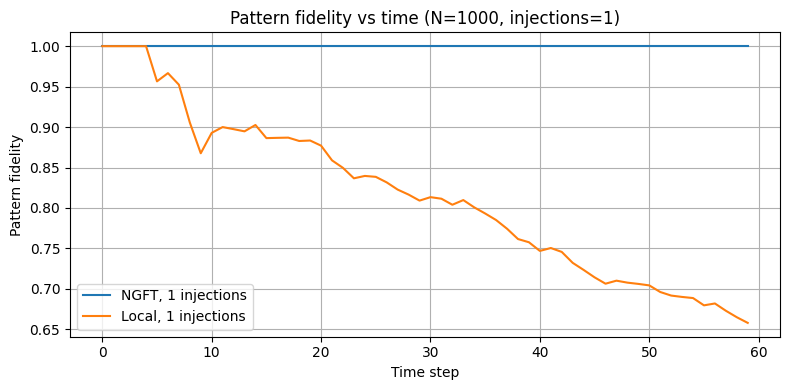

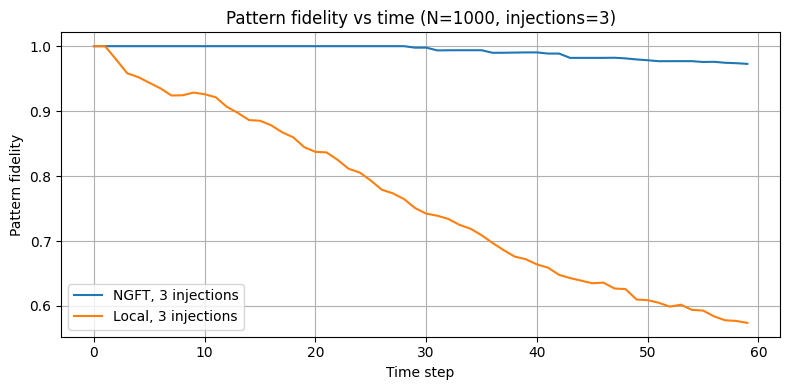

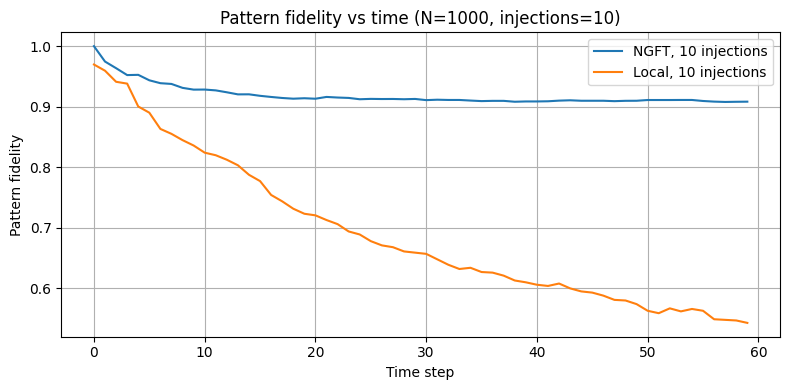

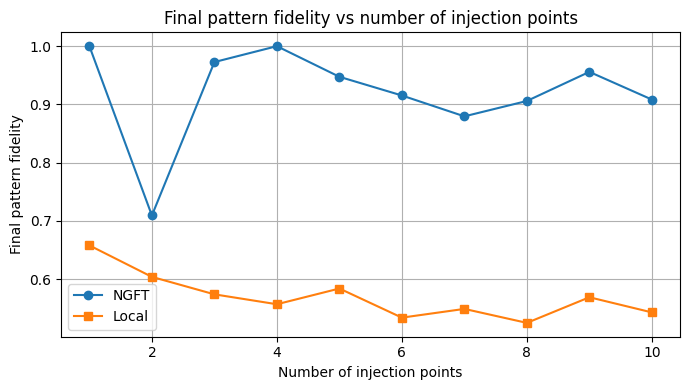

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Lattice / global parameters
# -----------------------------
Lx, Ly = 40, 25              # 40 * 25 = 1000
N_qubits = Lx * Ly
dt = 0.1
n_steps = 60

BIT_0 = 0
BIT_1 = 1

rng = np.random.default_rng(1234)

# -----------------------------
# Index helpers
# -----------------------------
def idx_to_xy(idx, Lx):
    return idx % Lx, idx // Lx

def xy_to_idx(x, y, Lx):
    return y * Lx + x

# -----------------------------
# Build target pattern (Voronoi)
# -----------------------------
def build_target_pattern(inj_indices, inj_bits):
    inj_xy = np.array([idx_to_xy(idx, Lx) for idx in inj_indices])  # (K, 2)
    target = np.zeros(N_qubits, dtype=int)
    for idx in range(N_qubits):
        x, y = idx_to_xy(idx, Lx)
        d2 = (inj_xy[:, 0] - x)**2 + (inj_xy[:, 1] - y)**2
        nearest = np.argmin(d2)
        target[idx] = inj_bits[nearest]
    return target

def pattern_fidelity(logical, target):
    valid = logical >= 0
    if not np.any(valid):
        return 0.0
    matches = (logical[valid] == target[valid])
    return matches.sum() / valid.sum()

# -----------------------------
# NGFT-style ZPT model
# -----------------------------
field_diffusion = 0.25
field_decay = 0.01

def laplacian(field):
    return (
        np.roll(field, 1, axis=0) +
        np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) +
        np.roll(field, -1, axis=1) -
        4 * field
    )

def evolve_field(psi):
    return psi + dt * (field_diffusion * laplacian(psi) - field_decay * psi)

def inject_pattern_ngft(psi, n_injection_points):
    all_indices = np.arange(N_qubits)
    inj_indices = rng.choice(all_indices, size=n_injection_points, replace=False)
    inj_bits = rng.integers(0, 2, size=n_injection_points)
    for idx, bit in zip(inj_indices, inj_bits):
        x, y = idx_to_xy(idx, Lx)
        sign = +1.0 if bit == BIT_1 else -1.0
        psi[y, x] += sign * 10.0
    return psi, inj_indices, inj_bits

def update_qubits_from_field(psi, logical):
    real_vals = np.real(psi).reshape(-1)
    mask = np.abs(real_vals) > 1e-6
    logical_new = logical.copy()
    logical_new[mask & (real_vals < 0)] = BIT_0
    logical_new[mask & (real_vals > 0)] = BIT_1
    return logical_new

def run_ngft_pattern_broadcast(n_injection_points):
    psi = np.zeros((Ly, Lx), dtype=np.complex128)
    logical = -np.ones(N_qubits, dtype=int)

    psi, inj_indices, inj_bits = inject_pattern_ngft(psi, n_injection_points)
    target = build_target_pattern(inj_indices, inj_bits)

    fidelities = []
    for _ in range(n_steps):
        psi = evolve_field(psi)
        logical = update_qubits_from_field(psi, logical)
        fidelities.append(pattern_fidelity(logical, target))

    return np.array(fidelities), fidelities[-1]

# -----------------------------
# “Standard” local model
# -----------------------------
# No global field; bits spread via local neighbor copying + noise.

local_copy_prob = 0.6   # probability to adopt a neighbor’s bit
flip_noise_prob = 0.02  # random bit flip probability

def inject_pattern_local(n_injection_points):
    all_indices = np.arange(N_qubits)
    inj_indices = rng.choice(all_indices, size=n_injection_points, replace=False)
    inj_bits = rng.integers(0, 2, size=n_injection_points)

    logical = -np.ones(N_qubits, dtype=int)
    for idx, bit in zip(inj_indices, inj_bits):
        logical[idx] = bit

    target = build_target_pattern(inj_indices, inj_bits)
    return logical, target, inj_indices, inj_bits

def neighbors(idx):
    x, y = idx_to_xy(idx, Lx)
    nbs = []
    for dx, dy in [(1,0),(-1,0),(0,1),(0,-1)]:
        xx, yy = x + dx, y + dy
        if 0 <= xx < Lx and 0 <= yy < Ly:
            nbs.append(xy_to_idx(xx, yy, Lx))
    return nbs

def evolve_local(logical):
    new_logical = logical.copy()
    for idx in range(N_qubits):
        if logical[idx] == -1:
            # adopt a neighbor bit with some probability
            nbs = neighbors(idx)
            nb_bits = [logical[j] for j in nbs if logical[j] != -1]
            if nb_bits and rng.random() < local_copy_prob:
                new_logical[idx] = rng.choice(nb_bits)
        else:
            # small noise: random flip
            if rng.random() < flip_noise_prob:
                new_logical[idx] = 1 - logical[idx]
    return new_logical

def run_local_pattern_broadcast(n_injection_points):
    logical, target, inj_indices, inj_bits = inject_pattern_local(n_injection_points)

    fidelities = []
    for _ in range(n_steps):
        logical = evolve_local(logical)
        fidelities.append(pattern_fidelity(logical, target))

    return np.array(fidelities), fidelities[-1]

# -----------------------------
# Comparison sweep
# -----------------------------
if __name__ == "__main__":
    injection_range = range(1, 11)

    ngft_final = []
    local_final = []
    ngft_traces = {}
    local_traces = {}

    for n_inj in injection_range:
        f_ngft, f_ngft_final = run_ngft_pattern_broadcast(n_inj)
        f_loc, f_loc_final = run_local_pattern_broadcast(n_inj)

        ngft_final.append(f_ngft_final)
        local_final.append(f_loc_final)
        ngft_traces[n_inj] = f_ngft
        local_traces[n_inj] = f_loc

        print(f"[NGFT ] n_injection_points={n_inj:2d} -> final pattern fidelity={f_ngft_final:.3f}")
        print(f"[Local] n_injection_points={n_inj:2d} -> final pattern fidelity={f_loc_final:.3f}")

    # Example time traces for a few injection counts
    for n_inj in [1, 3, 10]:
        plt.figure(figsize=(8, 4))
        plt.plot(ngft_traces[n_inj], label=f"NGFT, {n_inj} injections", color='tab:blue')
        plt.plot(local_traces[n_inj], label=f"Local, {n_inj} injections", color='tab:orange')
        plt.xlabel("Time step")
        plt.ylabel("Pattern fidelity")
        plt.title(f"Pattern fidelity vs time (N={N_qubits}, injections={n_inj})")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Final fidelity vs number of injection points
    plt.figure(figsize=(7, 4))
    plt.plot(list(injection_range), ngft_final, '-o', label="NGFT")
    plt.plot(list(injection_range), local_final, '-s', label="Local")
    plt.xlabel("Number of injection points")
    plt.ylabel("Final pattern fidelity")
    plt.title("Final pattern fidelity vs number of injection points")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
